# Aversive Anticipation 2023. Biopac Analysis.


In [1]:
import numpy as np
import pandas as pd
from pandas.core.frame import DataFrame as DF

import seaborn as sns
sns.set(color_codes=True)
#np.random.seed(sum(map(ord, "distributions")))
from sklearn import linear_model  # packages for the logistic regression function to plot the logistic regression 
from sklearn.linear_model import LogisticRegression # packages for the logistic regression function to plot the logistic regression 
import scipy
from scipy import stats, integrate
from scipy.stats import mode
from scipy.stats.stats import pearsonr # Pearson's correlation
from scipy.stats import sem
from copy import copy as copy
import operator as operator

import pylab

# Plotting tools
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%pylab inline
figsize(5, 5)

import glob

import os
# Added to avoid OMP:error#15
os.environ['KMP_DUPLICATE_LIB_OK']='True'

Populating the interactive namespace from numpy and matplotlib


/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_27625/606496916.py:13: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr # Pearson's correlation
/Users/stelladong/opt/anaconda3/lib/python3.9/site-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['copy', 'pylab']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [2]:
def getSubstringBetweenTwoChars(ch1,ch2,s):
    return s[s.find(ch1)+3:s.find(ch2)-3]

# Load dataframe

In [3]:
colnamesFull=['PART', 'EKG', 'EDA', 'CH28','CH29','CH30','CH31','CH32','CH33','CH34','CH35']
dataDF0 = pd.DataFrame(columns = colnamesFull)

In [4]:
file_asc = []
colnames=['EKG', 'EDA', 'CH28','CH29','CH30','CH31','CH32','CH33','CH34','CH35']

for name in glob.glob("DataBiopac/*.txt", recursive = True):
    dataDF_PART = pd.read_csv(name,sep='\t',names = colnames,header = 0,index_col =False)
    dataDF_PART['PART'] = [getSubstringBetweenTwoChars('AV_','.TXT',name)]*len(dataDF_PART)
    dataDF0 = dataDF0.append(dataDF_PART)
    print ('Complete ... ' + name)


/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_27625/310063321.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataDF0 = dataDF0.append(dataDF_PART)


Complete ... DataBiopac/AV_P006.txt


/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_27625/310063321.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataDF0 = dataDF0.append(dataDF_PART)


Complete ... DataBiopac/AV_P005.txt


/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_27625/310063321.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataDF0 = dataDF0.append(dataDF_PART)


Complete ... DataBiopac/AV_P003.txt


# Events add

In [5]:
dataDF0['startBlock'] = 1*((dataDF0['CH28'] == 5) & (dataDF0['CH29'] == 0)& (dataDF0['CH30'] == 0) & (dataDF0['CH31'] == 5) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 9
dataDF0['startTrial'] = 1*((dataDF0['CH28'] == 5) & (dataDF0['CH29'] == 0)& (dataDF0['CH30'] == 0) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 1 
dataDF0['infoChoice'] = 1*((dataDF0['CH28'] == 0) & (dataDF0['CH29'] == 5)& (dataDF0['CH30'] == 0) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 2
dataDF0['stimInfo']   = 1*((dataDF0['CH28'] == 5) & (dataDF0['CH29'] == 5)& (dataDF0['CH30'] == 0) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 3
dataDF0['stimNoInfo'] = 1*((dataDF0['CH28'] == 0) & (dataDF0['CH29'] == 0)& (dataDF0['CH30'] == 5) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 4
dataDF0['scream']     = 1*((dataDF0['CH28'] == 5) & (dataDF0['CH29'] == 0)& (dataDF0['CH30'] == 5) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 5
dataDF0['noScream']   = 1*((dataDF0['CH28'] == 0) & (dataDF0['CH29'] == 5)& (dataDF0['CH30'] == 5) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 6
dataDF0['endTrial']   = 1*((dataDF0['CH28'] == 5) & (dataDF0['CH29'] == 5)& (dataDF0['CH30'] == 5) & (dataDF0['CH31'] == 0) & (dataDF0['CH32'] == 0) & (dataDF0['CH33'] == 0) & (dataDF0['CH34'] == 0) & (dataDF0['CH35'] == 0)) # binary 6


In [10]:
#startTrial  for baseline we use 3 secs prior to the event and 2 seconds after 
#infoChoice begining of the choice period
#noInfo   beginning of the info period, immediately after choice
#yesInfo   beginning of the info period , immediately after choice
#noScream  no Scream delivery
#yesScrea  Scream delivery
#endTrial  end of the trial
#              1              2        3        4          5            6         7

#labels = ['startTrial','infoChoice','yesInfo','noInfo','yesScream','noScream','endTrial']

In [11]:
#choiceNameFrames1 = glob.glob('DataBiopac/AV_P016.txt')
#eventsFrame = glob.glob('PartData/Participant1_events.txt')

# remember sample rate is 2000 Hz

In [12]:
#colnames=['EKG', 'EDA', 'CH28','CH29','CH30','CH31','CH32','CH33','CH34','CH35']

#dataDF1 = pd.read_csv(choiceNameFrames1[0],sep='\t',names = colnames,header = 0,index_col =False)

In [13]:
#plt.plot(dataDF1['CH28'])
#plt.plot(dataDF1['CH29'])

# Select participants

In [6]:
dataDF0.PART.unique()

array(['P006', 'P005', 'P003'], dtype=object)

In [7]:
dataDF1 = dataDF0[dataDF0['PART'] != "P030_lastBlockOnly"].copy()

In [8]:
dataDF1 = dataDF1.reset_index(drop=True)

In [9]:
# delete innecessary dataframe

In [10]:
del dataDF0

# add time for each part

In [11]:
## channels represent digit positions for the event in binary  (starting with CH28 and ending with CH35)

In [12]:
timeNumer = []
for i in dataDF1.PART.unique():
    
    dataDFPart = dataDF1.loc[dataDF1.PART == i]

    l = list(range(len(dataDFPart)))
    print(len(l))
    print(l[0])

    timePart = [x/2000 for x in l]
    
    timeNumer.extend(timePart)


3842313
0
3843161
0
6096573
0


In [13]:
dataDF1["timePart"] =  timeNumer

l = list(range(len(dataDF1)))

timePart = [x/2000 for x in l]

dataDF1["time"] =  timePart

In [28]:
#dataDF1['startBlock'] = 1*((dataDF1['CH28'] == 5) & (dataDF1['CH29'] == 0)& (dataDF1['CH30'] == 0) & (dataDF1['CH31'] == 5) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 9
#dataDF1['startTrial'] = 1*((dataDF1['CH28'] == 5) & (dataDF1['CH29'] == 0)& (dataDF1['CH30'] == 0) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 1 
#dataDF1['infoChoice'] = 1*((dataDF1['CH28'] == 0) & (dataDF1['CH29'] == 5)& (dataDF1['CH30'] == 0) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 2
#dataDF1['stimInfo']   = 1*((dataDF1['CH28'] == 5) & (dataDF1['CH29'] == 5)& (dataDF1['CH30'] == 0) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 3
#dataDF1['stimNoInfo'] = 1*((dataDF1['CH28'] == 0) & (dataDF1['CH29'] == 0)& (dataDF1['CH30'] == 5) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 4
#dataDF1['scream']     = 1*((dataDF1['CH28'] == 5) & (dataDF1['CH29'] == 0)& (dataDF1['CH30'] == 5) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 5
#dataDF1['noScream']   = 1*((dataDF1['CH28'] == 0) & (dataDF1['CH29'] == 5)& (dataDF1['CH30'] == 5) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 6
#dataDF1['endTrial']   = 1*((dataDF1['CH28'] == 5) & (dataDF1['CH29'] == 5)& (dataDF1['CH30'] == 5) & (dataDF1['CH31'] == 0) & (dataDF1['CH32'] == 0) & (dataDF1['CH33'] == 0) & (dataDF1['CH34'] == 0) & (dataDF1['CH35'] == 0)) # binary 6
#

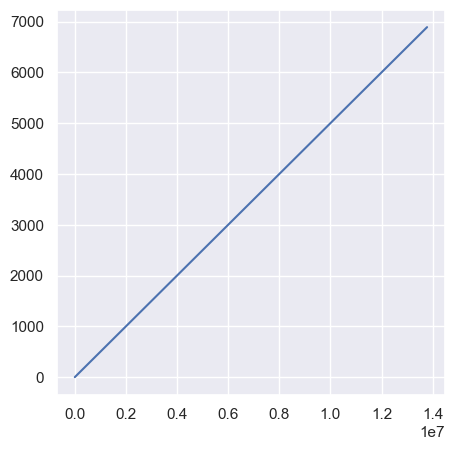

In [29]:
plt.plot(dataDF1["time"]) #check time is correct

In [30]:
dataDF1.loc[dataDF1['startBlock']==1]

,PART,EKG,EDA,CH28,CH29,CH30,CH31,CH32,CH33,CH34,...,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time
1731176,P006,0.223694,9.05914,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,865.5880,865.5880
1731177,P006,0.219879,9.05914,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,865.5885,865.5885
1731178,P006,0.215149,9.05762,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,865.5890,865.5890
1731179,P006,0.209808,9.06067,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,865.5895,865.5895
1731180,P006,0.203857,9.05762,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,865.5900,865.5900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13048055,P003,0.006409,11.92170,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,2681.2905,6524.0275
13048056,P003,0.003815,11.92170,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,2681.2910,6524.0280
13048057,P003,0.004272,11.92470,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,2681.2915,6524.0285
13048058,P003,0.007324,11.92320,5,0,0,5,0,0,0,...,1,0,0,0,0,0,0,0,2681.2920,6524.0290


# subsample the dataframe to 500hz (2000Hz/4)

In [31]:
dataDF1 = dataDF1.iloc[::4]
dataDF1 = dataDF1.reset_index(drop=True)
sampleRate = 500

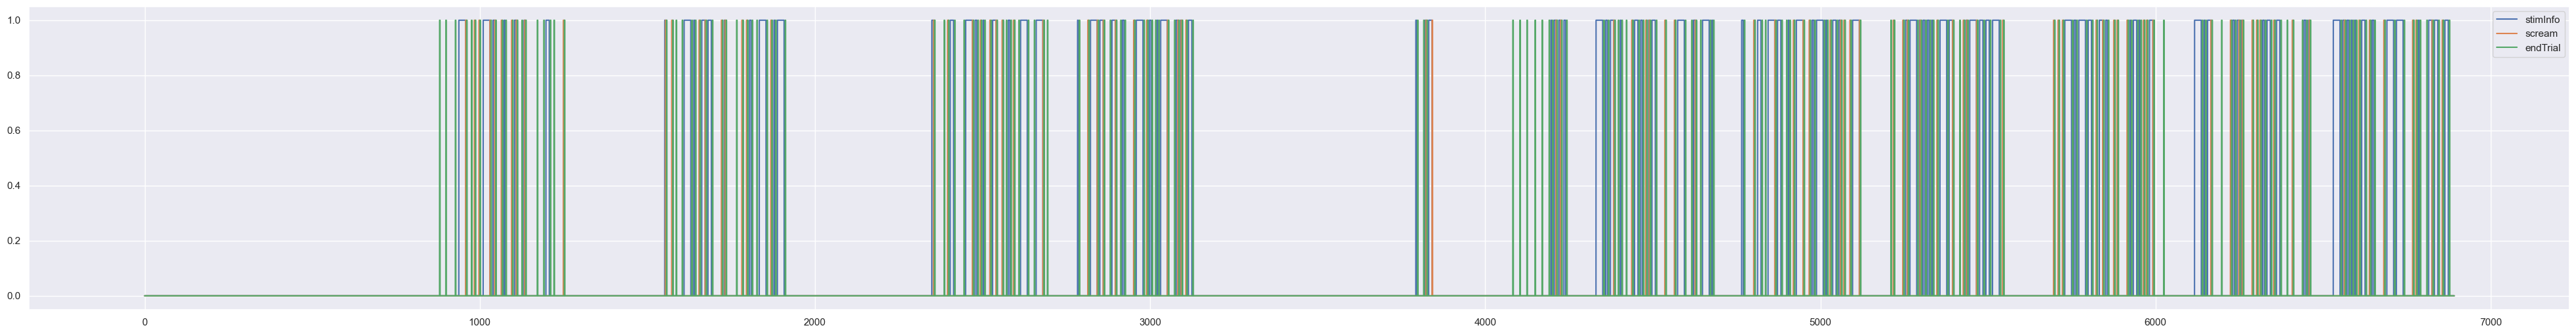

In [32]:
plt.figure(figsize=(50,6))

#plt.plot(dataDF1['time'],dataDF1['startBlock'], label = 'startBlock')
#plt.plot(dataDF1['time'],dataDF1['startTrial'], label = 'startTrial')
#plt.plot(dataDF1['time'],dataDF1['infoChoice'], label = 'infoChoice')
plt.plot(dataDF1['time'],dataDF1['stimInfo'], label = 'stimInfo')
#plt.plot(dataDF1['time'],dataDF1['stimNoInfo'], label = 'stimNoInfo')

plt.plot(dataDF1['time'],dataDF1['scream'], label = 'scream')
#plt.plot(dataDF1['time'],dataDF1['noScream'], label = 'noScream')
plt.plot(dataDF1['time'],dataDF1['endTrial'], label = 'endTrial')

plt.legend()

In [33]:
dataDF1_short = dataDF1.loc[(dataDF1['time']>1670)&(dataDF1['time']<1690) ]

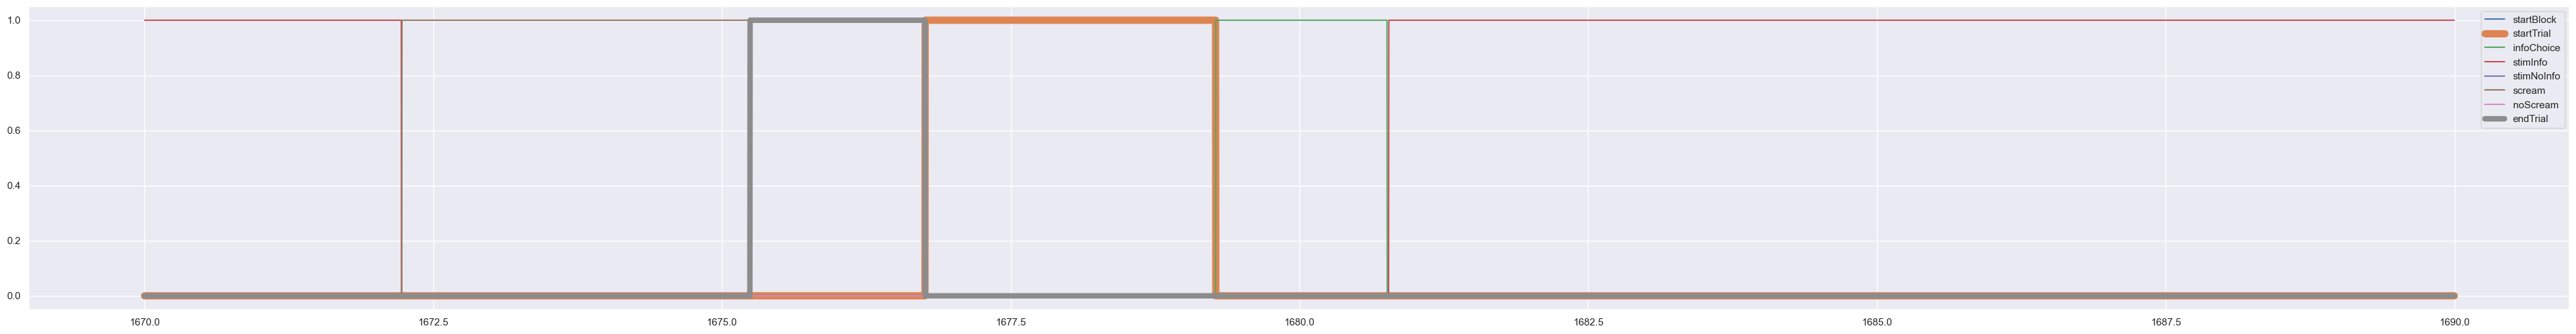

In [34]:
plt.figure(figsize=(50,6))

plt.plot(dataDF1_short['time'],dataDF1_short['startBlock'], label = 'startBlock' )
plt.plot(dataDF1_short['time'],dataDF1_short['startTrial'], label = 'startTrial',linewidth = 8)
plt.plot(dataDF1_short['time'],dataDF1_short['infoChoice'], label = 'infoChoice')
plt.plot(dataDF1_short['time'],dataDF1_short['stimInfo'], label = 'stimInfo')
plt.plot(dataDF1_short['time'],dataDF1_short['stimNoInfo'], label = 'stimNoInfo')

plt.plot(dataDF1_short['time'],dataDF1_short['scream'], label = 'scream')
plt.plot(dataDF1_short['time'],dataDF1_short['noScream'], label = 'noScream')
plt.plot(dataDF1_short['time'],dataDF1_short['endTrial'], label = 'endTrial',linewidth = 6)

plt.legend()

In [35]:
dataDF1_short[dataDF1_short['infoChoice']==1]

,PART,EKG,EDA,CH28,CH29,CH30,CH31,CH32,CH33,CH34,...,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time
839638,P006,4.881900,8.75092,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1679.276,1679.276
839639,P006,3.815770,8.75244,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1679.278,1679.278
839640,P006,2.658690,8.75092,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1679.280,1679.280
839641,P006,1.898350,8.75244,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1679.282,1679.282
839642,P006,1.315000,8.75397,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1679.284,1679.284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840375,P006,-0.128479,8.74939,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1680.750,1680.750
840376,P006,-0.120087,8.75244,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1680.752,1680.752
840377,P006,-0.115662,8.74634,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1680.754,1680.754
840378,P006,-0.119629,8.74786,0,5,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1680.756,1680.756


In [36]:
((1692.934 - 1655.590)+(1693.886-1658.106))/4

18.281000000000006

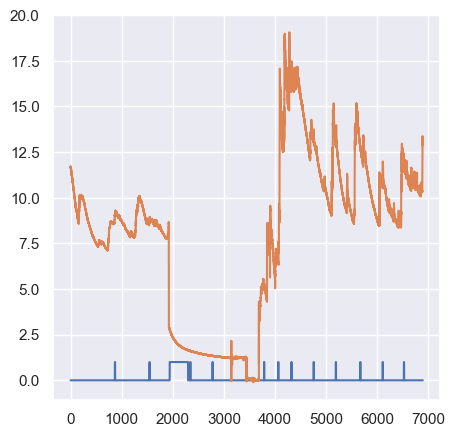

In [37]:
plt.plot(dataDF1['time'],dataDF1['startBlock'], label = 'startBlock')
plt.plot(dataDF1['time'],dataDF1.EDA)

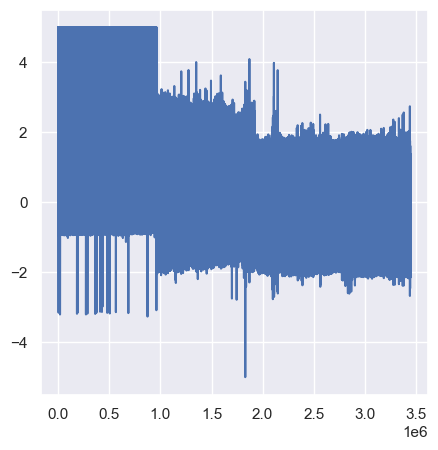

In [38]:
plt.plot(dataDF1.EKG)

In [39]:
dataDF1.loc[(dataDF1['time']>1651)&(dataDF1['time']<=1652) ]

,PART,EKG,EDA,CH28,CH29,CH30,CH31,CH32,CH33,CH34,...,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time
825501,P006,0.050507,8.60748,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.002,1651.002
825502,P006,0.077667,8.60596,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.004,1651.004
825503,P006,0.084839,8.60596,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.006,1651.006
825504,P006,0.081940,8.60596,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.008,1651.008
825505,P006,0.090942,8.60443,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.010,1651.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825996,P006,0.164642,8.59680,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.992,1651.992
825997,P006,0.132141,8.59528,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.994,1651.994
825998,P006,0.103455,8.59528,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.996,1651.996
825999,P006,0.086975,8.59528,0,0,5,0,0,0,0,...,0,0,0,0,1,0,0,0,1651.998,1651.998


In [40]:
dataDF1.loc[dataDF1['scream'] == 1].EDA.mean()

8.532948173379024

In [41]:
dataDF1.loc[dataDF1['noScream'] == 1].EDA.mean()

9.075803674143515

# Calculate conditions EDA average

In [42]:
grouped_df = dataDF1.groupby(['PART','scream','noScream']).EDA.mean()
part_edas = pd.DataFrame(columns = ['Part', 'Cond', 'Avg EDA'])

for i in dataDF1['PART'].unique():
        mat_part = transpose([[i] * 3 ,['general', 'noScream', 'scream'], grouped_df.loc[i].values])
        mat_part = pd.DataFrame(mat_part, columns=['Part', 'Cond', 'Avg EDA'])
        part_edas = pd.concat([part_edas, mat_part], axis = 0)
part_edas['Avg EDA'] = pd.to_numeric(part_edas['Avg EDA'])
part_edas

,Part,Cond,Avg EDA
0,P006,general,8.635159
1,P006,noScream,8.363447
2,P006,scream,8.394575
0,P005,general,1.592773
1,P005,noScream,1.685454
2,P005,scream,1.606409
0,P003,general,11.357174
1,P003,noScream,11.645779
2,P003,scream,11.030198


In [43]:
# Generate some random data for the plot
def plotBar3(part_edas,label_names=['general','scream','noScream']):
    sns.set_style('white')
    fig = figure(figsize=(20,10))
    
    
    x = np.array([1, 2, 3])
    y1 = part_edas.loc[part_edas['Cond'] == label_names[0]]['Avg EDA'].values
    y2 = part_edas.loc[part_edas['Cond'] == label_names[1]]['Avg EDA'].values
    y3 = part_edas.loc[part_edas['Cond'] == label_names[2]]['Avg EDA'].values
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()
    
    # Define the amount of jitter to add to the scatter points
    jitter = 0.1
    print(str(y1) + ";  mean: " + str(np.mean(y1)) )
    print(str(y2)  + ";  mean: " + str(np.mean(y2)))
    print(str(y3) + ";  mean: " + str(np.mean(y3)))

    # Plot the three bars with their respective scatter points and jitter
    ax.bar(x[0]-0.2, np.mean(y1), width=0.5, label=label_names[0], color='red')
    ax.scatter(x[0]-0.2 + np.random.uniform(-jitter, jitter, size=len(y1)), y1, color='black', alpha = 0.2)
    ax.bar(x[1], np.mean(y2), width=0.5, label=label_names[1], color='green')
    ax.scatter(x[1] + np.random.uniform(-jitter, jitter, size=len(y2)), y2, color='black', alpha = 0.2)
    ax.bar(x[2]+0.2, np.mean(y3), width=0.5, label=label_names[2], color='blue')
    ax.scatter(x[2]+0.2 + np.random.uniform(-jitter, jitter, size=len(y3)), y3, color='black', alpha = 0.2)
    
    # Set the axis labels and legend
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    
    ax.legend()
    
    plt.axhline(y=0,color = 'black',linestyle='--')
    
    
    # Show the plot
    plt.show()
    
    sns.despine()
    

[ 8.63515884  1.59277333 11.35717409];  mean: 7.19503541901213
[ 8.3945746   1.60640898 11.03019774];  mean: 7.010393772362879
[ 8.36344712  1.68545415 11.64577912];  mean: 7.2315601298926


<Figure size 2000x1000 with 0 Axes>

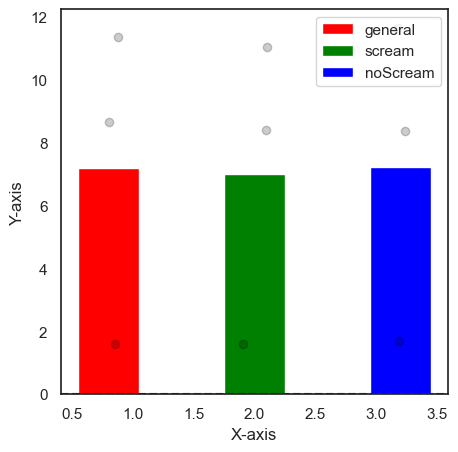

<Figure size 500x500 with 0 Axes>

In [44]:
plotBar3(part_edas,label_names=['general','scream','noScream'])

In [45]:
grouped_df = dataDF1.groupby(['PART','stimInfo','stimNoInfo']).EDA.mean()
part_edas = pd.DataFrame(columns = ['Part', 'Cond', 'Avg EDA'])

deltaCond = []

for i in dataDF1['PART'].unique():
        mat_part = transpose([[i] * 3 ,['general', 'stimInfo', 'stimNoInfo'], grouped_df.loc[i].values])
        
        deltaCond.append(grouped_df.loc[i].values[1] - grouped_df.loc[i].values[2]) # info- NoInfo
        mat_part = pd.DataFrame(mat_part, columns=['Part', 'Cond', 'Avg EDA'])
        part_edas = pd.concat([part_edas, mat_part], axis = 0)
part_edas['Avg EDA'] = pd.to_numeric(part_edas['Avg EDA'])
part_edas

,Part,Cond,Avg EDA
0,P006,general,8.673381
1,P006,stimInfo,8.408595
2,P006,stimNoInfo,8.369116
0,P005,general,1.599707
1,P005,stimInfo,1.608879
2,P005,stimNoInfo,1.565374
0,P003,general,11.414564
1,P003,stimInfo,11.160994
2,P003,stimNoInfo,11.339546


In [46]:
deltaCond

[0.03947865615107915, 0.0435047728402731, -0.1785513936959564]

[ 8.67338055  1.59970745 11.41456414];  mean: 7.2292173776922395
[ 8.4085948   1.60887869 11.16099425];  mean: 7.059489244732767
[ 8.36911614  1.56537392 11.33954564];  mean: 7.091345232967636


<Figure size 2000x1000 with 0 Axes>

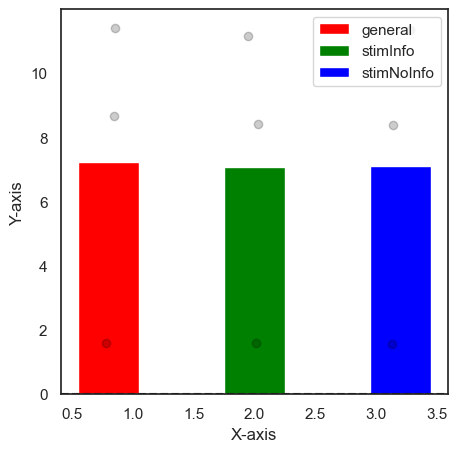

<Figure size 500x500 with 0 Axes>

In [47]:
plotBar3(part_edas,label_names=['general','stimInfo','stimNoInfo'])


# identify beginning of events

In [48]:
dataDF1 = dataDF1.drop(['CH28','CH29','CH30','CH31','CH32','CH33','CH34','CH35'], axis=1)

In [49]:
dataDF1

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time
0,P006,-0.153503,11.7081,0,0,0,0,0,0,0,0,0.000,0.000
1,P006,-0.149689,11.7081,0,0,0,0,0,0,0,0,0.002,0.002
2,P006,-0.153656,11.7065,0,0,0,0,0,0,0,0,0.004,0.004
3,P006,-0.161133,11.7081,0,0,0,0,0,0,0,0,0.006,0.006
4,P006,-0.157013,11.7111,0,0,0,0,0,0,0,0,0.008,0.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445507,P003,-0.621338,13.1302,0,0,0,0,0,0,0,0,3048.277,6891.014
3445508,P003,-0.600433,13.1302,0,0,0,0,0,0,0,0,3048.279,6891.016
3445509,P003,-0.347595,13.1302,0,0,0,0,0,0,0,0,3048.281,6891.018
3445510,P003,-0.464325,13.1302,0,0,0,0,0,0,0,0,3048.283,6891.020


In [50]:

labelOnsets = ["startTrial","scream",'noScream','infoChoice','stimInfo','stimNoInfo','startBlock']


for i in labelOnsets:
    dataDF1[i + "Onset"] = np.logical_xor(dataDF1.shift(periods = 1)[i].values, dataDF1[i].values) & (dataDF1.shift(periods = 2)[i].values == 0) #np.logical_or(dataDF1.shift(periods = 500)['stimNoInfo'].values,dataDF1.shift(periods = 500)['stimInfo'].values) 

    
    #dataDF1['noScreamOnset'] = np.logical_xor(dataDF1.shift(periods = 1)['noScream'].values, dataDF1['scream'].values) & (dataDF1.shift(periods = 2)['scream'].values == 1) #np.logical_or(dataDF1.shift(periods = 500)['stimNoInfo'].values,dataDF1.shift(periods = 500)['stimInfo'].values) 

#dataDF1['trialOnset'] = np.logical_xor(dataDF1.shift(periods = 1)['startTrial'].values, dataDF1['startTrial'].values) & (dataDF1.shift(periods = 2)['startTrial'].values == 1)
#dataDF1['trialOnset'] = np.logical_xor(dataDF1.shift(periods = 1)['startTrial'].values, dataDF1['startTrial'].values) & (dataDF1.shift(periods = 2)['startTrial'].values == 1)


In [51]:
dataDF1_short = dataDF1.loc[(dataDF1['time']>1680)&(dataDF1['time']<1690) ]

In [52]:
#dataDF1_short["screamOnset"] = dataDF1_short["screamOnset"]*0

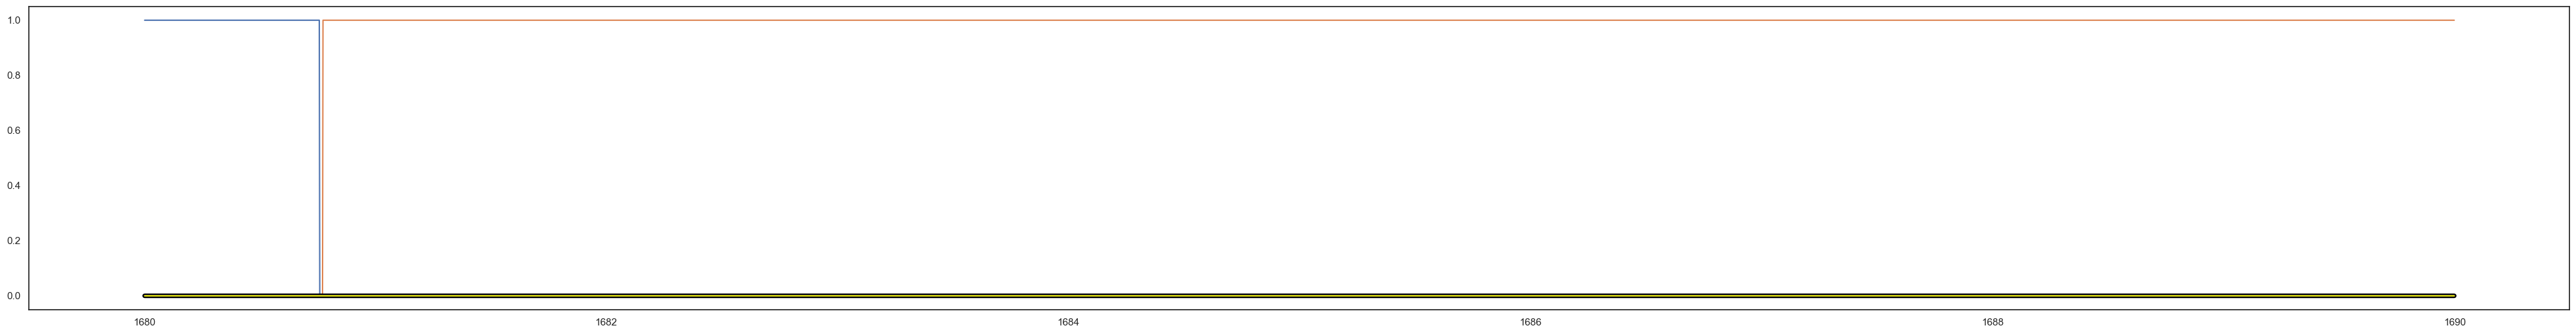

In [53]:
plt.figure(figsize=(50,6))

plt.plot(dataDF1_short['time'],dataDF1_short['startTrial'], label = 'startTrial',color= 'Black',linewidth=3)
plt.plot(dataDF1_short['time'],dataDF1_short['infoChoice'], label = 'infoChoice')
plt.plot(dataDF1_short['time'],dataDF1_short['stimInfo'], label = 'stimInfo')
plt.plot(dataDF1_short['time'],dataDF1_short['stimNoInfo'], label = 'stimNoInfo')

plt.plot(dataDF1_short['time'],dataDF1_short['scream'], label = 'scream',color= 'Green',linewidth=2)
plt.plot(dataDF1_short['time'],dataDF1_short['noScream'], label = 'noScream',color= 'Red',linewidth=2)
plt.plot(dataDF1_short['time'],dataDF1_short['endTrial'], label = 'endTrial',color= 'Black',linewidth=2)
#
plt.plot(dataDF1_short['time'],dataDF1_short['screamOnset']/3, label = 'screamOnset',color = 'black',linewidth=5)
plt.plot(dataDF1_short['time'],dataDF1_short['startTrialOnset']/3, label = 'startTrialOnset',color = 'blue')
plt.plot(dataDF1_short['time'],dataDF1_short['noScreamOnset']/3, label = 'noScreamOnset',color = 'yellow')
#plt.plot(dataDF1_short['time'],dataDF1_short['trials']/60, label = 'trials',color = 'black')

In [54]:
dataDF1_short

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset
840001,P006,-0.060730,8.76312,0,0,1,0,0,0,0,0,1680.002,1680.002,False,False,False,False,False,False,False
840002,P006,-0.050507,8.76617,0,0,1,0,0,0,0,0,1680.004,1680.004,False,False,False,False,False,False,False
840003,P006,-0.052948,8.76312,0,0,1,0,0,0,0,0,1680.006,1680.006,False,False,False,False,False,False,False
840004,P006,-0.062866,8.76617,0,0,1,0,0,0,0,0,1680.008,1680.008,False,False,False,False,False,False,False
840005,P006,-0.069275,8.76617,0,0,1,0,0,0,0,0,1680.010,1680.010,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844995,P006,-0.074768,8.59680,0,0,0,1,0,0,0,0,1689.990,1689.990,False,False,False,False,False,False,False
844996,P006,-0.119171,8.59222,0,0,0,1,0,0,0,0,1689.992,1689.992,False,False,False,False,False,False,False
844997,P006,-0.161591,8.59985,0,0,0,1,0,0,0,0,1689.994,1689.994,False,False,False,False,False,False,False
844998,P006,-0.190277,8.59375,0,0,0,1,0,0,0,0,1689.996,1689.996,False,False,False,False,False,False,False


In [55]:
dataDF1

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset
0,P006,-0.153503,11.7081,0,0,0,0,0,0,0,0,0.000,0.000,False,False,False,False,False,False,False
1,P006,-0.149689,11.7081,0,0,0,0,0,0,0,0,0.002,0.002,False,False,False,False,False,False,False
2,P006,-0.153656,11.7065,0,0,0,0,0,0,0,0,0.004,0.004,False,False,False,False,False,False,False
3,P006,-0.161133,11.7081,0,0,0,0,0,0,0,0,0.006,0.006,False,False,False,False,False,False,False
4,P006,-0.157013,11.7111,0,0,0,0,0,0,0,0,0.008,0.008,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445507,P003,-0.621338,13.1302,0,0,0,0,0,0,0,0,3048.277,6891.014,False,False,False,False,False,False,False
3445508,P003,-0.600433,13.1302,0,0,0,0,0,0,0,0,3048.279,6891.016,False,False,False,False,False,False,False
3445509,P003,-0.347595,13.1302,0,0,0,0,0,0,0,0,3048.281,6891.018,False,False,False,False,False,False,False
3445510,P003,-0.464325,13.1302,0,0,0,0,0,0,0,0,3048.283,6891.020,False,False,False,False,False,False,False


In [56]:
#np.logical_xor(dataDF1.shift(periods = 1)['scream'].values, dataDF1['scream'].values)

In [57]:
#plt.plot(np.logical_xor(dataDF1.shift(periods = 1)['scream'].values, dataDF1['scream'].values) & np.logical_or(dataDF1.shift(periods = 500)['stimNoInfo'].values,dataDF1.shift(periods = 500)['stimInfo'].values))

In [58]:
#plt.plot(np.logical_xor(dataDF1.shift(periods = 1)['startTrial'].values, dataDF1['startTrial'].values) )

# Numerate the trials

In [59]:
dataDF1

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,endTrial,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset
0,P006,-0.153503,11.7081,0,0,0,0,0,0,0,0,0.000,0.000,False,False,False,False,False,False,False
1,P006,-0.149689,11.7081,0,0,0,0,0,0,0,0,0.002,0.002,False,False,False,False,False,False,False
2,P006,-0.153656,11.7065,0,0,0,0,0,0,0,0,0.004,0.004,False,False,False,False,False,False,False
3,P006,-0.161133,11.7081,0,0,0,0,0,0,0,0,0.006,0.006,False,False,False,False,False,False,False
4,P006,-0.157013,11.7111,0,0,0,0,0,0,0,0,0.008,0.008,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445507,P003,-0.621338,13.1302,0,0,0,0,0,0,0,0,3048.277,6891.014,False,False,False,False,False,False,False
3445508,P003,-0.600433,13.1302,0,0,0,0,0,0,0,0,3048.279,6891.016,False,False,False,False,False,False,False
3445509,P003,-0.347595,13.1302,0,0,0,0,0,0,0,0,3048.281,6891.018,False,False,False,False,False,False,False
3445510,P003,-0.464325,13.1302,0,0,0,0,0,0,0,0,3048.283,6891.020,False,False,False,False,False,False,False


In [60]:
trialsNumer = []
for i in dataDF1.PART.unique():
    
    dataDFPart = dataDF1.loc[dataDF1.PART == i]
    #trialsNumer = [0] * len(dataDFPart)
    #dataDFPart["startTrialOnset"].values
    #numTrials = list(range(len(dataDFPart[== 1])))
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values)

dataDF1["trials"] =  trialsNumer

In [61]:
dataDF1

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset,trials
0,P006,-0.153503,11.7081,0,0,0,0,0,0,0,...,0.000,0.000,False,False,False,False,False,False,False,0
1,P006,-0.149689,11.7081,0,0,0,0,0,0,0,...,0.002,0.002,False,False,False,False,False,False,False,0
2,P006,-0.153656,11.7065,0,0,0,0,0,0,0,...,0.004,0.004,False,False,False,False,False,False,False,0
3,P006,-0.161133,11.7081,0,0,0,0,0,0,0,...,0.006,0.006,False,False,False,False,False,False,False,0
4,P006,-0.157013,11.7111,0,0,0,0,0,0,0,...,0.008,0.008,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445507,P003,-0.621338,13.1302,0,0,0,0,0,0,0,...,3048.277,6891.014,False,False,False,False,False,False,False,130
3445508,P003,-0.600433,13.1302,0,0,0,0,0,0,0,...,3048.279,6891.016,False,False,False,False,False,False,False,130
3445509,P003,-0.347595,13.1302,0,0,0,0,0,0,0,...,3048.281,6891.018,False,False,False,False,False,False,False,130
3445510,P003,-0.464325,13.1302,0,0,0,0,0,0,0,...,3048.283,6891.020,False,False,False,False,False,False,False,130


# check that we are actually picking the onsets

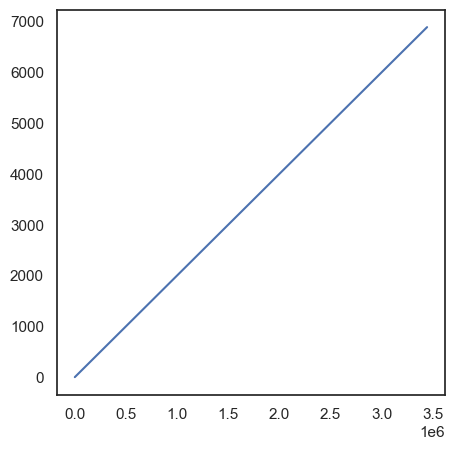

In [62]:
plt.plot(dataDF1['time'])

In [63]:
dataDF1_short = dataDF1.loc[(dataDF1['time']>400)&(dataDF1['time']<600) ]

In [64]:
dataDF1_short.PART.unique()

array(['P006'], dtype=object)

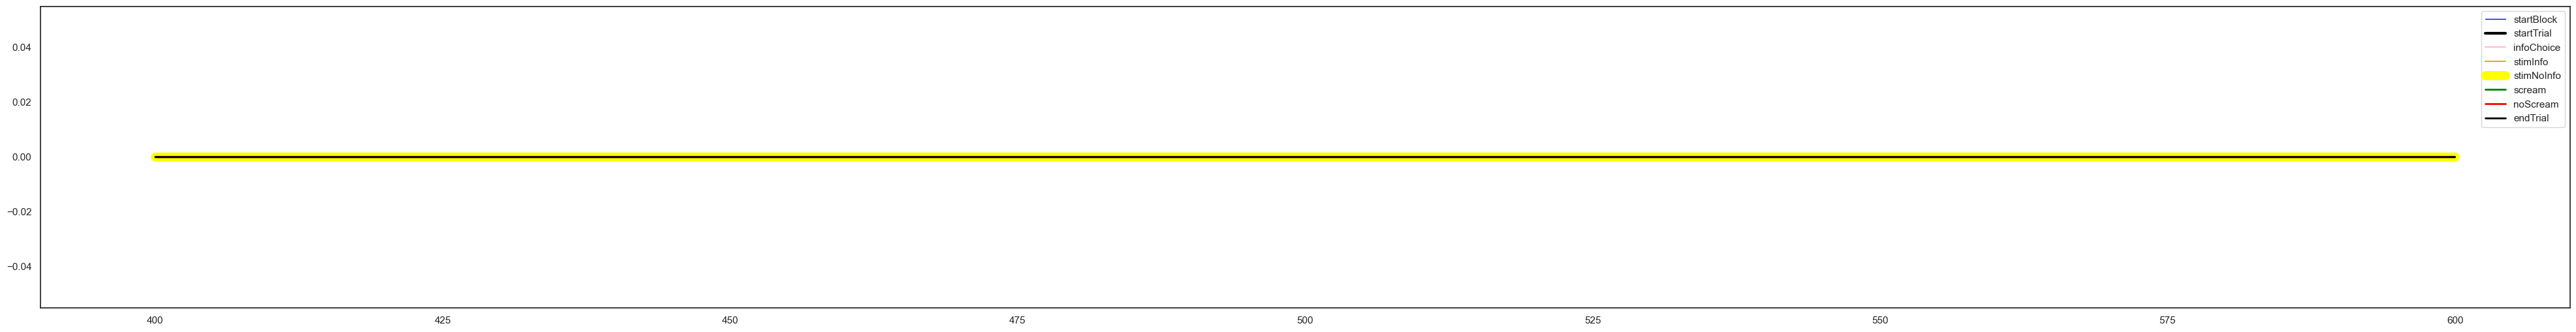

In [65]:
plt.figure(figsize=(50,6))

plt.plot(dataDF1_short['time'],dataDF1_short['startBlock'], label = 'startBlock',color= 'Blue',linewidth=1)
plt.plot(dataDF1_short['time'],dataDF1_short['startTrial'], label = 'startTrial',color= 'Black',linewidth=3)
plt.plot(dataDF1_short['time'],dataDF1_short['infoChoice'], label = 'infoChoice',color = 'Pink')
plt.plot(dataDF1_short['time'],dataDF1_short['stimInfo'], label = 'stimInfo',color = 'orange')
plt.plot(dataDF1_short['time'],dataDF1_short['stimNoInfo'], label = 'stimNoInfo',color= 'Yellow',linewidth=10)

plt.plot(dataDF1_short['time'],dataDF1_short['scream'], label = 'scream',color= 'Green',linewidth=2)
plt.plot(dataDF1_short['time'],dataDF1_short['noScream'], label = 'noScream',color= 'Red',linewidth=2)
plt.plot(dataDF1_short['time'],dataDF1_short['endTrial'], label = 'endTrial',color= 'Black',linewidth=2)
#
#plt.plot(dataDF1_short['time'],dataDF1_short['screamOnset']/3, label = 'screamOnset',color = 'black',linewidth=5)
#plt.plot(dataDF1_short['time'],dataDF1_short['startTrialOnset']/3, label = 'startTrialOnset',color = 'blue')
#plt.plot(dataDF1_short['time'],dataDF1_short['noScreamOnset']/3, label = 'noScreamOnset',color = 'yellow')
#plt.plot(dataDF1_short['time'],dataDF1_short['trials']/60, label = 'trials',color = 'black')

#plt.plot(dataDF1_short['time'],dataDF1_short['EDA'], label = 'EDA',color = 'black')



plt.legend()

# z_score EDA by trial

In [66]:
zEDA = []

for i in dataDF1.PART.unique():
    print('Participant.....' + str(i))
    EDAInfoPart = dataDF1.loc[dataDF1['PART'] == i]
    
    #for session in EDAInfoPart['session'].unique():
     #       sessData = (EDAInfoPart[EDAInfoPart['session'] ==session])
    
    for j in EDAInfoPart['trials'].unique():
                    EDAInfoPTrial = EDAInfoPart.loc[EDAInfoPart['trials'] == j]            
    
                    # EDA size
                    EDATrial = EDAInfoPTrial.EDA.values.astype('float')
                    zEDAInfoPTrial = (EDATrial - np.nanmean(EDATrial))/np.nanstd(EDATrial)       
    
                    zEDA.extend(zEDAInfoPTrial) 

dataDF1['zEDA'] = zEDA


Participant.....P006
Participant.....P005
Participant.....P003


In [67]:
dataDF1.loc[dataDF1["stimInfo"] == 1]

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,...,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset,trials,zEDA
468707,P006,-0.591583,8.93707,0,0,0,1,0,0,0,...,937.414,False,False,False,False,True,False,False,4,-0.026218
468708,P006,-0.584106,8.93860,0,0,0,1,0,0,0,...,937.416,False,False,False,False,False,False,False,4,0.002873
468709,P006,-0.580750,8.93402,0,0,0,1,0,0,0,...,937.418,False,False,False,False,False,False,False,4,-0.084209
468710,P006,-0.560303,8.93249,0,0,0,1,0,0,0,...,937.420,False,False,False,False,False,False,False,4,-0.113300
468711,P006,-0.539398,8.93249,0,0,0,1,0,0,0,...,937.422,False,False,False,False,False,False,False,4,-0.113300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436549,P003,-0.374603,10.37290,0,0,0,1,0,0,0,...,6873.098,False,False,False,False,False,False,False,130,-0.702490
3436550,P003,-0.375214,10.37750,0,0,0,1,0,0,0,...,6873.100,False,False,False,False,False,False,False,130,-0.698745
3436551,P003,-0.370178,10.37450,0,0,0,1,0,0,0,...,6873.102,False,False,False,False,False,False,False,130,-0.701188
3436552,P003,-0.371704,10.37290,0,0,0,1,0,0,0,...,6873.104,False,False,False,False,False,False,False,130,-0.702490


In [68]:
dataDF1

,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,noScream,...,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,startBlockOnset,trials,zEDA
0,P006,-0.153503,11.7081,0,0,0,0,0,0,0,...,0.000,False,False,False,False,False,False,False,0,2.706754
1,P006,-0.149689,11.7081,0,0,0,0,0,0,0,...,0.002,False,False,False,False,False,False,False,0,2.706754
2,P006,-0.153656,11.7065,0,0,0,0,0,0,0,...,0.004,False,False,False,False,False,False,False,0,2.705342
3,P006,-0.161133,11.7081,0,0,0,0,0,0,0,...,0.006,False,False,False,False,False,False,False,0,2.706754
4,P006,-0.157013,11.7111,0,0,0,0,0,0,0,...,0.008,False,False,False,False,False,False,False,0,2.709401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445507,P003,-0.621338,13.1302,0,0,0,0,0,0,0,...,6891.014,False,False,False,False,False,False,False,130,1.542023
3445508,P003,-0.600433,13.1302,0,0,0,0,0,0,0,...,6891.016,False,False,False,False,False,False,False,130,1.542023
3445509,P003,-0.347595,13.1302,0,0,0,0,0,0,0,...,6891.018,False,False,False,False,False,False,False,130,1.542023
3445510,P003,-0.464325,13.1302,0,0,0,0,0,0,0,...,6891.020,False,False,False,False,False,False,False,130,1.542023


In [69]:
dataDF1['PART'].unique()

array(['P006', 'P005', 'P003'], dtype=object)

In [70]:
dataDF1 = pd.read_csv("dataDF1_preproc.csv")

# Extract events

In [71]:
#startTrial  for baseline we use 3 secs prior to the event and 2 seconds after 
#infoChoice begining of the choice period
#noInfo   beginning of the info period, immediately after choice
#yesInfo   beginning of the info period , immediately after choice
#noScream  no Scream delivery
#yesScrea  Scream delivery
#endTrial  end of the trial
#              1              2        3        4          5            6         7

#labels = ['startTrial','infoChoice','yesInfo','noInfo','yesScream','noScream','endTrial']
#labelOnsets = ["startTrial","scream",'noScream','infoChoice','stimInfo','stimNoInfo']

#eventLabels = [1,2,3,4,5,6,7]


labelOnsets = ["startTrialOnset","screamOnset",'noScreamOnset','infoChoiceOnset','stimInfoOnset','stimNoInfoOnset']

dataDic1 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}
dataDic2 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}



channelSelect = ['EKG','zEDA']

dataDicAll = {channelSelect[0]: dataDic1 ,channelSelect[1]: dataDic2 }

sampleRate = 500 # Hz, samples per second
intervalSelect = 4 # interval in seconds to consider for EKG (CH1) and EDA (CH2) data

ic = 0


for c in channelSelect:
    eLabel = 0
    #selectColumn = dataDF1[c].values
    
    for ev in labelOnsets:
        concatSignal = []
        for ii in dataDF1.loc[dataDF1[ev] == 1].index.values:
            
            aa = dataDF1.iloc[ii - (intervalSelect*sampleRate): ii  + (intervalSelect*sampleRate)][c].values
            if len(aa) ==  intervalSelect*sampleRate*2:
                concatSignal.append(aa)  
                
            elif len(aa)< intervalSelect*sampleRate*2:
                num = intervalSelect*sampleRate*2-len(aa)
                concatSignal.append(np.append(aa,[np.nan]*num))
            else:
                print("skip trial: "  +  str(ii))
                
        #eLabel += 1 
        #print(c)
        dataDicAll[c][ev] = concatSignal
        print(ev)
    #ic += 1

startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset
startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset


### Extract Noisy Data
#### P005,P007,P016

In [72]:
#startTrial  for baseline we use 3 secs prior to the event and 2 seconds after 
#infoChoice begining of the choice period
#noInfo   beginning of the info period, immediately after choice
#yesInfo   beginning of the info period , immediately after choice
#noScream  no Scream delivery
#yesScrea  Scream delivery
#endTrial  end of the trial
#              1              2        3        4          5            6         7

#labels = ['startTrial','infoChoice','yesInfo','noInfo','yesScream','noScream','endTrial']
#labelOnsets = ["startTrial","scream",'noScream','infoChoice','stimInfo','stimNoInfo']

#eventLabels = [1,2,3,4,5,6,7]

clean_dataDF1 = dataDF1.copy()
clean_dataDF1 = clean_dataDF1.loc[(clean_dataDF1['PART'] != 'P005') & (clean_dataDF1['PART'] != 'P007') & (clean_dataDF1['PART'] != 'P016')]

labelOnsets = ["startTrialOnset","screamOnset",'noScreamOnset','infoChoiceOnset','stimInfoOnset','stimNoInfoOnset']

clean_dataDic1 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}
clean_dataDic2 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}



channelSelect = ['EKG','zEDA']

clean_dataDicAll = {channelSelect[0]: clean_dataDic1 ,channelSelect[1]: clean_dataDic2 }

sampleRate = 500 # Hz, samples per second
intervalSelect = 4 # interval in seconds to consider for EKG (CH1) and EDA (CH2) data

ic = 0


for c in channelSelect:
    eLabel = 0
    #selectColumn = dataDF1[c].values
    
    for ev in labelOnsets:
        concatSignal = []
        for ii in clean_dataDF1.loc[clean_dataDF1[ev] == 1].index.values:
            
            aa = clean_dataDF1.iloc[ii - (intervalSelect*sampleRate): ii  + (intervalSelect*sampleRate)][c].values
            if len(aa) ==  intervalSelect*sampleRate*2:
                concatSignal.append(aa)  
                
            elif len(aa)< intervalSelect*sampleRate*2:
                num = intervalSelect*sampleRate*2-len(aa)
                concatSignal.append(np.append(aa,[np.nan]*num))
            else:
                print("skip trial: "  +  str(ii))
                
        #eLabel += 1 
        #print(c)
        clean_dataDicAll[c][ev] = concatSignal
        print(ev)
    #ic += 1

startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset
startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset


In [588]:
def show_raw_signal(pupilBase1,pupilBase2,event_time, titleL = "",labFrame = ['No Scream','Scream'], yLabel = ['EDA']):

    
    figsize(15, 5)
    # extract data1

    sample_factor = 500 # sampling rate for the dataset
    
    
    
    baseTimeMean1 =np.nanmean(pupilBase1, axis= 0)
    baseTimeStd1 =scipy.stats.sem(pupilBase1, axis= 0,nan_policy='omit')
    
    # extract data2    
    baseTimeMean2 =np.nanmean(pupilBase2, axis= 0)
    baseTimeStd2 =scipy.stats.sem(pupilBase2, axis= 0,nan_policy='omit')

    
    #xsecs = range(0,len(instantEffectDDT_like))
    colorP = ['#5BC8AF','#a4ded0','#F9CB40','#fae196','#4F6A9A','#AC5255','#B5C8E9','#F2CECF']
    xSecs = np.array(range(0,len(baseTimeMean1)))
    #plot low    
    plt.errorbar((xSecs/sample_factor)-4,baseTimeMean2, yerr= baseTimeStd2, color='#8DB38B',marker='', alpha = 0.005 );
    plot((xSecs/sample_factor)-4,baseTimeMean2,color='#8DB38B',label = labFrame[1],ls = '-')
    
    #plot High
    plt.errorbar((xSecs/sample_factor)-4,baseTimeMean1, yerr= baseTimeStd1, color='#FD7E84',marker='', alpha = 0.005 );
    plot((xSecs/sample_factor)-4,baseTimeMean1,color='#FD7E84',label = labFrame[0],ls = '-')
    
    
    plt.axvline(event_time/sample_factor-4, color='#0B3954', lw=2, alpha=0.8,ls = '--',label = 'outcome')

    #plt.title(titleL,size=18)
    plt.xlabel("Time(s)",size=20)
    plt.ylabel(yLabel,size=20)
    # since we have 500 hz samples (i.e. the distance between each sample is 2ms) we multiple by 2 the interval
    #plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
    #    int(-event_time*2),int(-event_time/2*2) ,0, int(event_time/2*2),int((len(xSecs)-event_time)*2) ],fontsize= 15)


    #plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
    #int(-event_time*sample_factor),int(-event_time/2*sample_factor) ,0, int(event_time/2*sample_factor),int((len(xSecs)-event_time)*sample_factor) ],fontsize= 15)
    plt.xticks(fontsize= 25)
    plt.yticks(fontsize= 25)
    
    
    plt.legend(frameon=False, fontsize = 25)
    sns.set_style("white")
    sns.despine()

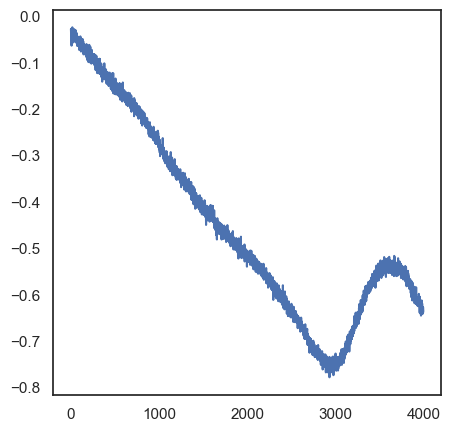

In [74]:
plt.plot(np.nanmean(dataDicAll['zEDA']['screamOnset'], axis= 0))

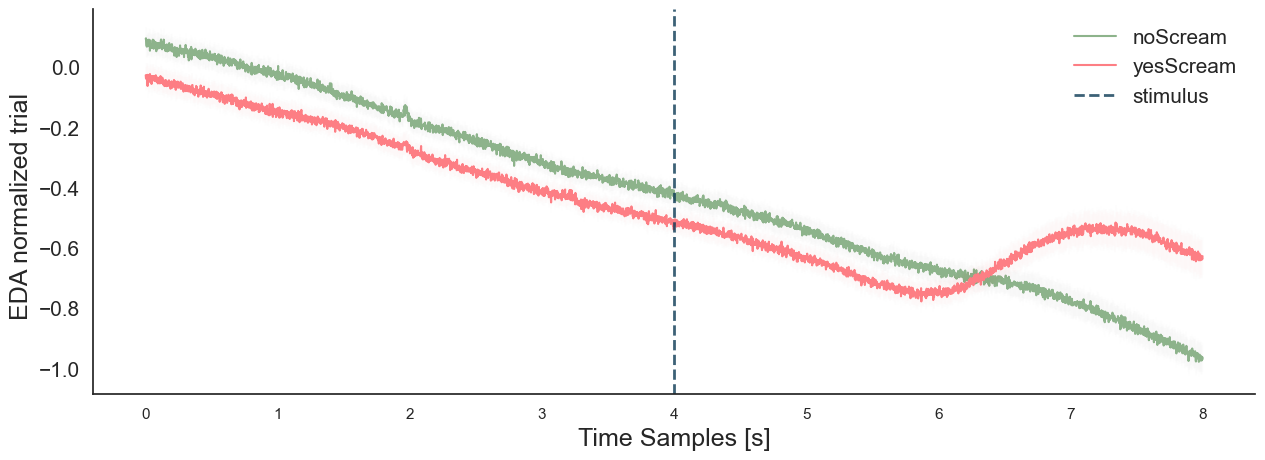

In [75]:
show_raw_signal(dataDicAll['zEDA']['noScreamOnset'],dataDicAll['zEDA']['screamOnset'],4*sampleRate,titleL = 'Skin Conductance / Outcome time',labFrame = ['noScream','yesScream'],yLabel = 'EDA normalized trial ')

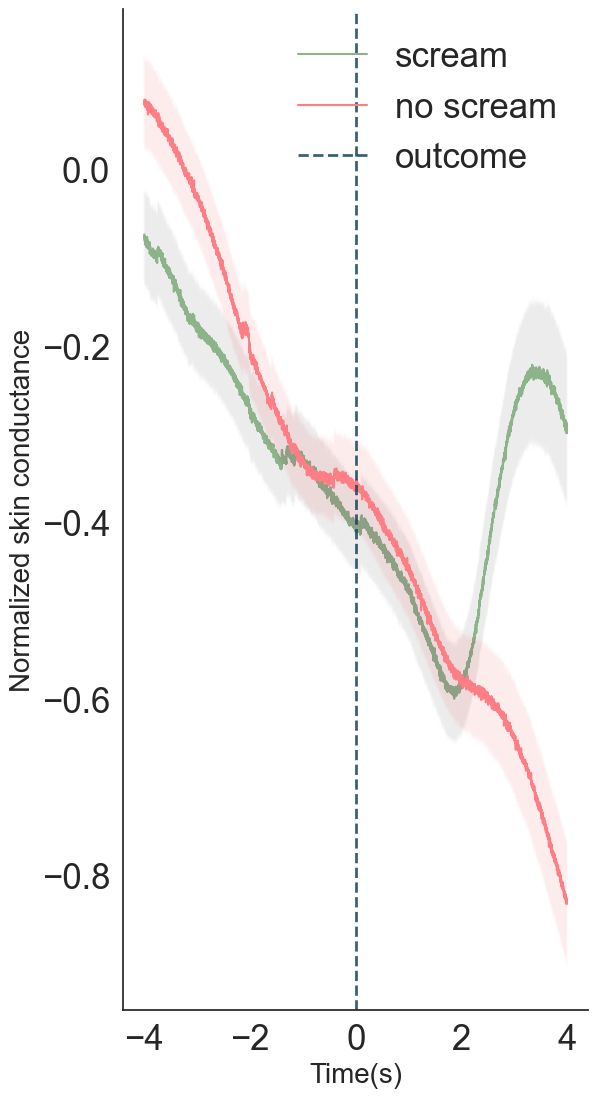

In [589]:
###USE THIS GRAPH
import matplotlib.pyplot as plt

# Assuming you have a function `show_raw_signal` that creates the plot
# Replace the function call below with your actual function call.
# For this example, I'm just using a placeholder function call.
show_raw_signal(clean_dataDicAll['zEDA']['noScreamOnset'], clean_dataDicAll['zEDA']['screamOnset'],
                4 * sampleRate, titleL='Skin Conductance / Outcome time',
                labFrame=['no scream', 'scream'], yLabel='Normalized skin conductance')


# Get the current figure object
fig = plt.gcf()

# Set the figure size (adjust the width and height as needed)
fig.set_size_inches(6, 13)  # Width, Height

# Save the figure to a file
plt.savefig('EDA_scream_vs_noScream.png', bbox_inches='tight')
plt.show()


In [ ]:
show_raw_signal(dataDicAll['zEDA']['stimNoInfoOnset'],dataDicAll['zEDA']['stimInfoOnset'],4*sampleRate,titleL = 'Skin Conductance / Information time',labFrame = ['noInfo','yesInfo'],yLabel = 'EDA normalized trial')

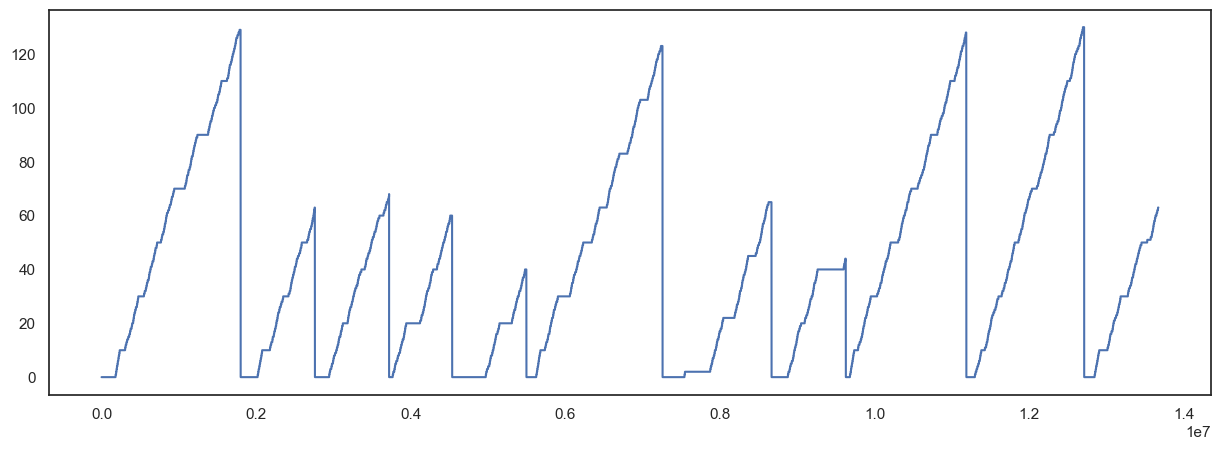

In [78]:
plt.plot(dataDF1.trials)

# Separate early and late changes

In [79]:
grouped_df = dataDF1.loc[dataDF1["trials"] <40].groupby(['PART','scream','noScream']).zEDA.mean()
part_edas = pd.DataFrame(columns = ['Part', 'Cond', 'Avg EDA'])

for i in dataDF1['PART'].unique():
        mat_part = transpose([[i] * 3 ,['general', 'noScream', 'scream'], grouped_df.loc[i].values])
        mat_part = pd.DataFrame(mat_part, columns=['Part', 'Cond', 'Avg EDA'])
        part_edas = pd.concat([part_edas, mat_part], axis = 0)
part_edas['Avg EDA'] = pd.to_numeric(part_edas['Avg EDA'])
part_edas

,Part,Cond,Avg EDA
0,P032,general,0.019568
1,P032,noScream,-0.300175
2,P032,scream,-0.061766
0,P017_1,general,0.061420
1,P017_1,noScream,-0.017903
2,P017_1,scream,-0.803734
0,P025,general,0.041260
1,P025,noScream,-0.509126
2,P025,scream,-0.245848
0,P017_2,general,0.081410


[0.01956776 0.06142014 0.0412596  0.08141046 0.04632399 0.02711951
 0.02442387 0.08334139 0.10161269 0.06482702 0.08612   ];  mean: 0.057947858135339446
[-0.06176594 -0.80373357 -0.24584801 -0.89663711 -0.86081747  0.24288092
 -0.21977512 -0.85790187 -0.76807377 -0.57580772 -0.97712905];  mean: -0.5476917012377946
[-0.3001753  -0.01790272 -0.50912579 -0.48384306 -0.54085061 -0.62688883
 -0.75897574 -0.66815691 -0.72783252 -0.51216925 -0.74422272];  mean: -0.5354675865645269


<Figure size 2000x1000 with 0 Axes>

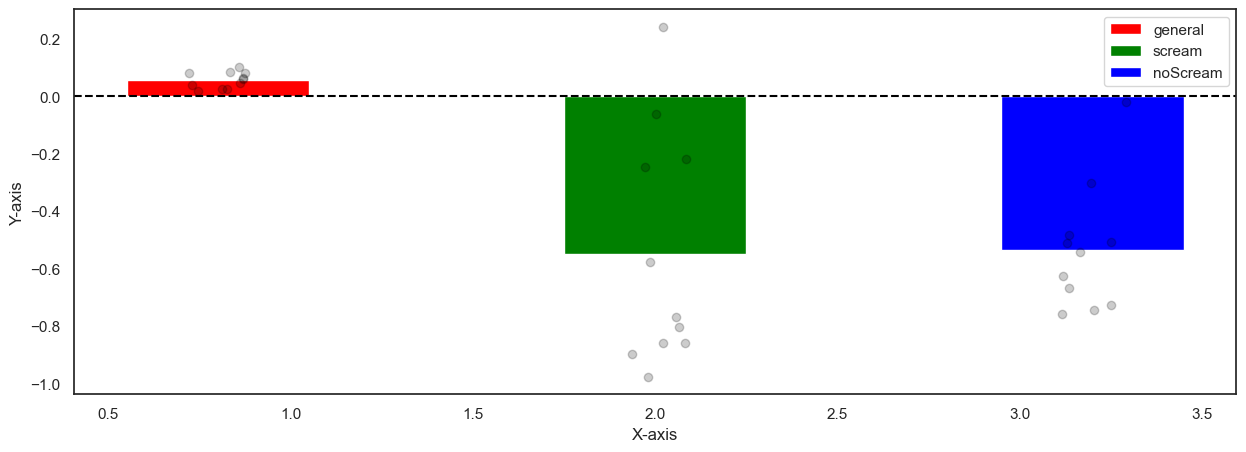

<Figure size 1500x500 with 0 Axes>

In [80]:
plotBar3(part_edas,label_names=['general','scream','noScream'])

In [81]:
grouped_df = dataDF1.loc[dataDF1["trials"] >40].groupby(['PART','scream','noScream']).zEDA.mean()
part_edas = pd.DataFrame(columns = ['Part', 'Cond', 'Avg EDA'])

for i in dataDF1.loc[dataDF1["trials"] >40]['PART'].unique():
        mat_part = transpose([[i] * 3 ,['general', 'noScream', 'scream'], grouped_df.loc[i].values])
        mat_part = pd.DataFrame(mat_part, columns=['Part', 'Cond', 'Avg EDA'])
        part_edas = pd.concat([part_edas, mat_part], axis = 0)
part_edas['Avg EDA'] = pd.to_numeric(part_edas['Avg EDA'])
part_edas


,Part,Cond,Avg EDA
0,P032,general,0.125415
1,P032,noScream,-0.956052
2,P032,scream,-0.968819
0,P017_1,general,0.118318
1,P017_1,noScream,-0.642154
2,P017_1,scream,-0.903283
0,P025,general,0.085817
1,P025,noScream,-0.372405
2,P025,scream,-0.768561
0,P017_2,general,0.066684


In [82]:
edaPartDF = pd.DataFrame()

In [83]:
edaPartDF["edaScream"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]["scream"] 
edaPartDF["edaNoScream"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]["noScream"]

edaPartDF["DEdaScreamOutcome"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]["scream"] -  part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]["noScream"]
edaPartDF["participant"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Part"]


#edaPartDF["participant"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Part"]

# join P07 data
edaPartDF.loc[len(edaPartDF.index)] = [np.mean([-0.903283,0.127261]), np.mean([0.642154,-0.859270]), np.mean([0.261129,0.986531]), "P017"] 

replace_dict = {"P001": "AV_P001", "P003": "AV_P003", "P005": "AV_P005","P006": "AV_P006","P007": "AV_P007","P010": "AV_P010","P013": "AV_P013","P016": "AV_P016","P017": "AV_P017","P025": "AV_P025","P030": "AV_P030","P032": "AV_P032"}

edaPartDF["participant"] = edaPartDF["participant"].replace(replace_dict)
edaPartDF = edaPartDF.dropna()
edaPartDF = edaPartDF.sort_values(by='participant')
edaPartDF = edaPartDF.reset_index(drop = True)
edaPartDF.to_csv("edaAnalysisByPart.csv")


In [84]:
edaPartDF

,edaScream,edaNoScream,DEdaScreamOutcome,participant
0,-0.756782,-0.560741,-0.196041,AV_P003
1,-0.971839,-0.999625,0.027786,AV_P005
2,-0.978072,-0.735329,-0.242743,AV_P007
3,-0.780206,-0.485830,-0.294376,AV_P010
4,-0.124913,-0.423559,0.298646,AV_P013
5,-1.113766,-1.032739,-0.081027,AV_P016
6,-0.388011,-0.108558,0.623830,AV_P017
7,-0.768561,-0.372405,-0.396156,AV_P025
8,-0.968819,-0.956052,-0.012767,AV_P032
9,-0.903283,-0.642154,-0.261129,P017_1


In [85]:

#part_edas
#


#pupilDF["pupilNoInfo_Scream-"] = part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]['scream'] - part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]['noScream']
#pupilDF["pupilNoInfo_Scream-"]
#part_edas.groupby(["Part","Cond"]).mean().unstack().reset_index()["Avg EDA"]['scream']
#
#

[0.12541511 0.11831769 0.08581748 0.06668447 0.03851297 0.10915279
 0.24186212 0.09259582 0.10710104 0.12654143];  mean: 0.11120009242737491
[-0.96881913 -0.90328315 -0.76856071  0.12726087 -0.12491322 -0.97807179
 -0.97183862 -0.78020647 -0.75678161 -1.11376588];  mean: -0.7238979723110786
[-0.95605203 -0.64215402 -0.37240479 -0.85927024 -0.42355928 -0.73532898
 -0.99962508 -0.48583015 -0.56074075 -1.03273896];  mean: -0.7067704290354719


<Figure size 2000x1000 with 0 Axes>

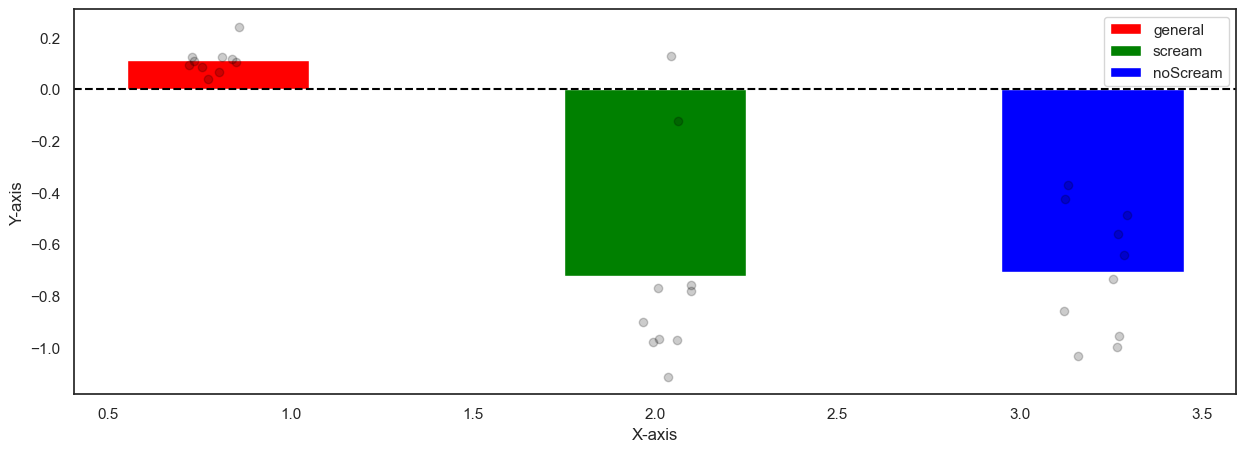

<Figure size 1500x500 with 0 Axes>

In [86]:
plotBar3(part_edas,label_names=['general','scream','noScream'])

# Estimate EDA difference only from initial trials

In [87]:
#startTrial  for baseline we use 3 secs prior to the event and 2 seconds after 
#infoChoice begining of the choice period
#noInfo   beginning of the info period, immediately after choice
#yesInfo   beginning of the info period , immediately after choice
#noScream  no Scream delivery
#yesScrea  Scream delivery
#endTrial  end of the trial
#              1              2        3        4          5            6         7

#labels = ['startTrial','infoChoice','yesInfo','noInfo','yesScream','noScream','endTrial']
#labelOnsets = ["startTrial","scream",'noScream','infoChoice','stimInfo','stimNoInfo']

#eventLabels = [1,2,3,4,5,6,7]


labelOnsets = ["startTrialOnset","screamOnset",'noScreamOnset','infoChoiceOnset','stimInfoOnset','stimNoInfoOnset']

dataDic1 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}
dataDic2 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}



channelSelect = ['EKG','zEDA']

dataDicAll = {channelSelect[0]: dataDic1 ,channelSelect[1]: dataDic2 }

intervalSelect = 4 # interval in seconds to consider for EKG (CH1) and EDA (CH2) data

dataDF_sub = dataDF1.loc[dataDF1["trials"] < 40].reset_index(drop = True)



for c in channelSelect:
    eLabel = 0
    
    for ev in labelOnsets:
        concatSignal = []
        for ii in dataDF_sub.loc[dataDF_sub[ev] == 1].index.values:
            
            aa = dataDF_sub.iloc[ii - (intervalSelect*sampleRate): ii  + (intervalSelect*sampleRate)][c].values
            if len(aa) ==  intervalSelect*sampleRate*2:
                concatSignal.append(aa)  
                
            elif len(aa)< intervalSelect*sampleRate*2:
                num = intervalSelect*sampleRate*2-len(aa)
                concatSignal.append(np.append(aa,[np.nan]*num))
            else:
                print("skip trial: "  +  str(ii))
                

        dataDicAll[c][ev] = concatSignal
        print(ev)


startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset
startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset


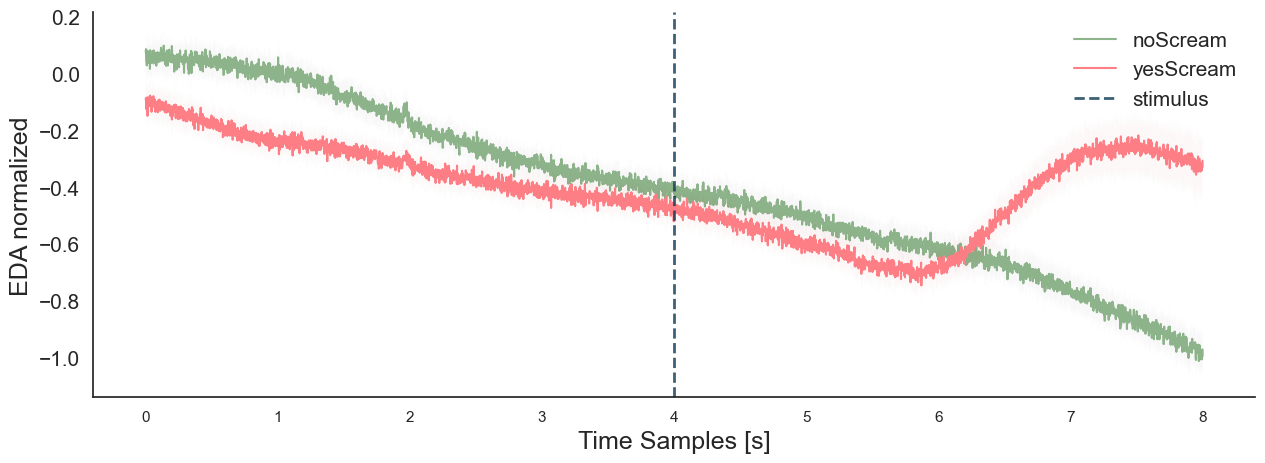

In [88]:
show_raw_signal(dataDicAll['zEDA']['noScreamOnset'],dataDicAll['zEDA']['screamOnset'],4*sampleRate,titleL = 'Skin Conductance / Outcome time',labFrame = ['noScream','yesScream'],yLabel = 'EDA normalized')

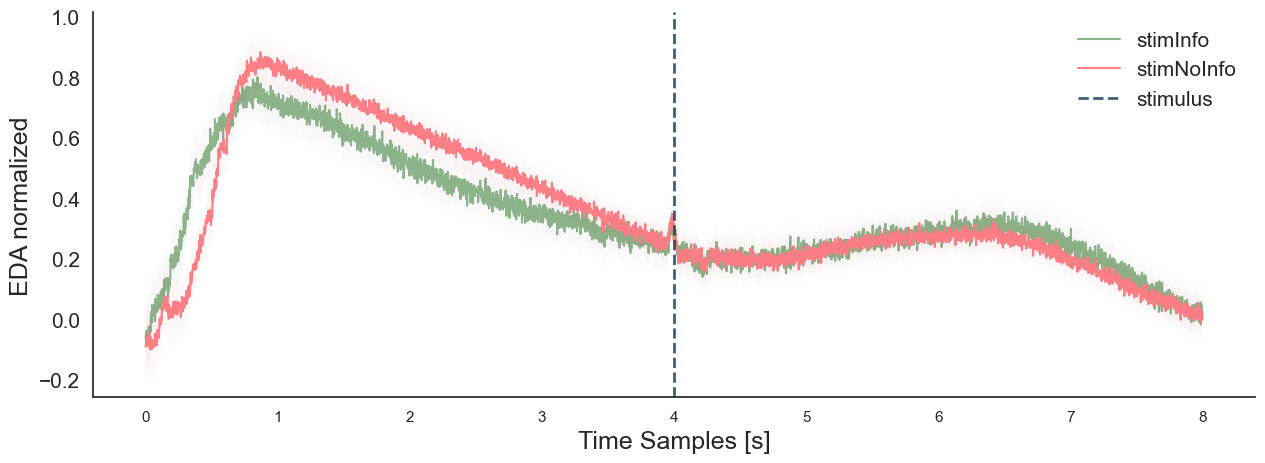

In [89]:
show_raw_signal(dataDicAll['zEDA']['stimNoInfoOnset'],dataDicAll['zEDA']['stimInfoOnset'],4*sampleRate,titleL = 'Skin Conductance / Info Cue time',labFrame = ['stimInfo','stimNoInfo'],yLabel = 'EDA normalized')

In [90]:
dataDF1.PART.unique()

array(['P032', 'P017_1', 'P025', 'P017_2', 'P006', 'P013', 'P007', 'P005',
       'P010', 'P003', 'P016'], dtype=object)

In [91]:
def show_raw_signal_by_part(dataDF1, sampleRate= 500,intervalSelect = 5 , onsets = ['noScreamOnset','screamOnset'],onsetlabel = 'Outcome time',channelSelect = ['EKG','zEDA']):

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(40, 20))

    sample_factor = sampleRate # sampling rate for the dataset
       
    # Load dataframe
    
    iii_pos = 0
    for iii in dataDF1.PART.unique():    
        dataDF_sub = dataDF1.loc[(dataDF1["trials"] < 40)  &  (dataDF1["PART"] == iii)]
        dataDF_sub = dataDF_sub.reset_index()
        for c in channelSelect:
           eLabel = 0
           
           for ev in labelOnsets:
               concatSignal = []
               for ii in dataDF_sub.loc[dataDF_sub[ev] == 1].index.values:
                   
                   aa = dataDF_sub.iloc[ii - (intervalSelect*sampleRate): ii  + (intervalSelect*sampleRate)][c].values
                   if len(aa) ==  intervalSelect*sampleRate*2:
                       concatSignal.append(aa)  
                       
                   elif len(aa)< intervalSelect*sampleRate*2:
                       num = intervalSelect*sampleRate*2-len(aa)
                       concatSignal.append(np.append(aa,[np.nan]*num))
                   else:
                       print("skip trial: "  +  str(ii))
                       
       
               dataDicAll[c][ev] = concatSignal
    
    
    
        pupilBase1 = dataDicAll['zEDA'][onsets[0]]
        pupilBase2 = dataDicAll['zEDA'][onsets[1]]
        event_time = intervalSelect*sampleRate
        titleL = 'Skin Conductance /' + onsetlabel + " : " + " -- Participant :" + str(iii)
        labFrame = [onsets[0],onsets[1]]
        yLabel = 'EDA'


        
        row = iii_pos // 4
        col = iii_pos % 4
        ax = axes[row, col]
        
        iii_pos = iii_pos +1 
        
        #fig = plt.figure()
        
        baseTimeMean1 =np.nanmean(pupilBase1, axis= 0)
        baseTimeStd1 =scipy.stats.sem(pupilBase1, axis= 0,nan_policy='omit')

        # extract data2    
        baseTimeMean2 =np.nanmean(pupilBase2, axis= 0)
        baseTimeStd2 =scipy.stats.sem(pupilBase2, axis= 0,nan_policy='omit')


        #xsecs = range(0,len(instantEffectDDT_like))
        colorP = ['#5BC8AF','#a4ded0','#F9CB40','#fae196','#4F6A9A','#AC5255','#B5C8E9','#F2CECF']
        xSecs = np.array(range(0,len(baseTimeMean1)))

        #plot High
        ax.errorbar(xSecs/sample_factor,baseTimeMean1, yerr= baseTimeStd1, color=colorP[1],marker='', alpha = 0.005 );
        ax.plot(xSecs/sample_factor,baseTimeMean1,color=colorP[0],label = labFrame[0],ls = '-')
        #plot low 
        
        xSecs = np.array(range(0,len(baseTimeMean2)))

        ax.errorbar(xSecs/sample_factor,baseTimeMean2, yerr= baseTimeStd2, color=colorP[3],marker='', alpha = 0.005 );
        ax.plot(xSecs/sample_factor,baseTimeMean2,color=colorP[2],label = labFrame[1],ls = '-')

        ax.axvline(event_time/sample_factor, color='black', lw=2, alpha=0.5,ls = '--')

        ax.set_title(titleL,size=18)
        ax.set_xlabel("Time Samples [s]",size=18)
        ax.set_ylabel("EDA signal",size=18)
        # since we have 500 hz samples (i.e. the distance between each sample is 2ms) we multiple by 2 the interval
        #plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
        #    int(-event_time*2),int(-event_time/2*2) ,0, int(event_time/2*2),int((len(xSecs)-event_time)*2) ],fontsize= 15)


        #plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
        #int(-event_time*sample_factor),int(-event_time/2*sample_factor) ,0, int(event_time/2*sample_factor),int((len(xSecs)-event_time)*sample_factor) ],fontsize= 15)


       # ax.set_yticks()


        ax.legend(frameon=False)
        sns.set_style("white")
        sns.despine()
        #plt.show

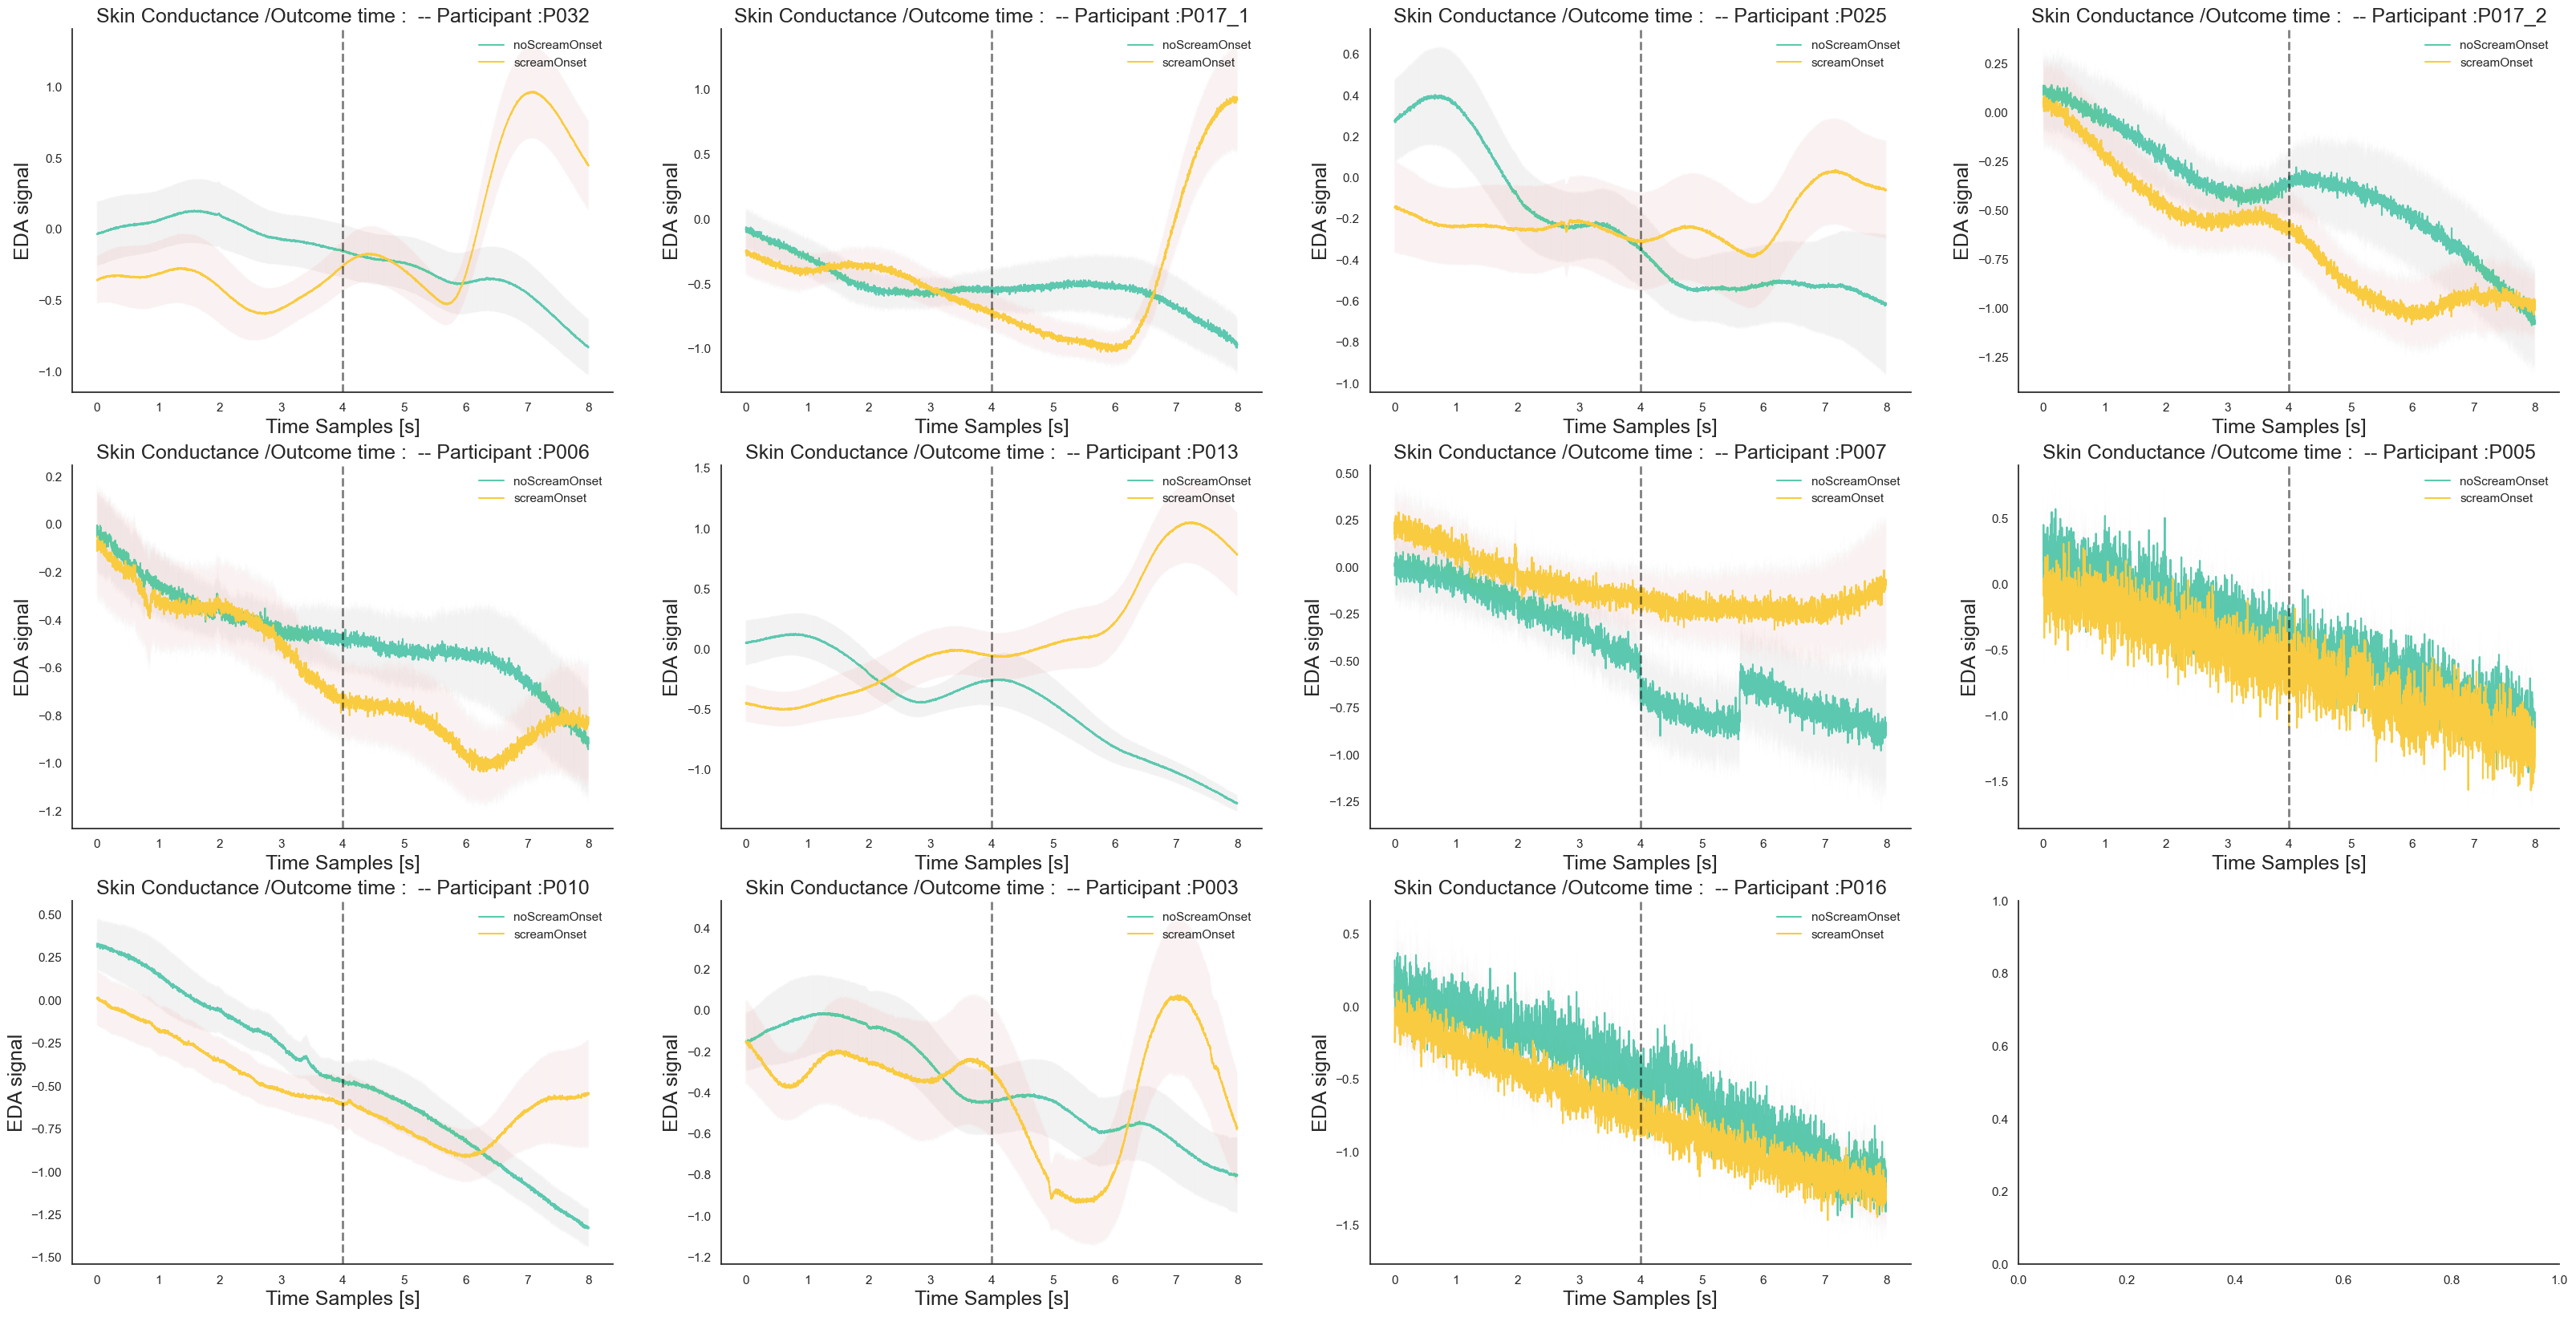

In [92]:
show_raw_signal_by_part(dataDF1,sampleRate= 500,intervalSelect = 4 , onsets = ['noScreamOnset','screamOnset'],  channelSelect = ['EKG','zEDA'])

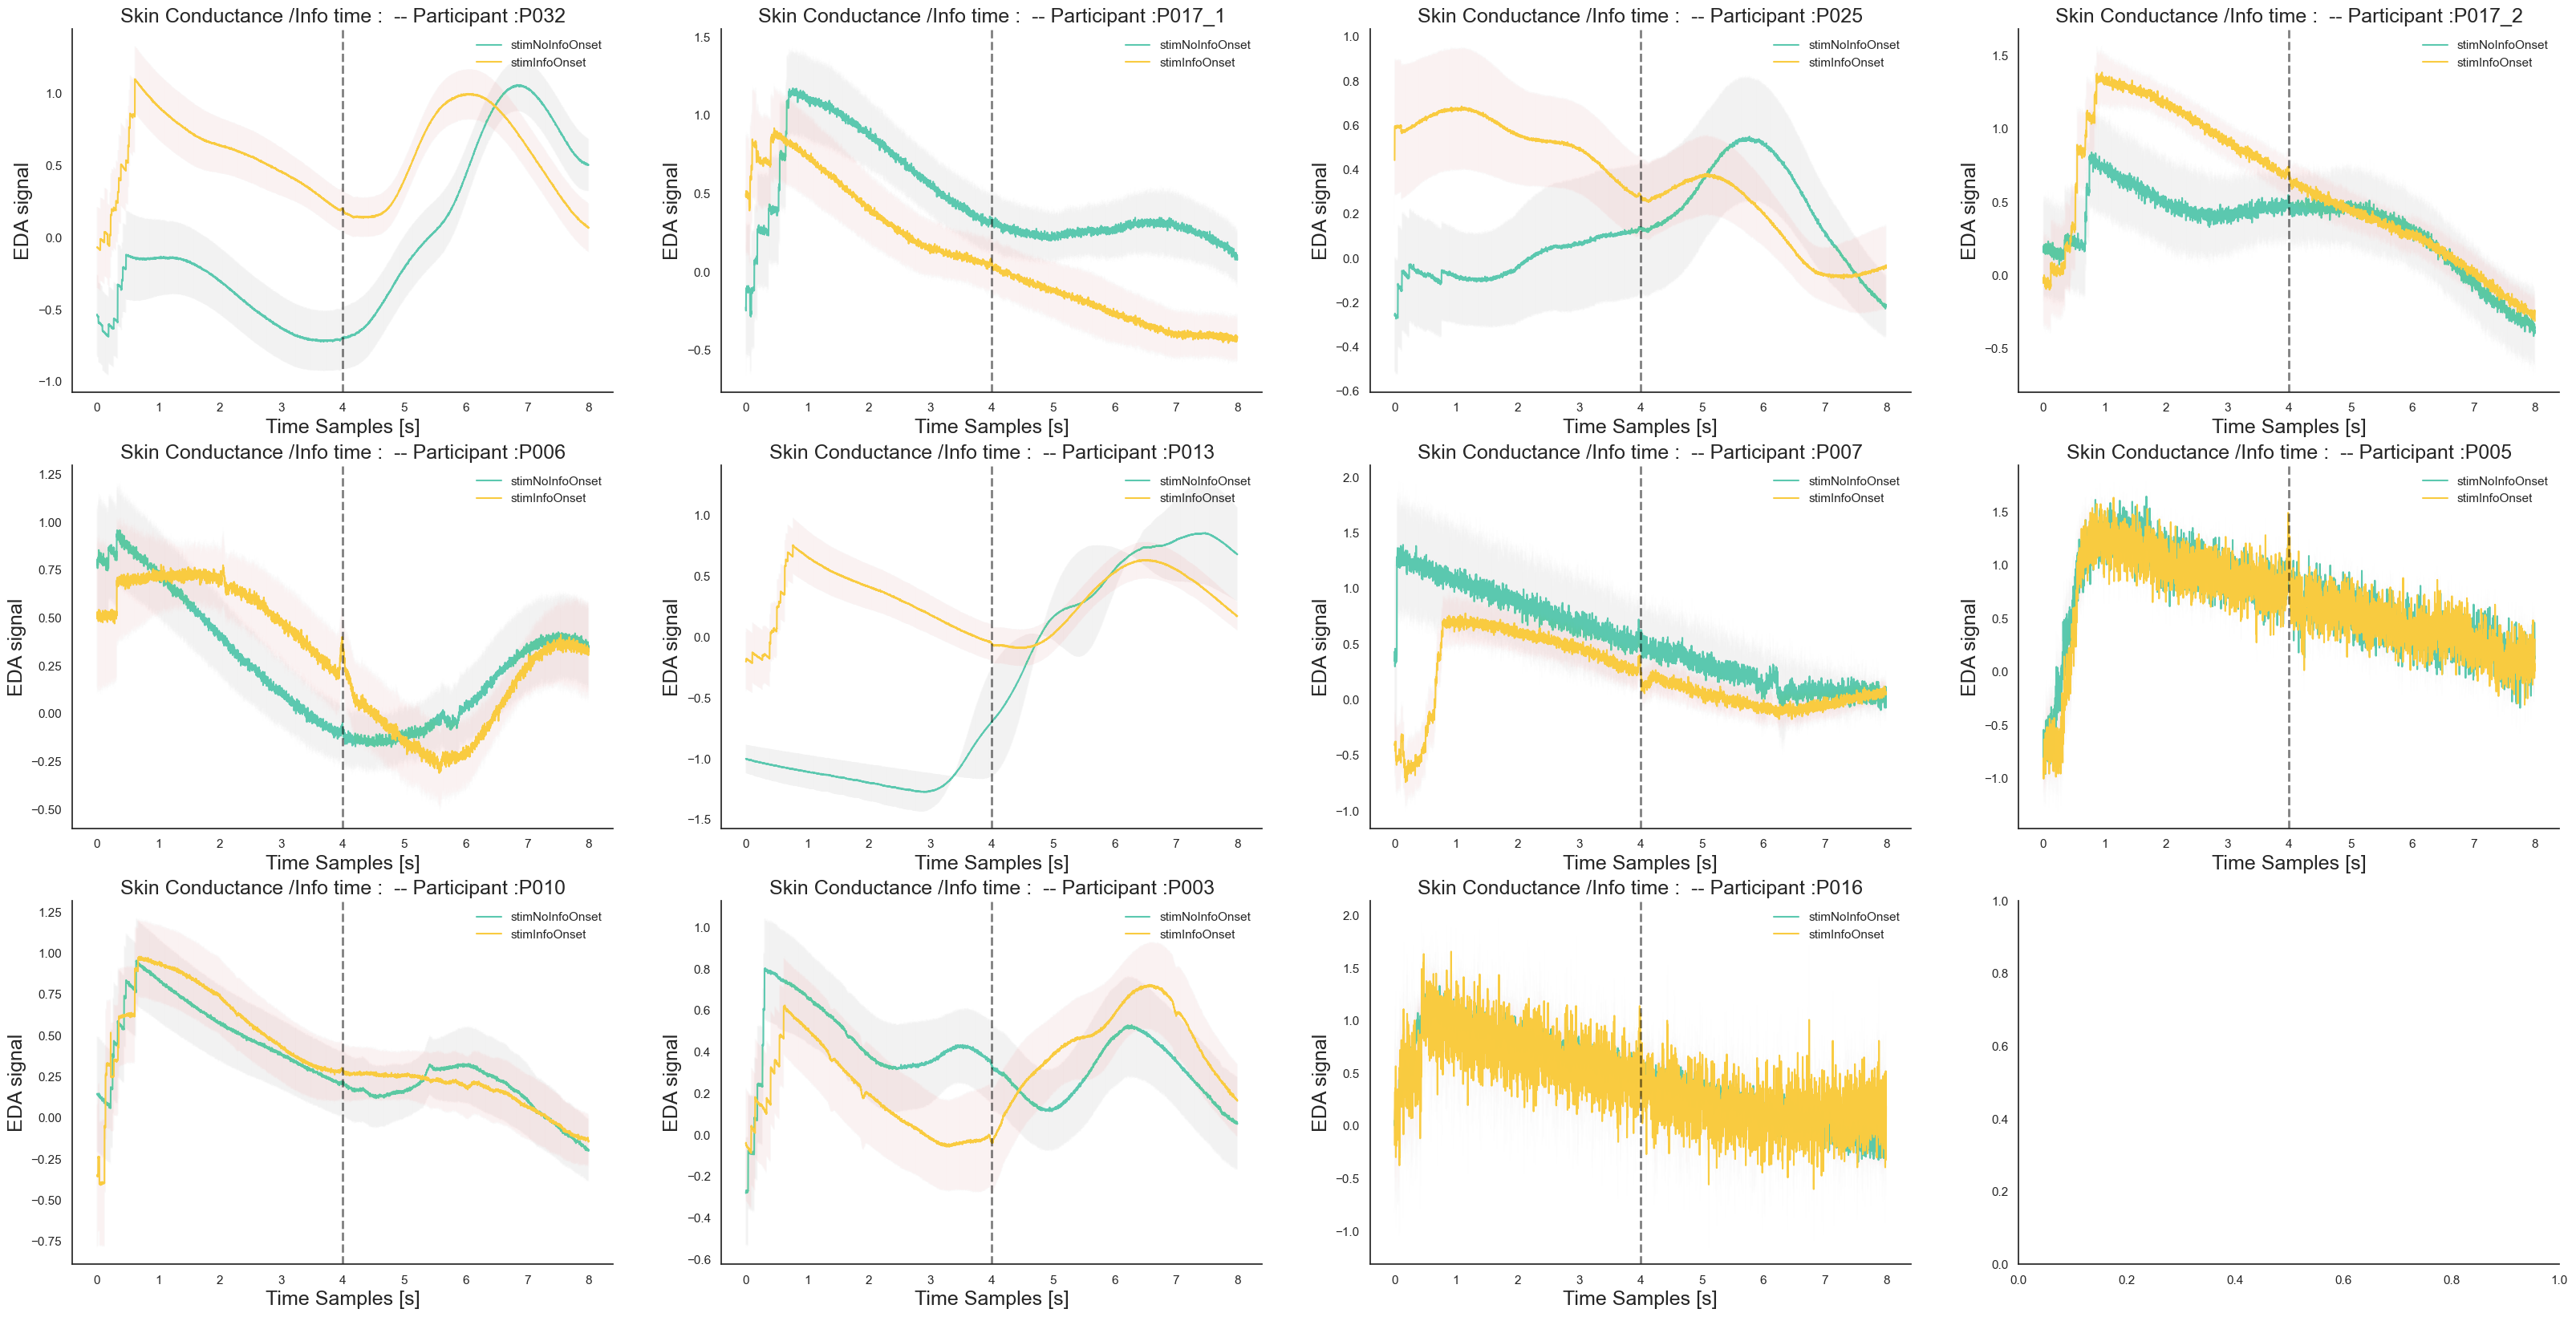

In [93]:
show_raw_signal_by_part(dataDF1,sampleRate= 500,intervalSelect = 4 , onsets = ['stimNoInfoOnset','stimInfoOnset'],onsetlabel = "Info time", channelSelect = ['EKG','zEDA'])

# extract info delays

In [94]:
delaysDF_info  = dataDF1.loc[dataDF1["stimInfo"] == 1]

In [95]:
delaysDF_noInfo  = dataDF1.loc[dataDF1["stimNoInfo"] == 1]

In [96]:
delaysDF_info

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
182928,182928,P032,-0.021362,14.01060,0,0,0,1,0,0,...,365.856,365.856,False,False,False,False,True,False,1,-0.915328
182929,182929,P032,-0.037231,14.01060,0,0,0,1,0,0,...,365.858,365.858,False,False,False,False,False,False,1,-0.915328
182930,182930,P032,-0.037079,14.01060,0,0,0,1,0,0,...,365.860,365.860,False,False,False,False,False,False,1,-0.915328
182931,182931,P032,-0.025787,14.00910,0,0,0,1,0,0,...,365.862,365.862,False,False,False,False,False,False,1,-0.918377
182932,182932,P032,-0.019074,14.01210,0,0,0,1,0,0,...,365.864,365.864,False,False,False,False,False,False,1,-0.912280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13669265,13669265,P016,2.038120,1.64795,0,0,0,1,0,0,...,1919.786,27338.530,False,False,False,False,False,False,63,-1.283023
13669266,13669266,P016,2.537380,1.64795,0,0,0,1,0,0,...,1919.788,27338.532,False,False,False,False,False,False,63,-1.283023
13669267,13669267,P016,3.162840,1.64947,0,0,0,1,0,0,...,1919.790,27338.534,False,False,False,False,False,False,63,-1.000068
13669268,13669268,P016,3.893740,1.64947,0,0,0,1,0,0,...,1919.792,27338.536,False,False,False,False,False,False,63,-1.000068


In [97]:
delaysDF_noInfo.loc[(delaysDF_noInfo.PART == "P016") & (delaysDF_noInfo.trials == 2)]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
12853481,12853481,P016,-0.124207,0.741577,0,0,0,0,1,0,...,288.218,25706.962,False,False,False,False,False,True,2,0.820741
12853482,12853482,P016,-0.099945,0.740051,0,0,0,0,1,0,...,288.220,25706.964,False,False,False,False,False,False,2,0.259478
12853483,12853483,P016,-0.156860,0.741577,0,0,0,0,1,0,...,288.222,25706.966,False,False,False,False,False,False,2,0.820741
12853484,12853484,P016,-0.191040,0.740051,0,0,0,0,1,0,...,288.224,25706.968,False,False,False,False,False,False,2,0.259478
12853485,12853485,P016,-0.164337,0.740051,0,0,0,0,1,0,...,288.226,25706.970,False,False,False,False,False,False,2,0.259478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12855979,12855979,P016,-0.024414,0.741577,0,0,0,0,1,0,...,293.214,25711.958,False,False,False,False,False,False,2,0.820741
12855980,12855980,P016,-0.072784,0.738525,0,0,0,0,1,0,...,293.216,25711.960,False,False,False,False,False,False,2,-0.301785
12855981,12855981,P016,-0.137634,0.738525,0,0,0,0,1,0,...,293.218,25711.962,False,False,False,False,False,False,2,-0.301785
12855982,12855982,P016,-0.166168,0.736999,0,0,0,0,1,0,...,293.220,25711.964,False,False,False,False,False,False,2,-0.863048


In [98]:
sampleRate

500

In [99]:
def extractDelays(delaysDF_info):
    dataDelDic1 = {2: [],5: [], 10: [],20: []}
    delaysKeys = list(dataDelDic1.keys())
    
    for participant in np.unique(delaysDF_info['PART']):
            data = delaysDF_info[delaysDF_info['PART']==participant]
            
    
            for t in data.trials.unique():
                    trialNum = (data[data['trials'] == t])
    
                    delayTrial = int(np.round(trialNum.time.values[-1] - trialNum.time.values[1] ))
                    
                    closestDelay = min(delaysKeys, key=lambda x: abs(x - delayTrial))
                    
                    new = trialNum.zEDA.values[0:sampleRate*closestDelay]
                    
                    if len(new) <  sampleRate*closestDelay:
                        print("praticipant" + str(participant) + "trial" + str(t))
                        num = sampleRate*closestDelay-len(new)
                        new = np.append(new,[np.nan]*num)   
                    

                    
                    dataDelDic1[closestDelay].append(new)
    
    for i in delaysKeys:
        dataDelDic1[i] = np.array(dataDelDic1[i])
    
    
    return dataDelDic1

In [100]:
delaysDF_info

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
182928,182928,P032,-0.021362,14.01060,0,0,0,1,0,0,...,365.856,365.856,False,False,False,False,True,False,1,-0.915328
182929,182929,P032,-0.037231,14.01060,0,0,0,1,0,0,...,365.858,365.858,False,False,False,False,False,False,1,-0.915328
182930,182930,P032,-0.037079,14.01060,0,0,0,1,0,0,...,365.860,365.860,False,False,False,False,False,False,1,-0.915328
182931,182931,P032,-0.025787,14.00910,0,0,0,1,0,0,...,365.862,365.862,False,False,False,False,False,False,1,-0.918377
182932,182932,P032,-0.019074,14.01210,0,0,0,1,0,0,...,365.864,365.864,False,False,False,False,False,False,1,-0.912280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13669265,13669265,P016,2.038120,1.64795,0,0,0,1,0,0,...,1919.786,27338.530,False,False,False,False,False,False,63,-1.283023
13669266,13669266,P016,2.537380,1.64795,0,0,0,1,0,0,...,1919.788,27338.532,False,False,False,False,False,False,63,-1.283023
13669267,13669267,P016,3.162840,1.64947,0,0,0,1,0,0,...,1919.790,27338.534,False,False,False,False,False,False,63,-1.000068
13669268,13669268,P016,3.893740,1.64947,0,0,0,1,0,0,...,1919.792,27338.536,False,False,False,False,False,False,63,-1.000068


In [101]:
clean_delaysDF_info = delaysDF_info.copy()
clean_delaysDF_info = clean_delaysDF_info[(clean_delaysDF_info['PART'] != 'P005') & (clean_delaysDF_info['PART'] != 'P007') & (clean_delaysDF_info['PART'] != 'P016')]
clean_delaysDF_noInfo = delaysDF_noInfo.copy()
clean_delaysDF_noInfo = clean_delaysDF_noInfo[(clean_delaysDF_noInfo['PART'] != 'P005') & (clean_delaysDF_noInfo['PART'] != 'P007') & (clean_delaysDF_noInfo['PART'] != 'P016')]


clean_delInfo = extractDelays(delaysDF_info)
clean_delNoInfo = extractDelays(clean_delaysDF_noInfo)

praticipantP007trial26
praticipantP010trial128
praticipantP032trial119
praticipantP032trial119


In [102]:
delInfo = extractDelays(clean_delaysDF_info)
delNoInfo = extractDelays(delaysDF_noInfo)

praticipantP010trial128
praticipantP032trial119
praticipantP032trial119


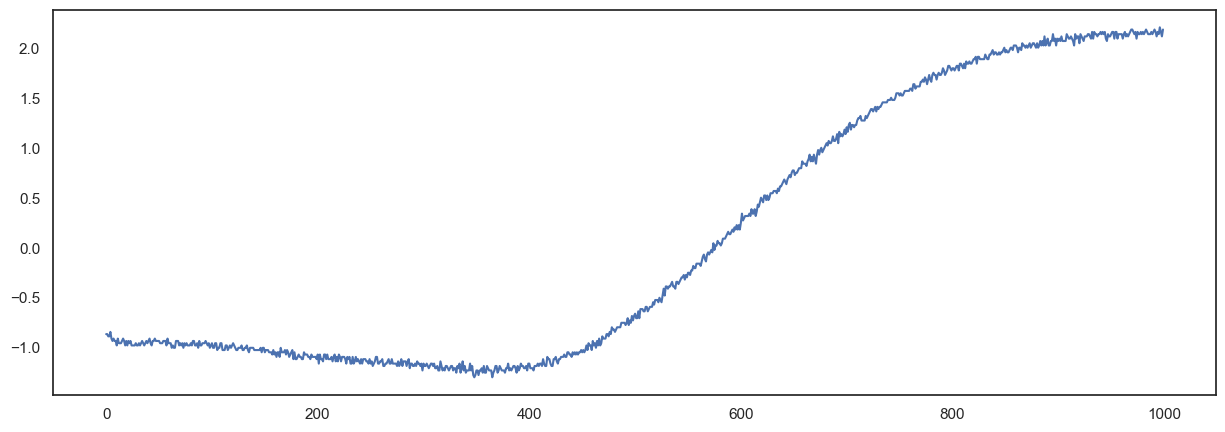

In [103]:
plt.plot(delInfo[2][2])

In [561]:
def figDelays(delInfo,delNoInfo,delayNum,labels = ["info","noInfo"]):
    
    fig, axs = plt.subplots(figsize=(8, 7))
    
    array2show = delInfo[delayNum]
    colorP = "#8DB38B"  
    a = np.nanmean(array2show ,axis=0)
    sem_a = scipy.stats.sem(array2show, axis= 0,nan_policy='omit')
    x_ax = [ x/500 for x in list(range(len(a)))]
    
    plt.errorbar(x_ax,a, yerr= sem_a, color=colorP,marker='', alpha = 0.05 );
    plt.plot(x_ax,a, label = 'scream',color=colorP)
    
    
    array2show = delNoInfo[delayNum]
    colorP = "#FD7E84"
    
    a = np.nanmean(array2show ,axis=0)
    sem_a = scipy.stats.sem(array2show, axis= 0,nan_policy='omit')
    x_ax = [ x/500 for x in list(range(len(a)))]
    
    plt.errorbar(x_ax,a, yerr= sem_a, color=colorP,marker='', alpha = 0.05 );
    plt.plot(x_ax,a, label ='no scream',color=colorP)
    
    sns.set_style('white')
    
    xtick_locations = np.linspace(0, delayNum, 5)

    
    plt.xlabel("Time (s)", size = 25)
    plt.ylabel("Normalized skin conductance", size = 25)
    plt.title(str(delayNum) + " second delay",size = 25)
    plt.xticks(xtick_locations,fontsize=25)
    plt.yticks(fontsize=25)
    
    plt.legend(fontsize=25)
    sns.despine()


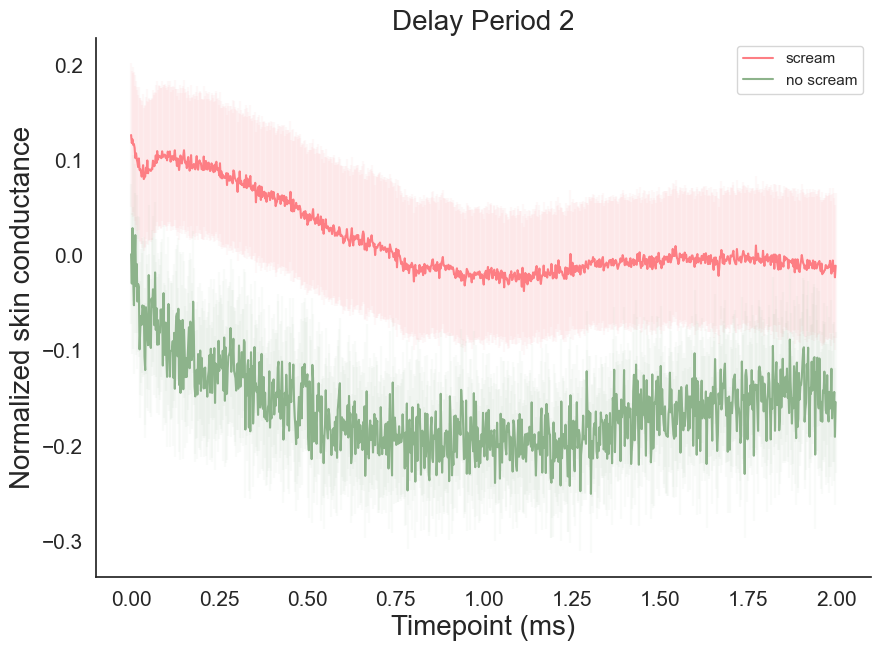

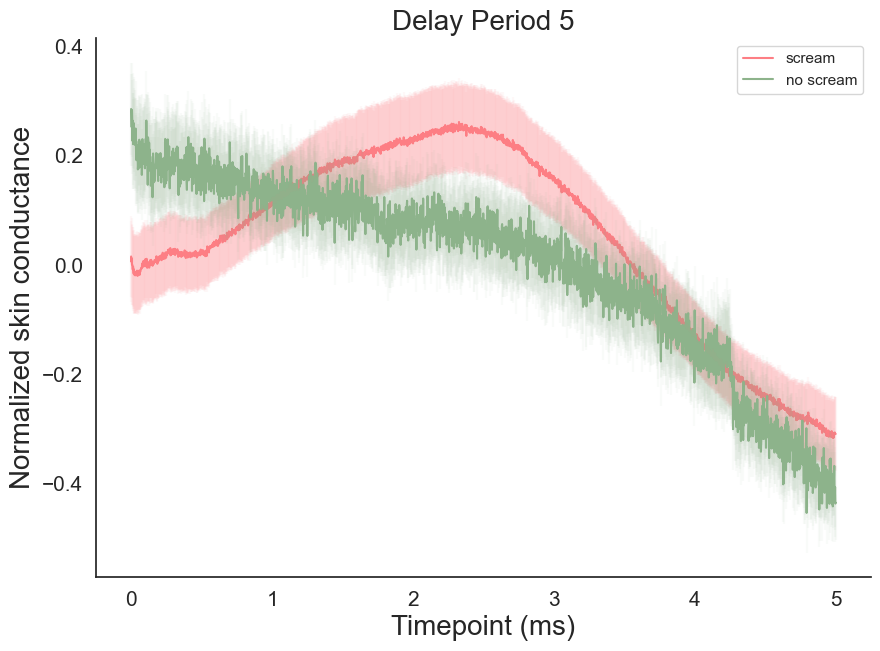

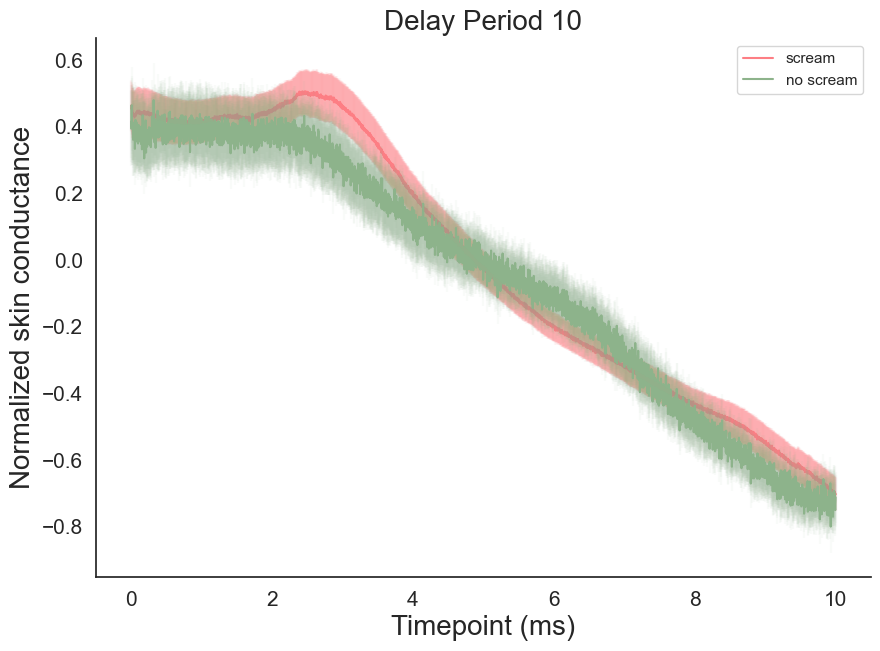

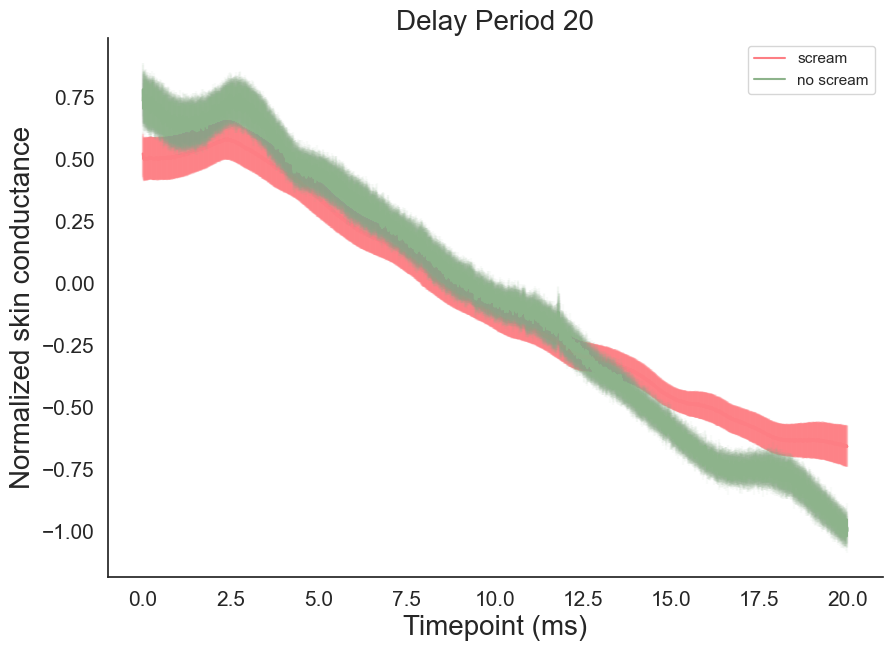

In [105]:
figDelays(delInfo,delNoInfo,2,["info","noInfo"])
figDelays(delInfo,delNoInfo,5,["info","noInfo"])
figDelays(delInfo,delNoInfo,10,["info","noInfo"])
figDelays(delInfo,delNoInfo,20,["info","noInfo"])


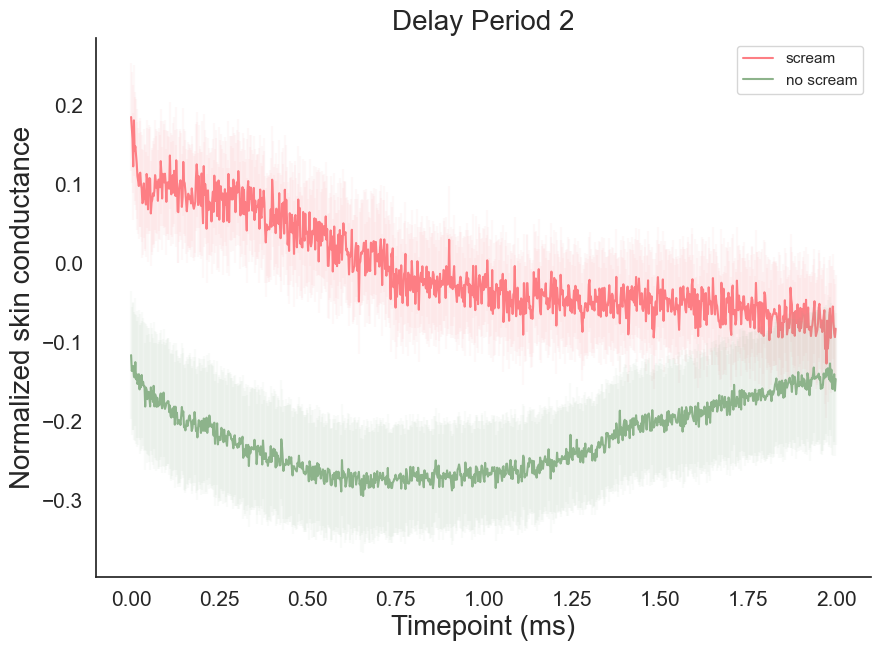

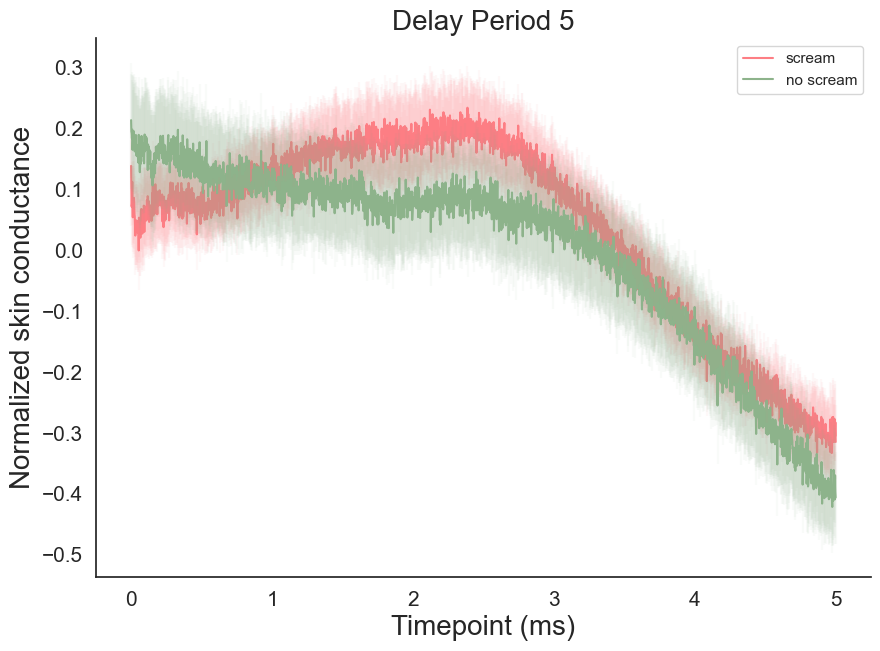

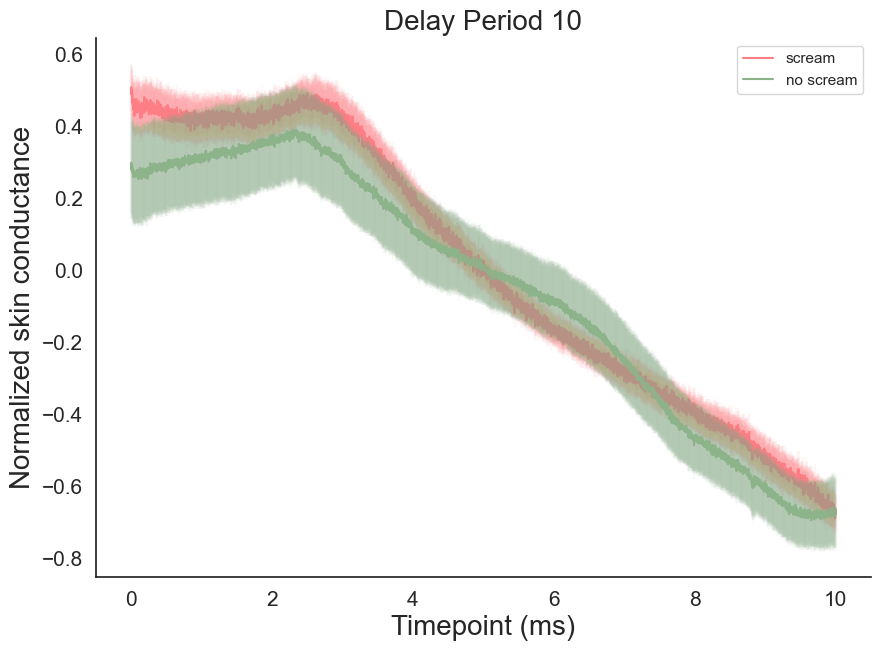

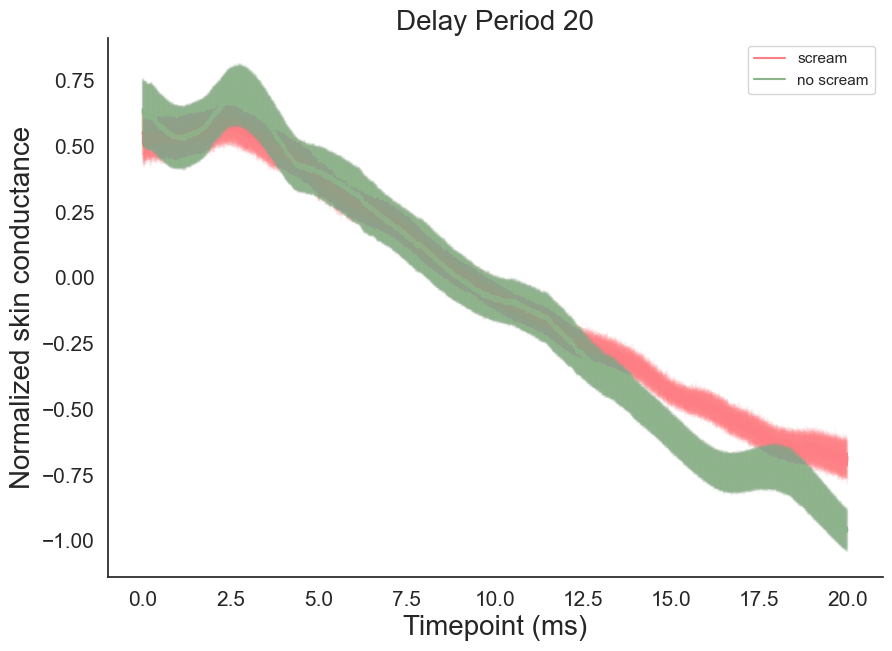

In [106]:
figDelays(clean_delInfo,clean_delNoInfo,2,["info","noInfo"])
figDelays(clean_delInfo,clean_delNoInfo,5,["info","noInfo"])
figDelays(clean_delInfo,clean_delNoInfo,10,["info","noInfo"])
figDelays(clean_delInfo,clean_delNoInfo,20,["info","noInfo"])

In [107]:
def extractDelaysByOutcome(dataDF1,screamCond):
    
    
    dataDelDic1 = {2: [],5: [], 10: [],20: []}
    dataDelDic2 = {2: [],5: [], 10: [],20: []}

    delaysKeys = list(dataDelDic1.keys())
    
    dataDicAll = {"info": dataDelDic1 ,"noInfo": dataDelDic2 }


    
    for participant in np.unique(dataDF1['PART']):
            data = dataDF1.loc[dataDF1['PART']==participant]
            
    
            for t in data.trials.unique():
                    trialNum0 = data.loc[data['trials'] == t]
                 
                    if not np.sum(trialNum0[screamCond]) == 0 :
                        #print("hello")
                        continue # continue to next trial if the condition is not available
                
                    new = []
                
                    # FOR INFO
                    if np.sum(trialNum0["stimInfo"]) > 0 :
                        
                        trialNum = trialNum0.loc[trialNum0["stimInfo"] == 1]
        
                        delayTrial = int(np.round(trialNum.time.values[-1] - trialNum.time.values[1] ))
                        
                        closestDelay = min(delaysKeys, key=lambda x: abs(x - delayTrial))
                        
                        new = trialNum.zEDA.values[0:sampleRate*closestDelay]
                        
                        if len(new) <  sampleRate*closestDelay:
                            print("praticipant" + str(participant) + "trial" + str(t))
                            num = sampleRate*closestDelay-len(new)
                            new = np.append(new,[np.nan]*num)   
    
                        dataDicAll["info"][closestDelay].append(new)
                    
                    # FOR NO INFO
                    #
                    else:
                       if np.sum(trialNum0["stimNoInfo"]) > 0 : 
                        trialNum = trialNum0.loc[trialNum0["stimNoInfo"] == 1 ]
        
                        delayTrial = int(np.round(trialNum.time.values[-1] - trialNum.time.values[1] ))
                        
                        closestDelay = min(delaysKeys, key=lambda x: abs(x - delayTrial))
                        
                        new = trialNum.zEDA.values[0:sampleRate*closestDelay]
                        
                        if len(new) <  sampleRate*closestDelay:
                            print("praticipant" + str(participant) + "trial" + str(t))
                            num = sampleRate*closestDelay-len(new)
                            new = np.append(new,[np.nan]*num)   
    
                        dataDicAll["noInfo"][closestDelay].append(new)
    
    #for j in ["info", "noInfo"]:
    #    for i in delaysKeys:
     #       dataDicAll[j][i] = np.array(dataDicAll[j][i])
    
    
    return dataDicAll

In [108]:
data = dataDF1.loc[dataDF1['PART']=="P032"]


In [109]:
data

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
0,0,P032,-0.276947,0.003051,0,0,0,0,0,0,...,0.000,0.000,False,False,False,False,False,False,0,-1.321684
1,1,P032,-0.497742,-0.003052,0,0,0,0,0,0,...,0.002,0.002,False,False,False,False,False,False,0,-1.322616
2,2,P032,-0.469971,0.001526,0,0,0,0,0,0,...,0.004,0.004,False,False,False,False,False,False,0,-1.321917
3,3,P032,-0.184784,0.001526,0,0,0,0,0,0,...,0.006,0.006,False,False,False,False,False,False,0,-1.321917
4,4,P032,0.225220,0.003051,0,0,0,0,0,0,...,0.008,0.008,False,False,False,False,False,False,0,-1.321684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1798332,1798332,P032,0.119324,4.747010,0,0,0,0,0,0,...,3596.664,3596.664,False,False,False,False,False,False,129,-0.343848
1798333,1798333,P032,0.395355,4.750060,0,0,0,0,0,0,...,3596.666,3596.666,False,False,False,False,False,False,129,-0.237356
1798334,1798334,P032,0.596619,4.750060,0,0,0,0,0,0,...,3596.668,3596.668,False,False,False,False,False,False,129,-0.237356
1798335,1798335,P032,0.510559,4.748530,0,0,0,0,0,0,...,3596.670,3596.670,False,False,False,False,False,False,129,-0.290777


In [110]:
trialNum0 = data.loc[data['trials'] == 2]
trialNum0

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
187704,187704,P032,0.002441,14.2075,0,1,0,0,0,0,...,375.408,375.408,True,False,False,False,False,False,2,-0.616935
187705,187705,P032,-0.006409,14.2090,0,1,0,0,0,0,...,375.410,375.410,False,False,False,False,False,False,2,-0.614482
187706,187706,P032,-0.009003,14.2075,0,1,0,0,0,0,...,375.412,375.412,False,False,False,False,False,False,2,-0.616935
187707,187707,P032,-0.009613,14.2044,0,1,0,0,0,0,...,375.414,375.414,False,False,False,False,False,False,2,-0.622004
187708,187708,P032,-0.018616,14.2090,0,1,0,0,0,0,...,375.416,375.416,False,False,False,False,False,False,2,-0.614482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193057,193057,P032,-0.270081,14.8376,0,0,0,0,0,0,...,386.114,386.114,False,False,False,False,False,False,2,0.413410
193058,193058,P032,-0.264130,14.8376,0,0,0,0,0,0,...,386.116,386.116,False,False,False,False,False,False,2,0.413410
193059,193059,P032,-0.239716,14.8376,0,0,0,0,0,0,...,386.118,386.118,False,False,False,False,False,False,2,0.413410
193060,193060,P032,-0.223541,14.8346,0,0,0,0,0,0,...,386.120,386.120,False,False,False,False,False,False,2,0.408505


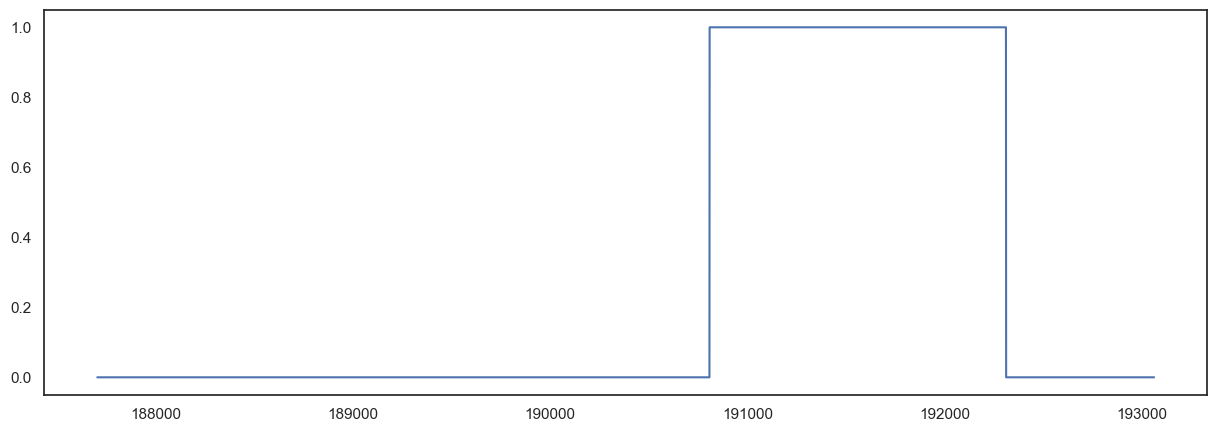

In [111]:
plt.plot(trialNum0.scream)

In [112]:
trialNum = trialNum0.loc[trialNum0["stimInfo"] == 1]
trialNum

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA


In [113]:
np.sum(trialNum0.noScream.values)

0

In [114]:
dataDF1

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
0,0,P032,-0.276947,0.003051,0,0,0,0,0,0,...,0.000,0.000,False,False,False,False,False,False,0,-1.321684
1,1,P032,-0.497742,-0.003052,0,0,0,0,0,0,...,0.002,0.002,False,False,False,False,False,False,0,-1.322616
2,2,P032,-0.469971,0.001526,0,0,0,0,0,0,...,0.004,0.004,False,False,False,False,False,False,0,-1.321917
3,3,P032,-0.184784,0.001526,0,0,0,0,0,0,...,0.006,0.006,False,False,False,False,False,False,0,-1.321917
4,4,P032,0.225220,0.003051,0,0,0,0,0,0,...,0.008,0.008,False,False,False,False,False,False,0,-1.321684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13669946,13669946,P016,-0.244598,1.646420,0,0,0,0,0,1,...,1921.148,27339.892,False,False,False,False,False,False,63,-1.567840
13669947,13669947,P016,-0.242615,1.646420,0,0,0,0,0,1,...,1921.150,27339.894,False,False,False,False,False,False,63,-1.567840
13669948,13669948,P016,-0.218506,1.646420,0,0,0,0,0,1,...,1921.152,27339.896,False,False,False,False,False,False,63,-1.567840
13669949,13669949,P016,-0.195007,1.643370,0,0,0,0,0,1,...,1921.154,27339.898,False,False,False,False,False,False,63,-2.135612


In [115]:
np.sum(dataDF1.loc[(dataDF1.PART == "P016") & (dataDF1.trials == 2)]["stimNoInfo"])

2503

In [116]:
np.sum(dataDF1.scream)

676150

In [117]:
delScream = extractDelaysByOutcome(dataDF1,"scream")
delNoScream = extractDelaysByOutcome(dataDF1,"noScream")

praticipantP007trial26
praticipantP010trial128
praticipantP010trial128
praticipantP032trial119


In [118]:
clean_delScream = extractDelaysByOutcome(clean_dataDF1,"scream")
clean_delNoScream = extractDelaysByOutcome(clean_dataDF1,"noScream")

praticipantP010trial128
praticipantP010trial128
praticipantP032trial119


In [119]:
len(delScream["info"][2])

80

In [120]:
len(delScream["noInfo"][2])

51

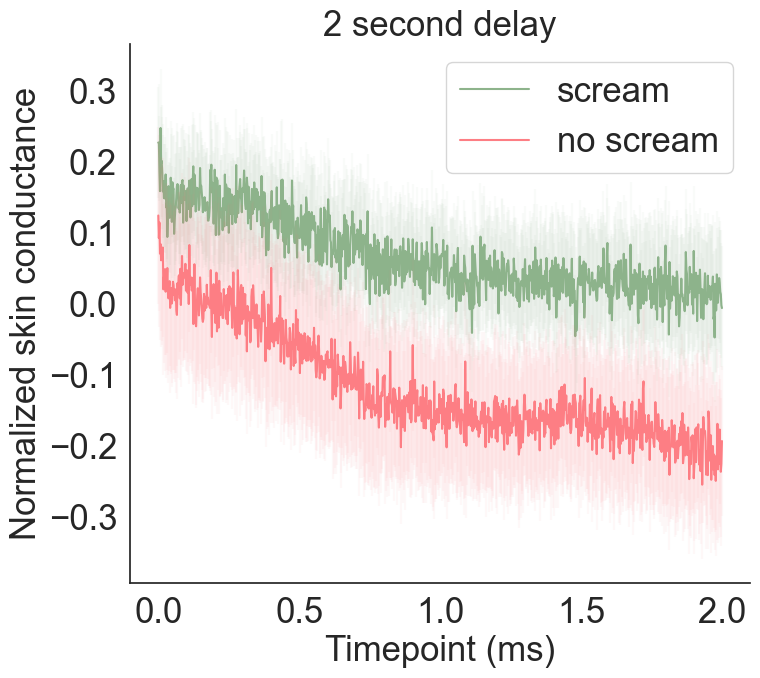

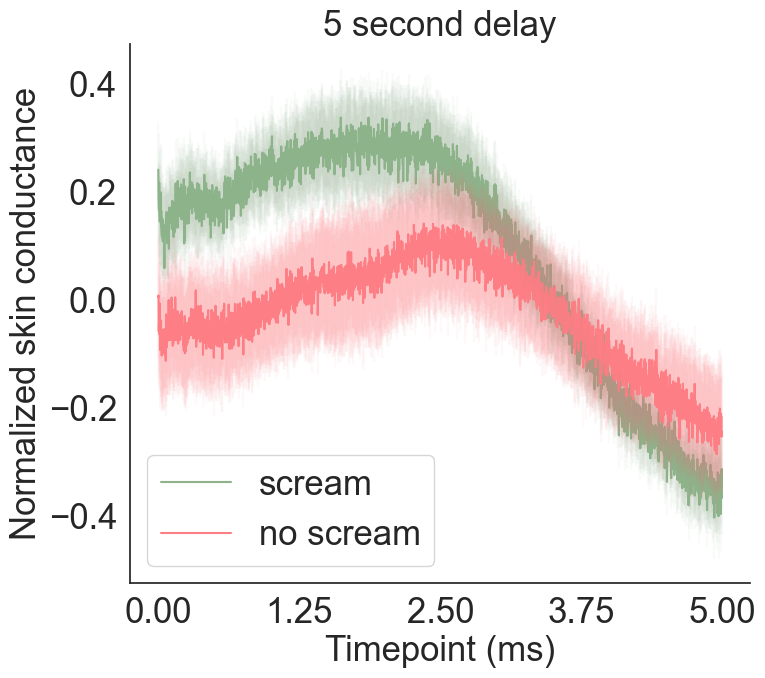

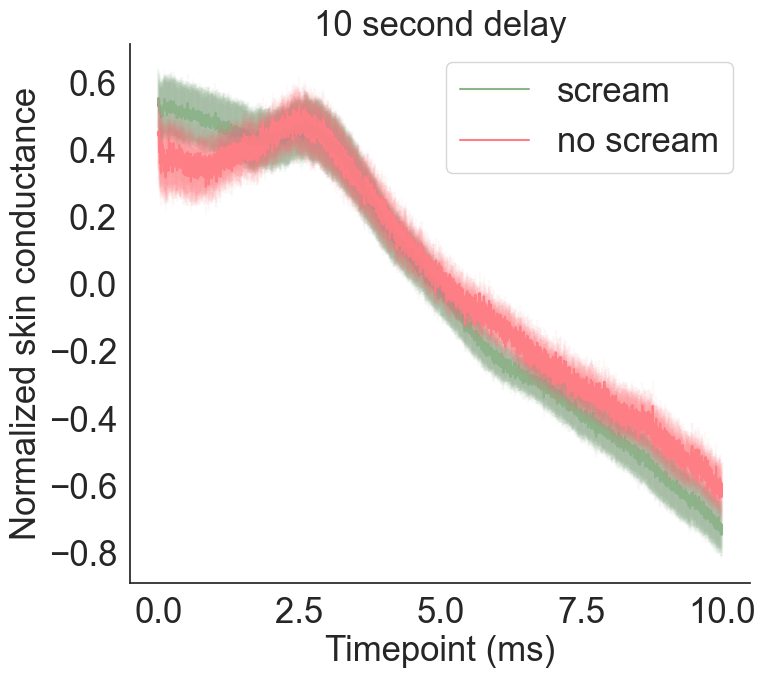

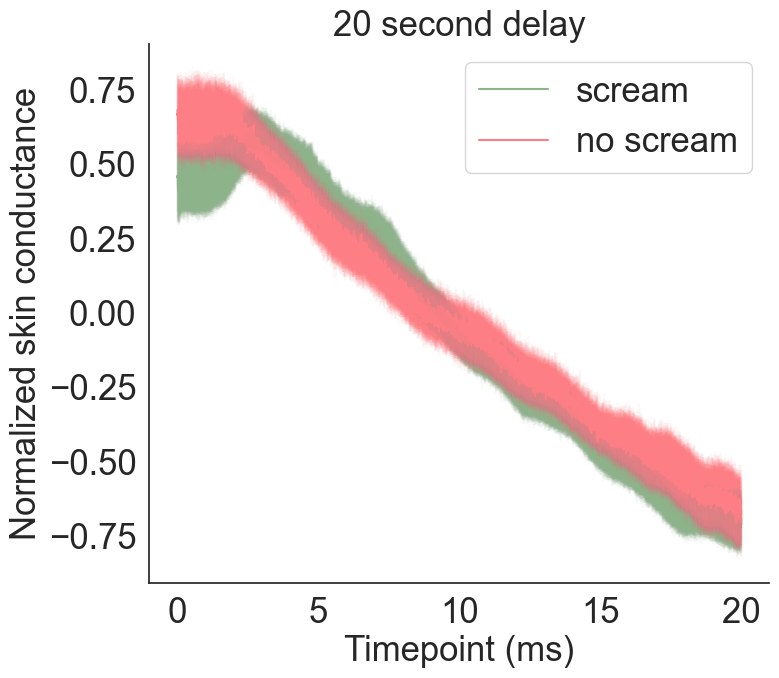

In [495]:
figDelays(delScream["info"],delNoScream["info"],2,["scream","noScream"])
figDelays(delScream["info"],delNoScream["info"],5,["scream","noScream"])
figDelays(delScream["info"],delNoScream["info"],10,["scream","noScream"])
figDelays(delScream["info"],delNoScream["info"],20,["scream","noScream"])

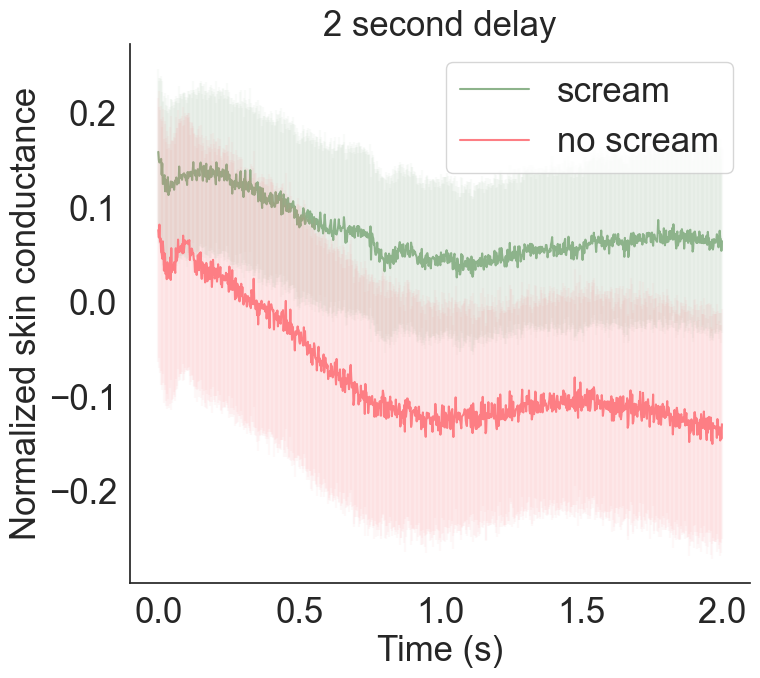

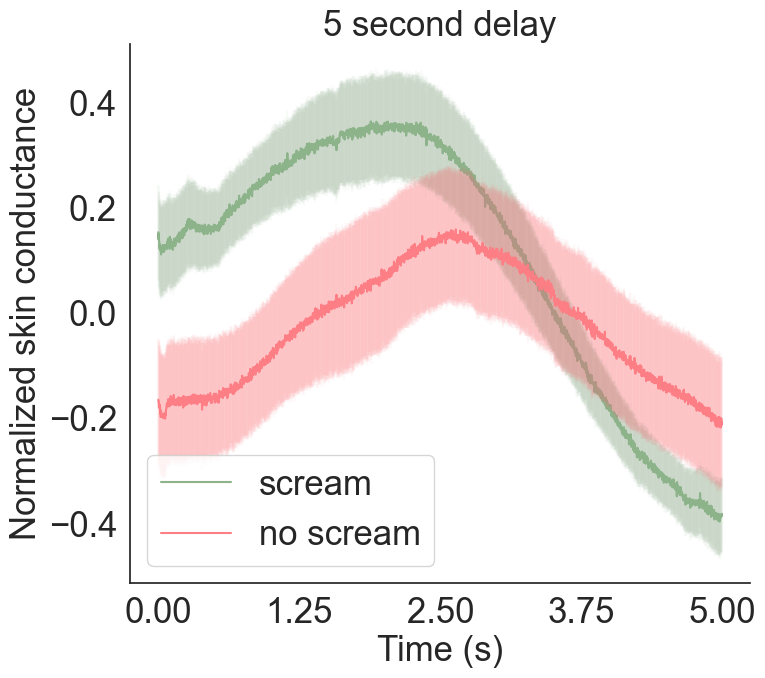

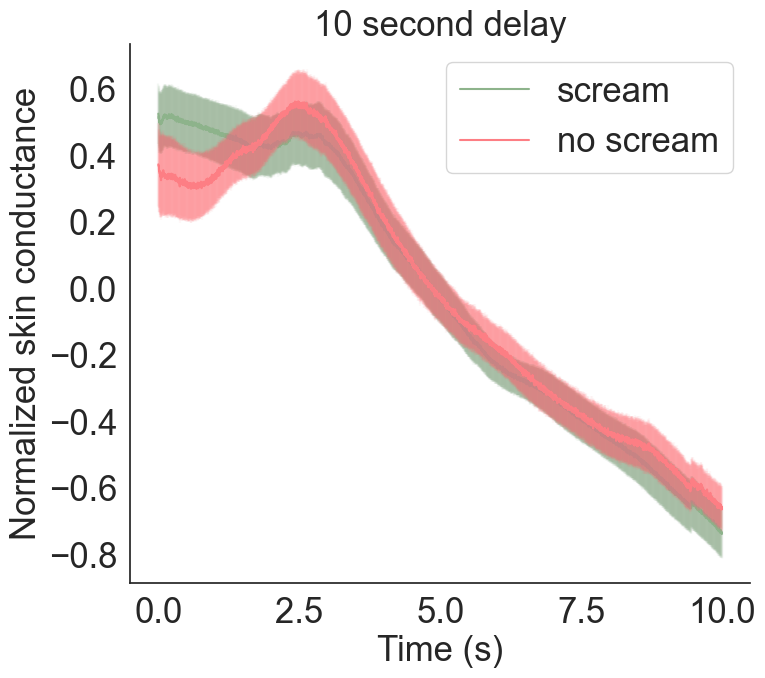

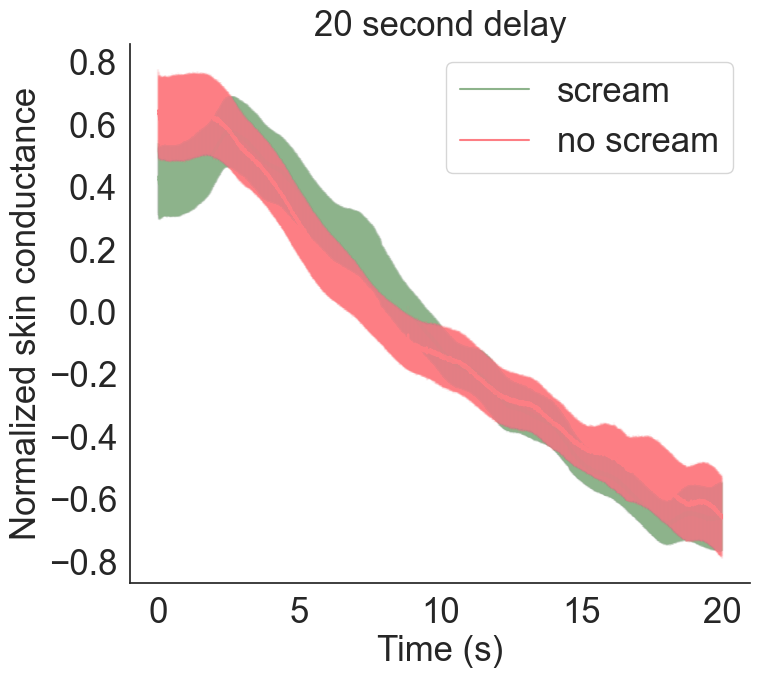

In [562]:
figDelays(clean_delScream["info"],clean_delNoScream["info"],2,["scream","noScream"])
plt.savefig("EDA_info_scream_vs_noScream_delays_2.png",bbox_inches='tight')
figDelays(clean_delScream["info"],clean_delNoScream["info"],5,["scream","noScream"])
plt.savefig("EDA_info_scream_vs_noScream_delays_5.png",bbox_inches='tight')
figDelays(clean_delScream["info"],clean_delNoScream["info"],10,["scream","noScream"])
plt.savefig("EDA_info_scream_vs_noScream_delays_10.png",bbox_inches='tight')
figDelays(clean_delScream["info"],clean_delNoScream["info"],20,["scream","noScream"])
plt.savefig("EDA_info_scream_vs_noScream_delays_20.png",bbox_inches='tight')

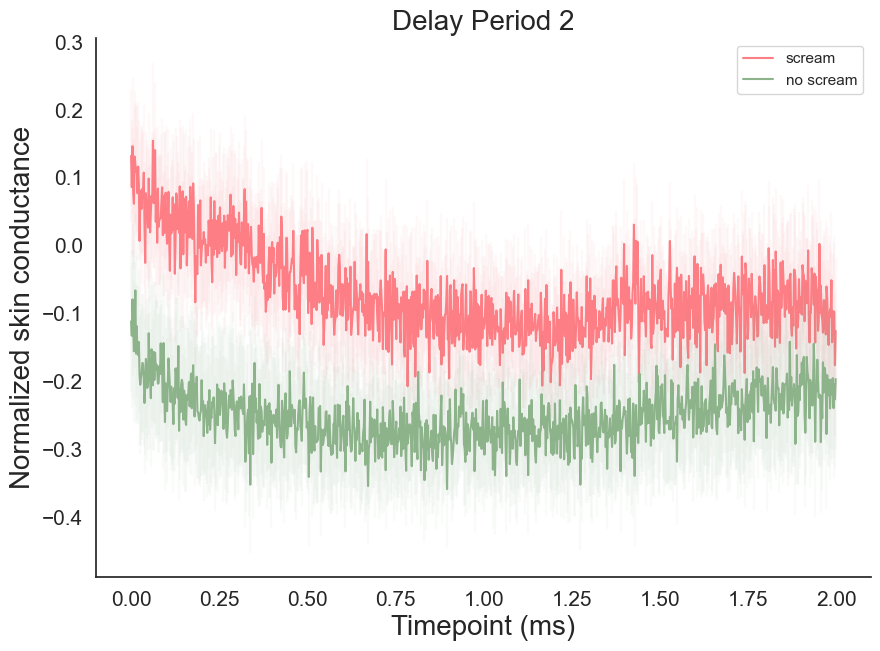

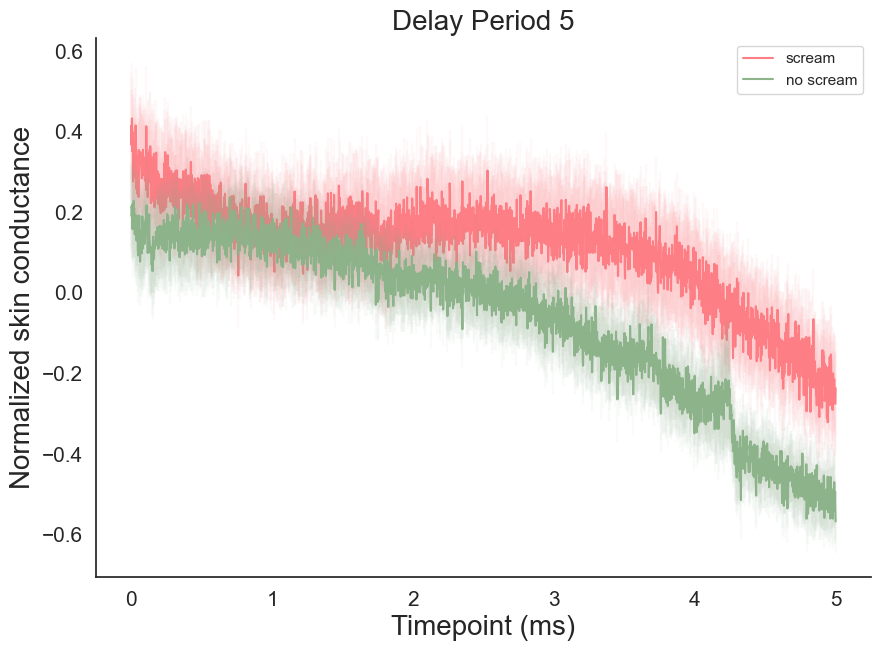

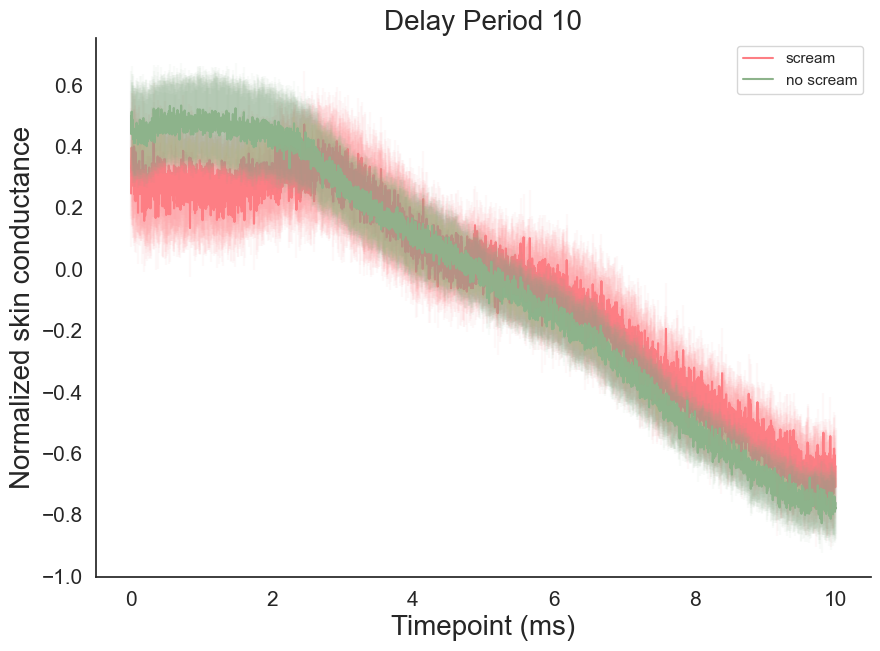

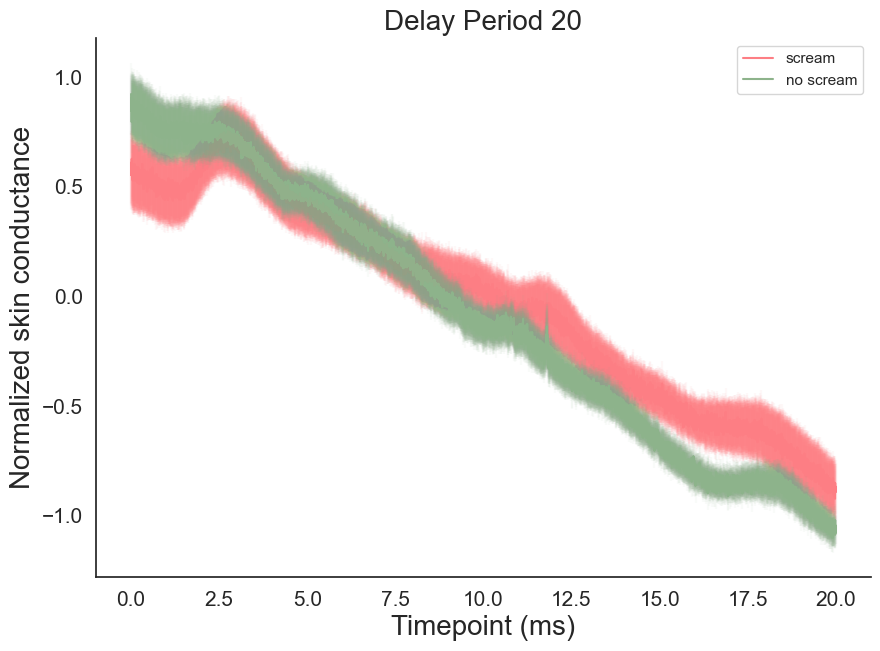

In [123]:
figDelays(delScream["noInfo"],delNoScream["noInfo"],2,["scream","noScream"])
figDelays(delScream["noInfo"],delNoScream["noInfo"],5,["scream","noScream"])
figDelays(delScream["noInfo"],delNoScream["noInfo"],10,["scream","noScream"])
figDelays(delScream["noInfo"],delNoScream["noInfo"],20,["scream","noScream"])

In [124]:
dataDF1["PART"].unique()

array(['P032', 'P017_1', 'P025', 'P017_2', 'P006', 'P013', 'P007', 'P005',
       'P010', 'P003', 'P016'], dtype=object)

In [125]:
dataDF1.loc[dataDF1["PART"] == "P007"]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
7255712,7255712,P007,0.105743,6.492610,0,0,0,0,0,0,...,0.0005,14511.424,False,False,False,False,False,False,0,1.286738
7255713,7255713,P007,0.085144,6.491090,0,0,0,0,0,0,...,0.0025,14511.426,False,False,False,False,False,False,0,1.285604
7255714,7255714,P007,0.087128,6.495670,0,0,0,0,0,0,...,0.0045,14511.428,False,False,False,False,False,False,0,1.289019
7255715,7255715,P007,0.121307,6.494140,0,0,0,0,0,0,...,0.0065,14511.430,False,False,False,False,False,False,0,1.287878
7255716,7255716,P007,0.131836,6.495670,0,0,0,0,0,0,...,0.0085,14511.432,False,False,False,False,False,False,0,1.289019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8665569,8665569,P007,0.765839,0.003051,0,0,0,0,0,0,...,2819.7145,17331.138,False,False,False,False,False,False,65,-0.818759
8665570,8665570,P007,-0.070190,0.003051,0,0,0,0,0,0,...,2819.7165,17331.140,False,False,False,False,False,False,65,-0.818759
8665571,8665571,P007,-0.844116,0.001526,0,0,0,0,0,0,...,2819.7185,17331.142,False,False,False,False,False,False,65,-0.820704
8665572,8665572,P007,-1.411440,0.004577,0,0,0,0,0,0,...,2819.7205,17331.144,False,False,False,False,False,False,65,-0.816813


In [126]:
dataDF1.loc[(dataDF1["PART"] == "P007") & (dataDF1["startBlock"] ==1) &  (dataDF1["trials"] ==0)]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
7537213,7537213,P007,0.162048,3.34015,1,0,0,0,0,0,...,563.0025,15074.426,False,False,False,False,False,False,0,-1.064069
7537214,7537214,P007,0.156708,3.33710,1,0,0,0,0,0,...,563.0045,15074.428,False,False,False,False,False,False,0,-1.066344
7537215,7537215,P007,0.142670,3.33862,1,0,0,0,0,0,...,563.0065,15074.430,False,False,False,False,False,False,0,-1.065210
7537216,7537216,P007,0.130310,3.33710,1,0,0,0,0,0,...,563.0085,15074.432,False,False,False,False,False,False,0,-1.066344
7537217,7537217,P007,0.115814,3.33710,1,0,0,0,0,0,...,563.0105,15074.434,False,False,False,False,False,False,0,-1.066344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7539707,7539707,P007,0.313416,3.44849,1,0,0,0,0,0,...,567.9905,15079.414,False,False,False,False,False,False,0,-0.983280
7539708,7539708,P007,0.287170,3.45001,1,0,0,0,0,0,...,567.9925,15079.416,False,False,False,False,False,False,0,-0.982146
7539709,7539709,P007,0.316772,3.45001,1,0,0,0,0,0,...,567.9945,15079.418,False,False,False,False,False,False,0,-0.982146
7539710,7539710,P007,0.381775,3.45001,1,0,0,0,0,0,...,567.9965,15079.420,False,False,False,False,False,False,0,-0.982146


In [127]:
dataDF1.columns

Index(['Unnamed: 0', 'PART', 'EKG', 'EDA', 'startBlock', 'startTrial',
       'infoChoice', 'stimInfo', 'stimNoInfo', 'scream', 'noScream',
       'endTrial', 'timePart', 'time', 'startTrialOnset', 'screamOnset',
       'noScreamOnset', 'infoChoiceOnset', 'stimInfoOnset', 'stimNoInfoOnset',
       'trials', 'zEDA'],
      dtype='object')

In [128]:
dataDF1

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
0,0,P032,-0.276947,0.003051,0,0,0,0,0,0,...,0.000,0.000,False,False,False,False,False,False,0,-1.321684
1,1,P032,-0.497742,-0.003052,0,0,0,0,0,0,...,0.002,0.002,False,False,False,False,False,False,0,-1.322616
2,2,P032,-0.469971,0.001526,0,0,0,0,0,0,...,0.004,0.004,False,False,False,False,False,False,0,-1.321917
3,3,P032,-0.184784,0.001526,0,0,0,0,0,0,...,0.006,0.006,False,False,False,False,False,False,0,-1.321917
4,4,P032,0.225220,0.003051,0,0,0,0,0,0,...,0.008,0.008,False,False,False,False,False,False,0,-1.321684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13669946,13669946,P016,-0.244598,1.646420,0,0,0,0,0,1,...,1921.148,27339.892,False,False,False,False,False,False,63,-1.567840
13669947,13669947,P016,-0.242615,1.646420,0,0,0,0,0,1,...,1921.150,27339.894,False,False,False,False,False,False,63,-1.567840
13669948,13669948,P016,-0.218506,1.646420,0,0,0,0,0,1,...,1921.152,27339.896,False,False,False,False,False,False,63,-1.567840
13669949,13669949,P016,-0.195007,1.643370,0,0,0,0,0,1,...,1921.154,27339.898,False,False,False,False,False,False,63,-2.135612


# EKG measurement

In [129]:
sampleRate = 500

In [130]:
import pathlib
from ecgdetectors import Detectors
import sys

fs = sampleRate
detectors = Detectors(sampleRate)

In [131]:
dataDicAll['EKG']['screamOnset'][:3]

[array([ 0.0404358,  0.124817 ,  0.193481 , ..., -0.154419 , -0.148621 ,
        -0.189972 ]),
 array([-0.220795 , -0.164642 , -0.0994873, ...,  2.56744  ,  3.08228  ,
         3.68195  ]),
 array([-0.218048 , -0.188446 , -0.267639 , ..., -0.138245 , -0.0906372,
        -0.0526428])]

In [132]:
def prePostIBI(signalEKG,sampleRate =500):
    # extract cardiac IBI, before and after the event (scream/no scream) for all the trials
    preIBI = []
    postIBI = []
    for i in range(len(signalEKG)):
        #print('trial ' + str(i))
        r_peaks = detectors.two_average_detector(signalEKG[i])
        
        # separate the half prior to event from after event
        c = np.where(np.array(r_peaks)<=len(signalEKG[i])/2) 
        rPeaksPre = [r_peaks[i] for i in c[0]]
        c = np.where(np.array(r_peaks)>len(signalEKG[i])/2) 
        rPeaksPost = [r_peaks[i] for i in c[0]]
        
        #preIBI.append(substractSeq(rPeaksPre))
        #postIBI.append(substractSeq(rPeaksPost))
        
        preIBI.append(np.mean(substractSeq(rPeaksPre)[1]))
        postIBI.append(np.mean(substractSeq(rPeaksPost)[1]))
        
    return(preIBI,postIBI)

def substractSeq(a): # calculate time between events (time estimated in sample term)
    b = []
    b_secs = []
    for i, n in enumerate(a):
        if i < (len(a) - 1):
            b.append(  a[i+1] - a[i]  )
            b_secs.append(  (a[i+1] - a[i])/sampleRate)

    return (b,b_secs)


In [133]:
labelOnsets = ["startTrialOnset","screamOnset",'noScreamOnset','infoChoiceOnset','stimInfoOnset','stimNoInfoOnset']

dataDic1 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}
dataDic2 = {labelOnsets[0]: [],labelOnsets[1]: [],labelOnsets[2]: [],labelOnsets[3]: [],labelOnsets[4]: [],labelOnsets[5]: []}

channelSelect = ['EKG','zEDA']

dataDicAll = {channelSelect[0]: dataDic1 ,channelSelect[1]: dataDic2 }

intervalSelect = 4 # interval in seconds to consider for EKG (CH1) and EDA (CH2) data

dataDF_sub = dataDF1#.loc[dataDF1["trials"] < 40].reset_index(drop = True)



for c in channelSelect:
    eLabel = 0
    
    for ev in labelOnsets:
        concatSignal = []
        for ii in dataDF_sub.loc[dataDF_sub[ev] == 1].index.values:
            
            aa = dataDF_sub.iloc[ii - (intervalSelect*sampleRate): ii  + (intervalSelect*sampleRate)][c].values
            if len(aa) ==  intervalSelect*sampleRate*2:
                concatSignal.append(aa)  
                
            elif len(aa)< intervalSelect*sampleRate*2:
                num = intervalSelect*sampleRate*2-len(aa)
                concatSignal.append(np.append(aa,[np.nan]*num))
            else:
                print("skip trial: "  +  str(ii))
                

        dataDicAll[c][ev] = concatSignal
        print(ev)

startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset
startTrialOnset
screamOnset
noScreamOnset
infoChoiceOnset
stimInfoOnset
stimNoInfoOnset


In [134]:
dataDF_sub.loc[dataDF_sub[ev] == 1].index.values

array([  189801,   195051,   223874,   306642,   331716,   370379,
         410426,   420509,   427067,   459039,   464114,   559715,
         574472,   581579,   616594,   652350,   673398,   678505,
         694179,   713719,   780138,   840450,   899038,   904254,
        1097647,  1122095,  1182524,  1225995,  1394732,  1401957,
        1531972,  1546146,  1552096,  1639347,  1649821,  1683710,
        1692039,  1786000,  2027968,  2040776,  2060399,  2067649,
        2229978,  2235511,  2265659,  2274858,  2285150,  2299084,
        2305525,  2319846,  2329179,  2343453,  2420414,  2434646,
        2478129,  2487144,  2496166,  2501191,  2515240,  2521990,
        2527064,  2541454,  2555423,  2569627,  2576377,  2585370,
        2590826,  2661096,  2675761,  2681070,  2697429,  2711467,
        2720925,  2727360,  2732234,  2741142,  2746314,  2751331,
        2757791,  2974380,  2980896,  3006939,  3021543,  3045625,
        3069481,  3091654,  3121852,  3190622,  3196238,  3203

In [135]:
import rapidhrv as rhv #rapidRHV

#### extract EKG by delay time

In [136]:
dataDF1.loc[(dataDF1['PART']=='P007')&(dataDF1['trials']==7)&(dataDF1['stimInfo']==1)]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,timePart,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA
7905474,7905474,P007,0.176697,4.55780,0,0,0,1,0,0,...,1299.5245,15810.948,False,False,False,False,True,False,7,-1.890355
7905475,7905475,P007,0.181274,4.55475,0,0,0,1,0,0,...,1299.5265,15810.950,False,False,False,False,False,False,7,-1.956447
7905476,7905476,P007,0.171661,4.55475,0,0,0,1,0,0,...,1299.5285,15810.952,False,False,False,False,False,False,7,-1.956447
7905477,7905477,P007,0.138855,4.55475,0,0,0,1,0,0,...,1299.5305,15810.954,False,False,False,False,False,False,7,-1.956447
7905478,7905478,P007,0.103455,4.55627,0,0,0,1,0,0,...,1299.5325,15810.956,False,False,False,False,False,False,7,-1.923509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7915485,7915485,P007,0.303650,4.67834,0,0,0,1,0,0,...,1319.5465,15830.970,False,False,False,False,False,False,7,0.721667
7915486,7915486,P007,0.299377,4.67682,0,0,0,1,0,0,...,1319.5485,15830.972,False,False,False,False,False,False,7,0.688730
7915487,7915487,P007,0.306091,4.67834,0,0,0,1,0,0,...,1319.5505,15830.974,False,False,False,False,False,False,7,0.721667
7915488,7915488,P007,0.279999,4.67529,0,0,0,1,0,0,...,1319.5525,15830.976,False,False,False,False,False,False,7,0.655576


In [137]:
# add delay time as an extra column --> dataDelay0

labelOnsets = ["startTrial","scream",'noScream','infoChoice','stimInfo','stimNoInfo','startBlock']


for i in labelOnsets:
    dataDF1[i + "Onset"] = np.logical_xor(dataDF1.shift(periods = 1)[i].values, dataDF1[i].values) & (dataDF1.shift(periods = 2)[i].values == 0)

dataDelay = dataDF1.copy()#.loc[(dataDF1['stimInfo'] == 1) | (dataDF1['stimNoInfo'] == 1)]
dataDelDic1 = {2: [], 5: [], 10: [], 20: []}
delaysKeys = list(dataDelDic1.keys())
data0 = pd.DataFrame()
dataDelay0 = pd.DataFrame()
delayTrial = NaN

for participant in np.unique(dataDelay['PART']):
    data = dataDelay[dataDelay['PART'] == participant]
    data0 = pd.DataFrame()

    for t in data.trials.unique():
        trialNum = data[data['trials'] == t]
        if (trialNum['stimInfo'] == 1).any():
            delayTrial = int(np.round(trialNum.loc[trialNum['stimInfo'] == 1, 'time'].values[-1] - trialNum.loc[trialNum['stimInfo'] == 1, 'time'].values[1]))
        elif (trialNum['stimNoInfo'] == 1).any():
            delayTrial = int(np.round(trialNum.loc[trialNum['stimNoInfo'] == 1, 'time'].values[-1] - trialNum.loc[trialNum['stimNoInfo'] == 1, 'time'].values[1]))
        closestDelay = min(delaysKeys, key=lambda x: abs(x - delayTrial))
        trialNum0 = trialNum.copy()
        trialNum0['delays']=np.NaN
        mask = trialNum0['trials']==t
        trialNum0.loc[mask,'delays']=closestDelay
        data0 = pd.concat([data0,trialNum0])
    dataDelay0 = pd.concat([dataDelay0,data0])  

In [138]:
dataDF1

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,time,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset
0,0,P032,-0.276947,0.003051,0,0,0,0,0,0,...,0.000,False,False,False,False,False,False,0,-1.321684,False
1,1,P032,-0.497742,-0.003052,0,0,0,0,0,0,...,0.002,False,False,False,False,False,False,0,-1.322616,False
2,2,P032,-0.469971,0.001526,0,0,0,0,0,0,...,0.004,False,False,False,False,False,False,0,-1.321917,False
3,3,P032,-0.184784,0.001526,0,0,0,0,0,0,...,0.006,False,False,False,False,False,False,0,-1.321917,False
4,4,P032,0.225220,0.003051,0,0,0,0,0,0,...,0.008,False,False,False,False,False,False,0,-1.321684,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13669946,13669946,P016,-0.244598,1.646420,0,0,0,0,0,1,...,27339.892,False,False,False,False,False,False,63,-1.567840,False
13669947,13669947,P016,-0.242615,1.646420,0,0,0,0,0,1,...,27339.894,False,False,False,False,False,False,63,-1.567840,False
13669948,13669948,P016,-0.218506,1.646420,0,0,0,0,0,1,...,27339.896,False,False,False,False,False,False,63,-1.567840,False
13669949,13669949,P016,-0.195007,1.643370,0,0,0,0,0,1,...,27339.898,False,False,False,False,False,False,63,-2.135612,False


In [139]:
dataDelay0.loc[(dataDelay0['PART']=='P007')&(dataDelay0['trials']==7)&(dataDelay0['stimInfo']==1)]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays
7905474,7905474,P007,0.176697,4.55780,0,0,0,1,0,0,...,False,False,False,False,True,False,7,-1.890355,False,20.0
7905475,7905475,P007,0.181274,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,False,7,-1.956447,False,20.0
7905476,7905476,P007,0.171661,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,False,7,-1.956447,False,20.0
7905477,7905477,P007,0.138855,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,False,7,-1.956447,False,20.0
7905478,7905478,P007,0.103455,4.55627,0,0,0,1,0,0,...,False,False,False,False,False,False,7,-1.923509,False,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7915485,7915485,P007,0.303650,4.67834,0,0,0,1,0,0,...,False,False,False,False,False,False,7,0.721667,False,20.0
7915486,7915486,P007,0.299377,4.67682,0,0,0,1,0,0,...,False,False,False,False,False,False,7,0.688730,False,20.0
7915487,7915487,P007,0.306091,4.67834,0,0,0,1,0,0,...,False,False,False,False,False,False,7,0.721667,False,20.0
7915488,7915488,P007,0.279999,4.67529,0,0,0,1,0,0,...,False,False,False,False,False,False,7,0.655576,False,20.0


In [140]:
dataDelay0[dataDelay0['startTrial']==1]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays
11296620,11296620,P003,0.221558,6.39648,0,1,0,0,0,0,...,True,False,False,False,False,False,1,-1.389551,False,5.0
11296621,11296621,P003,0.194244,6.39801,0,1,0,0,0,0,...,False,False,False,False,False,False,1,-1.388123,False,5.0
11296622,11296622,P003,0.174713,6.39343,0,1,0,0,0,0,...,False,False,False,False,False,False,1,-1.392399,False,5.0
11296623,11296623,P003,0.144348,6.39496,0,1,0,0,0,0,...,False,False,False,False,False,False,1,-1.390971,False,5.0
11296624,11296624,P003,0.094757,6.39343,0,1,0,0,0,0,...,False,False,False,False,False,False,1,-1.392399,False,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785339,1785339,P032,-0.132751,4.80957,0,1,0,0,0,0,...,False,False,False,False,False,False,129,1.840458,False,5.0
1785340,1785340,P032,-0.117188,4.80804,0,1,0,0,0,0,...,False,False,False,False,False,False,129,1.787038,False,5.0
1785341,1785341,P032,-0.128632,4.80957,0,1,0,0,0,0,...,False,False,False,False,False,False,129,1.840458,False,5.0
1785342,1785342,P032,-0.144043,4.80804,0,1,0,0,0,0,...,False,False,False,False,False,False,129,1.787038,False,5.0


In [141]:
#dataDelay1 contains data only during delay time
dataDelay1 = dataDelay0.loc[(dataDelay0['stimInfo'] == 1) | (dataDelay0['stimNoInfo'] == 1)]

#dataBaseline contains data only during startTrial
dataBaseline = dataDelay0.loc[(dataDelay0['startTrial'] == 1)]

In [142]:
dataDelay0['delays'].unique()

array([ 2.,  5., 20., 10.])

In [143]:
#extract only 20 sec delay trials for now
delay20 = dataDelay1[dataDelay1['delays']==20]
delay20

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays
11428996,11428996,P003,-0.080109,16.29790,0,0,0,1,0,0,...,False,False,False,False,True,False,11,-0.470858,False,20.0
11428997,11428997,P003,-0.087738,16.29790,0,0,0,1,0,0,...,False,False,False,False,False,False,11,-0.470858,False,20.0
11428998,11428998,P003,-0.099945,16.29330,0,0,0,1,0,0,...,False,False,False,False,False,False,11,-0.488096,False,20.0
11428999,11428999,P003,-0.088501,16.29640,0,0,0,1,0,0,...,False,False,False,False,False,False,11,-0.476479,False,20.0
11429000,11429000,P003,-0.087128,16.29640,0,0,0,1,0,0,...,False,False,False,False,False,False,11,-0.476479,False,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1781817,1781817,P032,-0.148926,4.86908,0,0,0,1,0,0,...,False,False,False,False,False,False,128,-0.572479,False,20.0
1781818,1781818,P032,-0.147705,4.87061,0,0,0,1,0,0,...,False,False,False,False,False,False,128,-0.538824,False,20.0
1781819,1781819,P032,-0.156097,4.86755,0,0,0,1,0,0,...,False,False,False,False,False,False,128,-0.606134,False,20.0
1781820,1781820,P032,-0.161591,4.87061,0,0,0,1,0,0,...,False,False,False,False,False,False,128,-0.538824,False,20.0


In [144]:
delay20[delay20['scream']==1]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,startTrialOnset,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays


In [145]:
len(delay20[(delay20['PART']=='P007')&(delay20['trials']==7)])

10016

In [146]:
#function to preprocess data, input @param dataset needs to be preprocessed, 
#returns a dataset with preprocessed data as an extra column
#dataPart['pEKG'] = np.NaN
def preprocess(delaydata):
    delayProcessed = pd.DataFrame()
    for participant in np.unique(delaydata['PART']):
        dataPart = delaydata.loc[delaydata['PART']==participant].copy()
        my_data = dataPart.EKG.values # Load data
        data = rhv.Signal(my_data, sample_rate=500)  # Convert to rhv Signal class
        preprocessed = rhv.preprocess(data)  # Preprocess: may interpolate data, check the docstring on `rapidhrv.preprocess`
        #result = rhv.analyze(preprocessed,outlier_detection_settings = 'liberal', ecg_prt_clustering = True)  # Analyze signal
        preprocessed2 = preprocessed.data[::2]
        dataPart['pEKG'] = preprocessed2
        delayProcessed = pd.concat([delayProcessed,dataPart])
    return delayProcessed
'''
signal = rhv.get_example_data()
preprocessed = rhv.preprocess(signal)
analyzed = rhv.analyze(preprocessed)
rhv.visualize(analyzed)
'''

'\nsignal = rhv.get_example_data()\npreprocessed = rhv.preprocess(signal)\nanalyzed = rhv.analyze(preprocessed)\nrhv.visualize(analyzed)\n'

In [147]:
delay20Processed = preprocess(delay20)

In [148]:
delay20Processed.loc[(delay20Processed['PART']=='P007')].trials.unique()

array([ 2,  7, 10, 14, 17, 18, 27, 32, 38, 45, 46, 49, 50, 57, 64])

In [149]:
test = delay20Processed.loc[(delay20Processed['PART']=='P007')&(delay20Processed['trials']==7),['time','pEKG']]

In [150]:
delay20Processed.loc[(delay20Processed['PART']=='P007')&(delay20Processed['trials']==7)]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays,pEKG
7905474,7905474,P007,0.176697,4.55780,0,0,0,1,0,0,...,False,False,False,True,False,7,-1.890355,False,20.0,0.238263
7905475,7905475,P007,0.181274,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,7,-1.956447,False,20.0,0.221817
7905476,7905476,P007,0.171661,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,7,-1.956447,False,20.0,0.204803
7905477,7905477,P007,0.138855,4.55475,0,0,0,1,0,0,...,False,False,False,False,False,7,-1.956447,False,20.0,0.188717
7905478,7905478,P007,0.103455,4.55627,0,0,0,1,0,0,...,False,False,False,False,False,7,-1.923509,False,20.0,0.174927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7915485,7915485,P007,0.303650,4.67834,0,0,0,1,0,0,...,False,False,False,False,False,7,0.721667,False,20.0,0.617740
7915486,7915486,P007,0.299377,4.67682,0,0,0,1,0,0,...,False,False,False,False,False,7,0.688730,False,20.0,0.596373
7915487,7915487,P007,0.306091,4.67834,0,0,0,1,0,0,...,False,False,False,False,False,7,0.721667,False,20.0,0.552432
7915488,7915488,P007,0.279999,4.67529,0,0,0,1,0,0,...,False,False,False,False,False,7,0.655576,False,20.0,0.488907


In [151]:
test

,time,pEKG
7905474,15810.948,0.238263
7905475,15810.950,0.221817
7905476,15810.952,0.204803
7905477,15810.954,0.188717
7905478,15810.956,0.174927
...,...,...
7915485,15830.970,0.617740
7915486,15830.972,0.596373
7915487,15830.974,0.552432
7915488,15830.976,0.488907


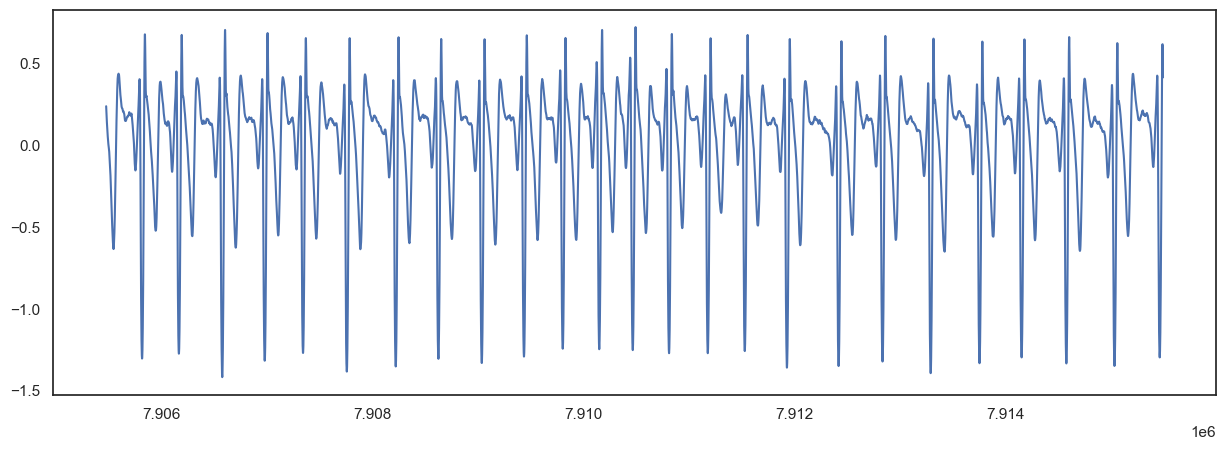

In [152]:
plt.plot(test['pEKG'])


In [153]:
test['pEKG'].values

array([0.23826345, 0.22181672, 0.2048035 , ..., 0.55243244, 0.4889071 ,
       0.41463456])

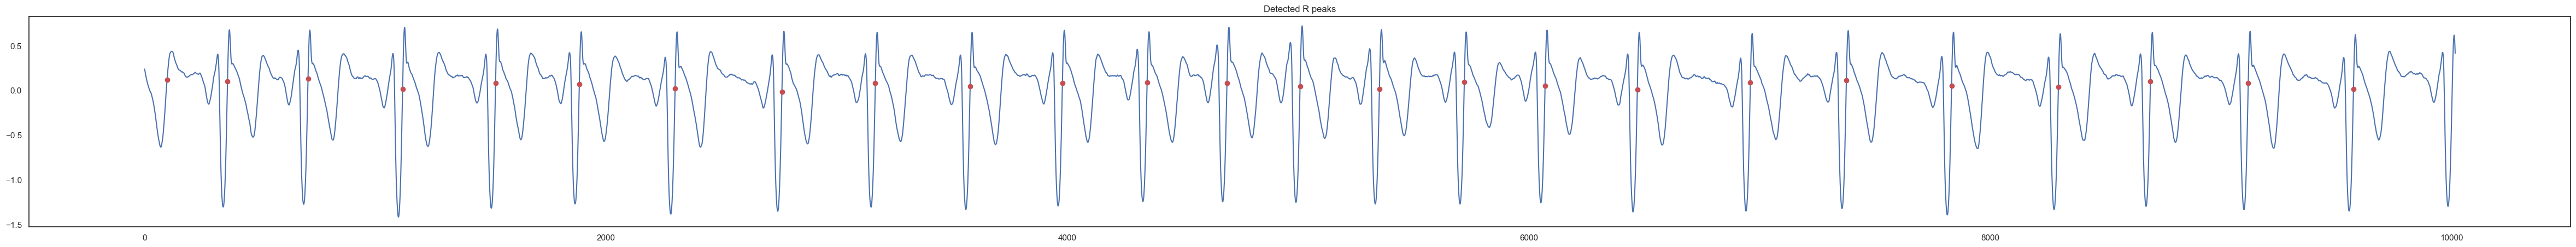

In [154]:
figsize(60, 5)
r_peaks = detectors.two_average_detector(test['pEKG'].values)
r_peaks
plt.figure()
plt.plot(test['pEKG'].values)
plt.plot(r_peaks, test['pEKG'].values[r_peaks], 'ro')
plt.title("Detected R peaks")

plt.show()

In [155]:
r_peaks

[97,
 359,
 708,
 1118,
 1521,
 1884,
 2299,
 2762,
 3167,
 3578,
 3978,
 4345,
 4691,
 5008,
 5352,
 5720,
 6070,
 6470,
 6960,
 7376,
 7832,
 8295,
 8694,
 9118,
 9574]

In [156]:
test['peaks'] = [0]*len(test)
test = test.reset_index()
test.loc[test.index.isin(r_peaks), 'peaks'] = 1
test["peaks"].unique()

array([0, 1])

### Calculate BPM using sliding window

In [157]:
#######
# Apply Sliding Windows
import sklearn.preprocessing
window_width = 1500
window_overlap = 1000
n_required_peaks = 2
results = []

for sample_start in range(0, len(test), (window_width - window_overlap)):

        segment = test[sample_start : sample_start + window_width ]
        
        if np.sum(segment['peaks']>0) <= n_required_peaks:
            results.append([sample_start, *[np.nan] , True])
        else:
            # Time-domain metrics
            bpm = ((np.sum(segment['peaks']>0))-1)*60 / ((segment.iloc[-1]['time'] - segment.iloc[0]['time']))
            results.append([sample_start,bpm,np.sum(segment['peaks']>0)])
results = pd.DataFrame(results)
results.columns = ['time_points', 'BPM', 'number_of_peaks']
results 
# This code is contributed by mits

,time_points,BPM,number_of_peaks
0,0,60.040027,4
1,500,60.040027,4
2,1000,60.040027,4
3,1500,60.040027,4
4,2000,40.026684,3
5,2500,60.040027,4
6,3000,60.040027,4
7,3500,60.040027,4
8,4000,60.040027,4
9,4500,60.040027,4


In [158]:
test

,index,time,pEKG,peaks
0,7905474,15810.948,0.238263,0
1,7905475,15810.950,0.221817,0
2,7905476,15810.952,0.204803,0
3,7905477,15810.954,0.188717,0
4,7905478,15810.956,0.174927,0
...,...,...,...,...
10011,7915485,15830.970,0.617740,0
10012,7915486,15830.972,0.596373,0
10013,7915487,15830.974,0.552432,0
10014,7915488,15830.976,0.488907,0


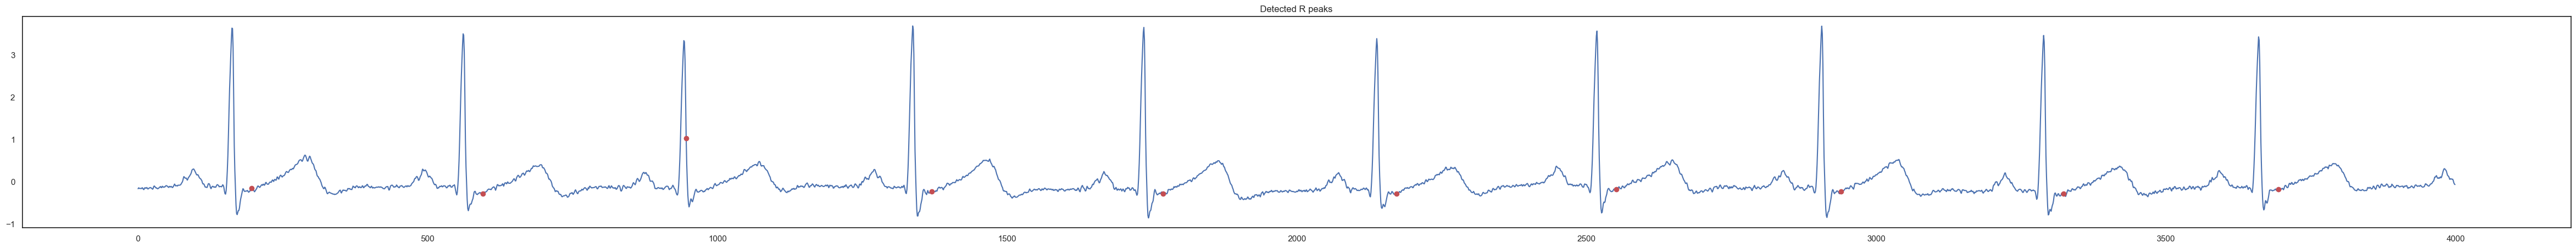

In [159]:
figsize(60, 5)
r_peaks = detectors.two_average_detector(dataDicAll['EKG']['screamOnset'][200])

plt.figure()
plt.plot(dataDicAll['EKG']['screamOnset'][200])
plt.plot(r_peaks, dataDicAll['EKG']['screamOnset'][200][r_peaks], 'ro')
plt.title("Detected R peaks")

plt.show()

In [160]:
dataDicAll['EKG']['noScreamOnset'][0]

array([ 0.180054,  0.170135,  0.182648, ..., -0.20462 , -0.19577 ,
       -0.208893])

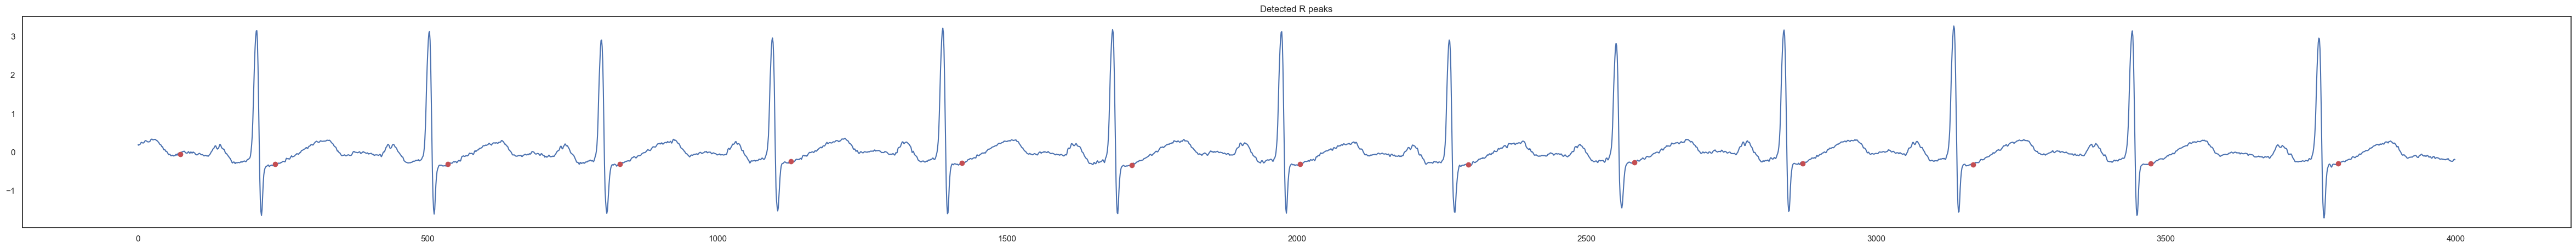

In [161]:
figsize(60, 5)
r_peaks = detectors.two_average_detector(dataDicAll['EKG']['noScreamOnset'][0])

plt.figure()
plt.plot(dataDicAll['EKG']['noScreamOnset'][0])
plt.plot(r_peaks, dataDicAll['EKG']['noScreamOnset'][0][r_peaks], 'ro')
plt.title("Detected R peaks")

plt.show()

In [162]:
def ttestsPlot(data1, data2,c1 ='#4F6A9A',c2 = '#AC5255',lab1 = "Like", lab2 = "Dislike",title = ''):

    # t-TEST
    
    diff = np.nanmean(data2) - np.nanmean(data1)  
    [s, p] = stats.ttest_rel(data1,data2,nan_policy = 'omit')
    print ("Pre IBI = "+ str(np.nanmean(data1))+ "; Post IBI = "+ str(np.nanmean(data2))+"; [Post - Pre] =  " + str(diff) +"; t =  " + str(round(s,2)) + " ; p-value =" + str(p) )
    
                
    # Set seaborn style for the plot
    fig = plt.figure(figsize=[6,10])
    sns.set(style='white',font_scale=1.5)
    jittr = np.random.uniform(low=-0.3,high=3,size=len(data1))    
    #plt.scatter([1]*len(data1)+jittr, data1, c= c1, alpha=0.7,label=lab1)
    #plt.scatter([2]*len(data2)+jittr, data2, c= c2, alpha=0.7,label=lab2)
    
    
    diff = np.subtract(data2, data1)  
    
    plt.hist(diff, 
         bins=100, 
         orientation="horizontal", edgecolor="#6A9662",
         color="#6A9662",alpha = 0.2)
    
    plt.scatter([1]*len(diff)+jittr, diff, c= c1, alpha=0.7,label=lab1)

    plt.axhline(0, color='black', lw=2, alpha=0.5,ls = '--')
    
    
    ## add lines between slope points in like and dislike for each participant
    
   # for i in range(len(data1)):
   #      plt.plot( [1 + jittr[i],2 + jittr[i]], [ data1[i] , data2[i]],'--', lw=1.0, color = 'black', alpha = 0.2)
   #      #if data1[i]<data2[i]:
   #      #    print ("Participants with slope in Like < Dislike: " + str(i))
   #         
    
    #legend(loc = 'best')
    #plt.xticks([1, 2,], [lab1, lab2],fontsize=18)
    plt.xticks([], [],fontsize=18)
    
    plt.ylabel(title, fontsize=18)
    sns.despine()

/Users/stelladong/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/stelladong/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Pre IBI = 0.7740235337787676; Post IBI = 0.7971764662212324; [Post - Pre] =  0.023152932442464746; t =  -8.95 ; p-value =9.849225410749174e-18
Pre IBI = 0.7669937816341286; Post IBI = 0.7880412147505422; [Post - Pre] =  0.02104743311641366; t =  -9.38 ; p-value =2.9858991827265187e-19


Text(0.5, 1.0, ' Scream ')

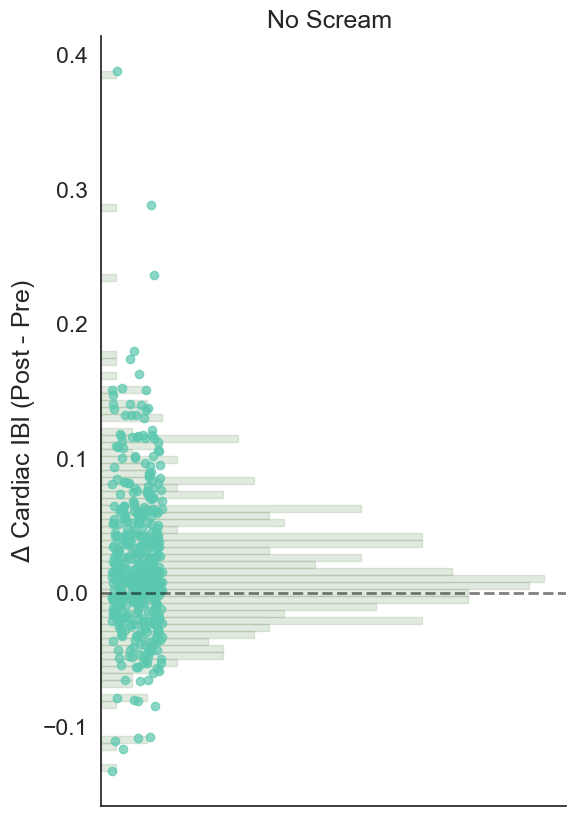

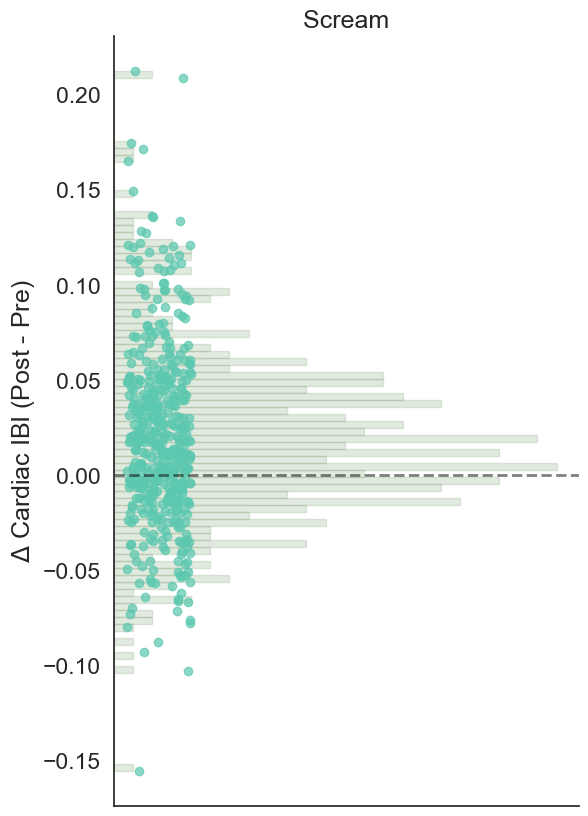

In [163]:
preIBI_noScream,postIBI_noScream = prePostIBI(dataDicAll['EKG']['screamOnset'])
preIBI_scream,postIBI_scream = prePostIBI(dataDicAll['EKG']['noScreamOnset'])

ttestsPlot(preIBI_noScream, postIBI_noScream,'#5BC8AF','#F9CB40',"Pre",  "Post",title = "$\Delta$ Cardiac IBI (Post - Pre)" )
plt.title("No Scream ")

ttestsPlot(preIBI_scream, postIBI_scream,'#5BC8AF','#F9CB40',"Pre",  "Post",title = '$\Delta$ Cardiac IBI (Post - Pre)')
plt.title(" Scream ")


Pre IBI = 0.7792389972144848; Post IBI = 0.7849316620241412; [Post - Pre] =  0.005692664809656467; t =  -2.0 ; p-value =0.0461503628799969
Pre IBI = 0.7768977135980747; Post IBI = 0.7763995788206979; [Post - Pre] =  -0.000498134777376813; t =  0.2 ; p-value =0.8427819278270552


Text(0.5, 1.0, ' Information cue onset ')

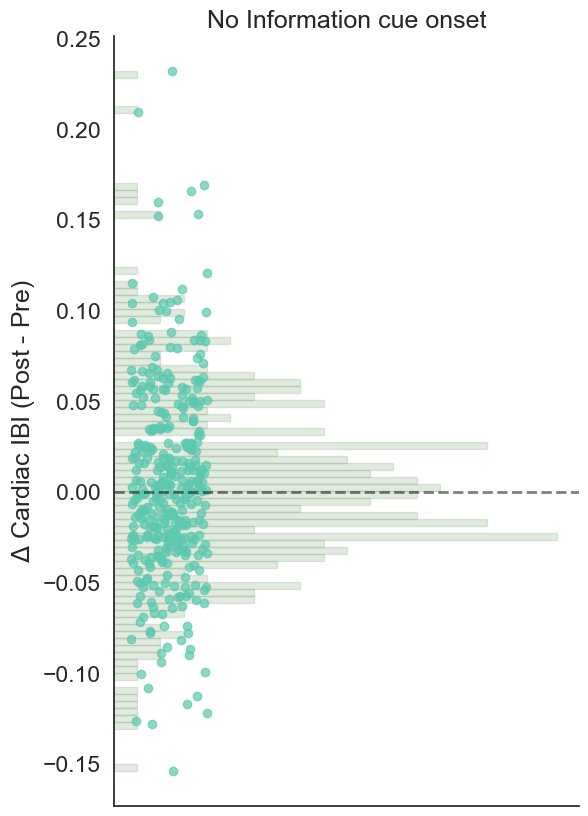

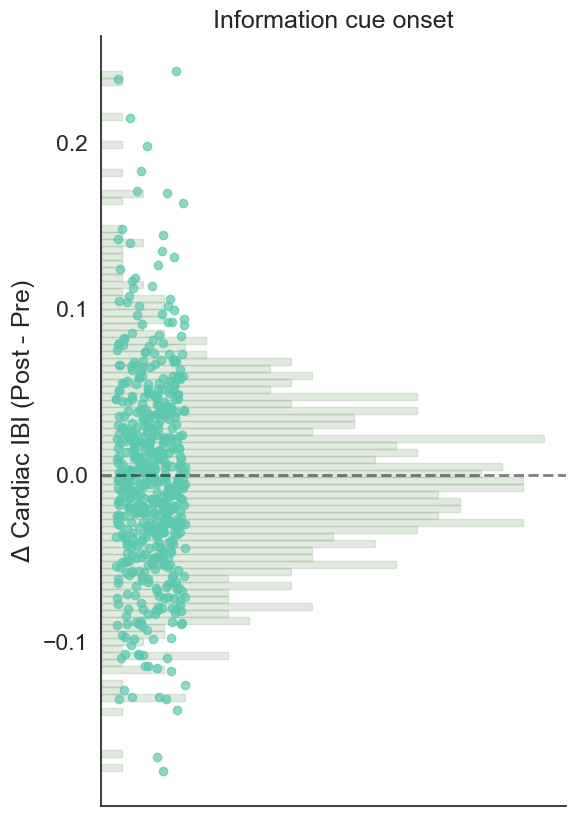

In [164]:
preIBI_noScream,postIBI_noScream = prePostIBI(dataDicAll['EKG']['stimNoInfoOnset'])
preIBI_scream,postIBI_scream = prePostIBI(dataDicAll['EKG']['stimInfoOnset'])

ttestsPlot(preIBI_noScream, postIBI_noScream,'#5BC8AF','#F9CB40',"Pre",  "Post",title = "$\Delta$ Cardiac IBI (Post - Pre)" )
plt.title(" No Information cue onset ")

ttestsPlot(preIBI_scream, postIBI_scream,'#5BC8AF','#F9CB40',"Pre",  "Post",title = '$\Delta$ Cardiac IBI (Post - Pre)')
plt.title(" Information cue onset ")


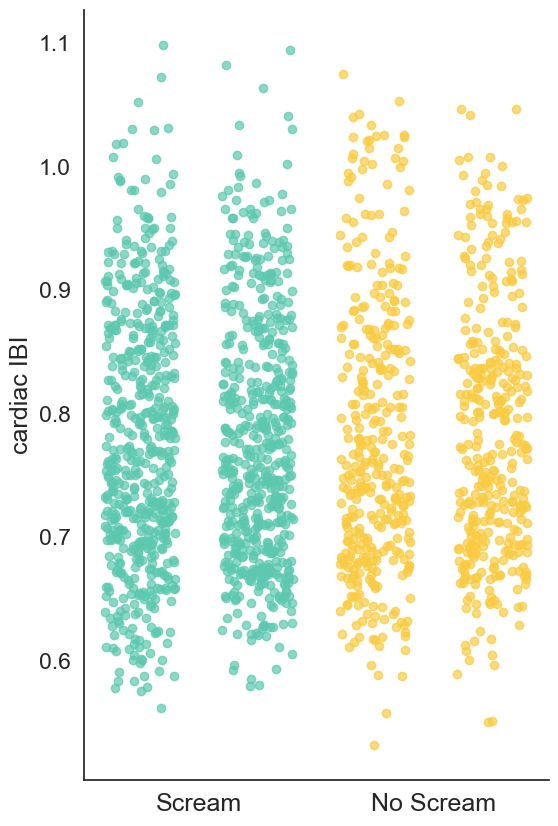

In [165]:
# Set seaborn style for the plot
fig = plt.figure(figsize=[6,10])
lab1 = "Scream"  
lab2 = "No Scream"
c1 = '#5BC8AF'
c2 = '#F9CB40'

sns.set(style='white',font_scale=1.5)
jittr = np.random.uniform(low=-0.3,high=0.3,size=len(preIBI_scream))    
plt.scatter([1]*len(preIBI_scream)+jittr, preIBI_scream, c= c1, alpha=0.7,label=lab1)
plt.scatter([2]*len(postIBI_scream)+jittr, postIBI_scream, c= c1, alpha=0.7,label=lab2)
jittr = np.random.uniform(low=-0.3,high=0.3,size=len(preIBI_noScream))    
plt.scatter([3]*len(preIBI_noScream)+jittr, preIBI_noScream, c= c2, alpha=0.7,label=lab1)
plt.scatter([4]*len(postIBI_noScream)+jittr, postIBI_noScream, c= c2, alpha=0.7,label=lab2)

plt.xticks([1.5,3.5], [lab1,lab2],fontsize=18)

plt.ylabel('cardiac IBI', fontsize=18)
sns.despine()

### IBI By Beats

In [166]:
dataBaseline0= preprocess(dataBaseline)
#test_baseline = dataBaseline0.loc[(dataBaseline0['PART']=='P007'),['time','pEKG','trials','delays']]
dataBaseline0 

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,screamOnset,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays,pEKG
11296620,11296620,P003,0.221558,6.39648,0,1,0,0,0,0,...,False,False,False,False,False,1,-1.389551,False,5.0,0.040564
11296621,11296621,P003,0.194244,6.39801,0,1,0,0,0,0,...,False,False,False,False,False,1,-1.388123,False,5.0,-0.000226
11296622,11296622,P003,0.174713,6.39343,0,1,0,0,0,0,...,False,False,False,False,False,1,-1.392399,False,5.0,-0.038462
11296623,11296623,P003,0.144348,6.39496,0,1,0,0,0,0,...,False,False,False,False,False,1,-1.390971,False,5.0,-0.074215
11296624,11296624,P003,0.094757,6.39343,0,1,0,0,0,0,...,False,False,False,False,False,1,-1.392399,False,5.0,-0.107557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785339,1785339,P032,-0.132751,4.80957,0,1,0,0,0,0,...,False,False,False,False,False,129,1.840458,False,5.0,-0.010945
1785340,1785340,P032,-0.117188,4.80804,0,1,0,0,0,0,...,False,False,False,False,False,129,1.787038,False,5.0,-0.008784
1785341,1785341,P032,-0.128632,4.80957,0,1,0,0,0,0,...,False,False,False,False,False,129,1.840458,False,5.0,-0.006505
1785342,1785342,P032,-0.144043,4.80804,0,1,0,0,0,0,...,False,False,False,False,False,129,1.787038,False,5.0,-0.004102


In [167]:
### create baseline IBI for each trial

baseline_IBI = pd.DataFrame(columns=['participant', 'trial', 'baseline'])

for participant in dataBaseline0['PART'].unique():
    participant_data = dataBaseline0[dataBaseline0['PART'] == participant]
    
    for trial in participant_data['trials'].unique():
        values = []
        trial_data = participant_data[participant_data['trials'] == trial]
        r_peaks = detectors.two_average_detector(trial_data['pEKG'].values)
        values.append(r_peaks)
        diff = np.diff(values)
        trial_data = pd.DataFrame({'participant': [participant], 'trial': [trial], 'baseline': [diff]})
        baseline_IBI = pd.concat([baseline_IBI, trial_data], ignore_index=True)

for index, row in baseline_IBI.iterrows():
    values = row['baseline'][0]
    if len(values) > 1:
        mean_value = np.mean(values)
        baseline_IBI.at[index, 'baseline'] = mean_value
    baseline_IBI['baseline'][index] = baseline_IBI['baseline'][index] / 500

baseline_IBI['PART_trial'] = baseline_IBI['participant'].astype(str) + '_' + baseline_IBI['trial'].astype(str)
baseline_IBI


,participant,trial,baseline,PART_trial
0,P003,1,0.719,P003_1
1,P003,2,0.702,P003_2
2,P003,3,0.599333,P003_3
3,P003,4,0.718,P003_4
4,P003,5,0.669333,P003_5
...,...,...,...,...
908,P032,125,0.742,P032_125
909,P032,126,0.72,P032_126
910,P032,127,0.703,P032_127
911,P032,128,0.678667,P032_128


In [168]:
### checking IBI for part P007 and trial 7
test_peaks = test[test['peaks']==1]
test_peaks

,index,time,pEKG,peaks
97,7905571,15811.142,0.115757,1
359,7905833,15811.666,0.099235,1
708,7906182,15812.364,0.128951,1
1118,7906592,15813.184,0.013105,1
1521,7906995,15813.990,0.084723,1
1884,7907358,15814.716,0.066636,1
2299,7907773,15815.546,0.019554,1
2762,7908236,15816.472,-0.018201,1
3167,7908641,15817.282,0.081873,1
3578,7909052,15818.104,0.046651,1


In [169]:
test_IBI = np.diff(test_peaks['time'])
for i in range(len(test_IBI)):
    test_IBI[i] = test_IBI[i] - baseline_IBI['baseline'][6]
test_IBI

array([-0.141,  0.033,  0.155,  0.141,  0.061,  0.165,  0.261,  0.145,
        0.157,  0.135,  0.069,  0.027, -0.031,  0.023,  0.071,  0.035,
        0.135,  0.315,  0.167,  0.247,  0.261,  0.133,  0.183,  0.247])

In [170]:
baseline_IBI['baseline'][6]

0.665

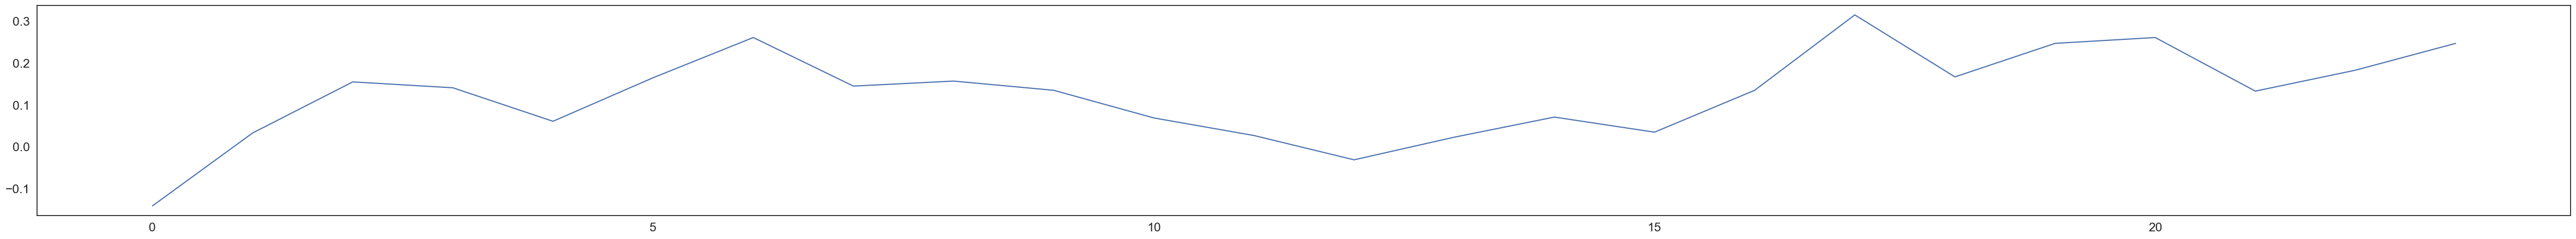

In [171]:
plt.plot(test_IBI) #IBI of P007 trial 7 (info no scream 20s delay)

### scream vs. no scream & infostim IBI across parts

In [172]:
processed_all = preprocess(dataDelay0)

In [173]:
# Create a unique identifier by concatenating 'PART' and 'trials' columns
processed_all['PART_trial'] = processed_all['PART'].astype(str) + '_' + processed_all['trials'].astype(str)

# Filter the trials where 'scream' column is 1
trialNum_scream = processed_all.loc[processed_all['scream'] == 1, 'PART_trial'].unique()
trialNum_noScream = processed_all.loc[processed_all['noScream'] == 1, 'PART_trial'].unique()


# Filter the DataFrame based on each unique trial number and 'stimInfo' column
#this is wrong because it will also include trials where there's no info but during infochoice time
processed_stimInfo_scream = processed_all[(processed_all['PART_trial'].isin(trialNum_scream)) & (processed_all['stimInfo'] == 1)] 
processed_stimInfo_noScream = processed_all[(processed_all['PART_trial'].isin(trialNum_noScream)) & (processed_all['stimInfo'] == 1) ]

# Filter the trials in scream and no scream conditions, where 'stimInfo' is 1
trialNum_screamInfo = processed_stimInfo_scream['PART_trial'].unique()
trialNum_noScreamInfo = processed_stimInfo_noScream['PART_trial'].unique()


In [174]:
# extract data that includes both infoChoice and stimInfo
processed_stimInfo_scream = processed_all[(processed_all['PART_trial'].isin(trialNum_screamInfo)) & ((processed_all['stimInfo'] == 1) | (processed_all['infoChoice'] == 1))] 
processed_stimInfo_noScream = processed_all[(processed_all['PART_trial'].isin(trialNum_noScreamInfo)) & ((processed_all['stimInfo'] == 1) | (processed_all['infoChoice'] == 1))] 

In [175]:
processed_stimInfo_noScream.loc[(processed_stimInfo_noScream['PART_trial']=='P013_63')&processed_stimInfo_noScream['stimInfoOnset']==1]

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays,pEKG,PART_trial
6443247,6443247,P013,0.078888,11.7599,0,0,0,1,0,0,...,False,False,True,False,63,-0.914878,False,20.0,0.034657,P013_63
6455457,6455457,P013,0.233459,11.9720,0,0,0,1,0,0,...,False,False,True,False,63,-0.483416,False,20.0,0.331252,P013_63


In [176]:
processed_stimInfo_noScream[processed_stimInfo_noScream['PART_trial']=='P013_63']

,Unnamed: 0,PART,EKG,EDA,startBlock,startTrial,infoChoice,stimInfo,stimNoInfo,scream,...,noScreamOnset,infoChoiceOnset,stimInfoOnset,stimNoInfoOnset,trials,zEDA,startBlockOnset,delays,pEKG,PART_trial
6441832,6441832,P013,-0.152588,11.6562,0,0,1,0,0,0,...,False,True,False,False,63,-1.125829,False,20.0,-0.185497,P013_63
6441833,6441833,P013,-0.167999,11.6592,0,0,1,0,0,0,...,False,False,False,False,63,-1.119726,False,20.0,-0.187289,P013_63
6441834,6441834,P013,-0.182800,11.6592,0,0,1,0,0,0,...,False,False,False,False,63,-1.119726,False,20.0,-0.189227,P013_63
6441835,6441835,P013,-0.159302,11.6577,0,0,1,0,0,0,...,False,False,False,False,63,-1.122777,False,20.0,-0.191442,P013_63
6441836,6441836,P013,-0.145721,11.6577,0,0,1,0,0,0,...,False,False,False,False,63,-1.122777,False,20.0,-0.192919,P013_63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6461009,6461009,P013,0.103302,12.0300,0,0,0,1,0,0,...,False,False,False,False,63,-0.365430,False,20.0,0.078827,P013_63
6461010,6461010,P013,0.107422,12.0316,0,0,0,1,0,0,...,False,False,False,False,63,-0.362175,False,20.0,0.084700,P013_63
6461011,6461011,P013,0.106659,12.0316,0,0,0,1,0,0,...,False,False,False,False,63,-0.362175,False,20.0,0.089905,P013_63
6461012,6461012,P013,0.129852,12.0300,0,0,0,1,0,0,...,False,False,False,False,63,-0.365430,False,20.0,0.095090,P013_63


### HEREHEREHEREHEREHERHERE

In [189]:
### returns all IBI by delay time
def stimInfo_IBI(data):
    
    data['peaks'] = [0]*len(data)
    test_IBI_by_delay = {}

    for trials in data['PART_trial'].unique():
        trial_data = data[data['PART_trial']==trials]
        r_peaks = detectors.two_average_detector(trial_data['pEKG'].values)
        trial_data = trial_data.reset_index()
        trial_data.loc[trial_data.index.isin(r_peaks), 'peaks'] = 1

        peaks_data = trial_data[trial_data['peaks']==1]

        # extract time point stimInfo is presented
        infoStimOnset = trial_data.loc[trial_data['stimInfoOnset'] == 1, 'time'].values
        if(len(infoStimOnset)>1):
            infoStimOnset = infoStimOnset[0]

        # Mark test_IBI values before and after infoStimOnset
        before_stim = []
        after_stim = []
        baseline_data = baseline_IBI[baseline_IBI['PART_trial'] == trials]['baseline'].values
        
        for time in peaks_data['time']:
            if time < infoStimOnset:
                before_stim.append(peaks_data.loc[peaks_data['time']==time,'time'])
            else:
                after_stim.append(peaks_data.loc[peaks_data['time']==time,'time'])
        
        before_IBI = np.diff(np.ravel(np.array([entry for entry in before_stim])))
        before_IBI = [val - baseline_data for val in before_IBI]
        
        
        after_IBI = np.diff(np.ravel(np.array([entry for entry in after_stim])))
        after_IBI = [val - baseline_data for val in after_IBI]

        # concatenate before_stim, mark, and after_stim
        mark = ['mark']
        test_IBI = before_IBI + mark + after_IBI

        delay_time = trial_data['delays'].unique()[0]
        if delay_time not in test_IBI_by_delay:
            test_IBI_by_delay[delay_time] = {}

        # If there are no values after infoStimOnset, set flag to False
        flag = bool(after_stim)

        # add infoStimOnset, test_IBI, and the marked values to test_IBI_by_delay
        test_IBI_by_delay[delay_time][trials] = {
            'before_IBI': before_IBI,
            'after_IBI': after_IBI,
        }

    return test_IBI_by_delay



In [346]:
#calculate average IBI for each delay and returns final IBI + error bar to be plotted

def stimInfo_avgIBI(data):
    average_values_before_list = []
    #standard_error_before_list = []
    average_values_after_list = []
    standard_error_list = []

    for delay_time in data:
        # Access the trial data for the current delay time
        delay_data = data[delay_time]        
        
        min_length_before = max(2,min(len(delay_data[part_trial]['before_IBI']) for part_trial in delay_data.keys()))
        min_length_after = max(2,min(len(delay_data[part_trial]['after_IBI']) for part_trial in delay_data.keys()))
        
        # Calculate the average value in each position
        average_values_before = np.zeros(min_length_before)
        average_values_after = np.zeros(min_length_after)
        
        num_nonempty_arrays_before = 0  # Counter for non-empty arrays
        num_nonempty_arrays_after = 0
        
        values_list = []

        for part_trial in delay_data:
            values_before = np.array(delay_data[part_trial]['before_IBI'][:min_length_before], dtype='float64')
            values_before = np.ndarray.flatten(values_before)
            values_after = np.array(delay_data[part_trial]['after_IBI'][:min_length_after], dtype='float64')
            values_after = np.ndarray.flatten(values_after)
            
            
            values = np.concatenate((values_before,values_after))
            values = np.ndarray.flatten(values)
            values_list.append(values)
            
            # Skip if the array is empty
            if len(values_before) == 0 or len(values_after) == 0:
                continue

            average_values_before += values_before
            num_nonempty_arrays_before +=1
            average_values_after += values_after
            num_nonempty_arrays_after += 1
    
        values_size = max(len(array) for array in values_list)
    
        for i in range(len(values_list)):
            if len(values_list[i]) != values_size:
                num = values_size-len(values_list[i])
                values_list[i] = np.append(values_list[i],[np.nan]*num)

    
        # Calculate the mean and standard error only if there are non-empty arrays
        if num_nonempty_arrays_before > 0:
            average_values_before /= num_nonempty_arrays_before
            #standard_error_before = sem(average_values_before)
        #else:
            #standard_error_before = np.nan

        average_values_before_list.append(average_values_before)
        #standard_error_before_list.append(standard_error_before)
        
        if num_nonempty_arrays_after > 0:
            average_values_after /= num_nonempty_arrays_after
            average_values_after_list.append(average_values_after)
            #standard_error_after = sem(average_values_after)
        #else:
            #standard_error_after = np.nan
        ''' 
        #combine before and after to calculate standard error
    
        average_values = np.concatenate((average_values_before,average_values_after))
        if  num_nonempty_arrays_before+num_nonempty_arrays_after>0:
            standard_error = sem(average_values)
        else:
            standard_error = np.nan

        
        standard_error_list.append(standard_error)
    '''
    
    #********#*#*#***************#calcualte standard error 
        transposed_arrays = np.array(values_list).T

        standard_errors = []

        # Calculate the standard error for each entry
        for entry in transposed_arrays:
            std_error = scipy.stats.sem(entry, nan_policy='omit')
            standard_errors.append(std_error)
        standard_error_list.append(standard_errors)

    #********#*#*#***************#
        
    average_values_df = pd.DataFrame({
        'Delay Time': data.keys(),
        'Average Values Before': average_values_before_list,
        #'Standard Error Before': standard_error_before_list,
        'Average Values After': average_values_after_list,
        'Standard Error': standard_error_list,
        #'stimInfoOnset' : sti
    })

    return average_values_df


In [347]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

info_scream_IBI = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_scream))
info_noScream_IBI = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_noScream))

warnings.filterwarnings("default")

In [348]:
info_scream_IBI

,Delay Time,Average Values Before,Average Values After,Standard Error
0,5.0,"[-0.04912222222234743, -0.021922222222096298]","[-0.0015888888887757747, -0.002055555555560251...","[0.017248464929839842, 0.011368643407765278, 0..."
1,10.0,"[-0.046944444444383254, 0.012341269841304162]","[0.032817460317811666, 0.014912698412707117, 0...","[0.01645596945542719, 0.012308251833292231, 0...."
2,2.0,"[-0.07422222222207628, -0.034074074073791163]","[0.04888888888890476, 0.04414814814820033]","[0.01859787044141125, 0.016754664614782824, 0...."
3,20.0,"[-0.029696969696901332, -0.022363636363507144]","[0.01987878787866922, 0.015030303030485056, 0....","[0.01572895389891262, 0.011734820546881615, 0...."


In [349]:
info_noScream_IBI

,Delay Time,Average Values Before,Average Values After,Standard Error
0,2.0,"[-0.042516666666569974, -0.025166666666661924]","[-0.0006166666666541198, -0.0043666666664787575]","[0.010463309823030426, 0.006387496941616809, 0..."
1,5.0,"[-0.04457246376810691, -0.02957246376826266]","[0.013166666666518894, 0.009297101449515666, -...","[0.014612602318343297, 0.008951446711368207, 0..."
2,20.0,"[-0.05063945578225389, -0.03680272108843902]","[0.019972789115787256, -0.004761904762018756, ...","[0.0132388378069449, 0.009150229968511803, 0.0..."
3,10.0,"[-0.04377192982464664, -0.03529824561401554]","[0.0030701754385464384, -0.006666666666501432,...","[0.011784064493163795, 0.007912966922459382, 0..."


In [379]:
len(np.array(info_noScream_IBI['Standard Error'][info_noScream_IBI['Delay Time'] == 20].values)[0])

21

In [312]:
len(info_noScream_IBI['Standard Error'][0])

80

In [552]:
def plot_whole_IBI(info_scream_IBI,info_noScream_IBI,delay):
    

    scream_before = info_scream_IBI.loc[info_scream_IBI['Delay Time'] == delay, 'Average Values Before']
    scream_before.index = [0]
    scream_after = info_scream_IBI.loc[info_scream_IBI['Delay Time'] == delay, 'Average Values After']
    scream_after.index = [0]


    noScream_before = info_noScream_IBI.loc[info_noScream_IBI['Delay Time'] == delay, 'Average Values Before']
    noScream_before.index = [0]

    noScream_after = info_noScream_IBI.loc[info_noScream_IBI['Delay Time'] == delay, 'Average Values After']
    noScream_after.index = [0]



    # Concatenate the "before" and "after" values into a single array
    combined_noScream = np.concatenate([np.concatenate(noScream_before), np.concatenate(noScream_after)])
    combined_scream = np.concatenate([np.concatenate(scream_before), np.concatenate(scream_after)])

    # Plotting
    #fig, ax = plt.subplots()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)



    # Plot the combined values as a single line
    #plt.plot(combined_scream, label='info scream')
    #plt.plot(combined_noScream, label='info no scream')


    # Calculate the index where the "after" values start
    noScream_after_start_index = len(noScream_before[0])
    scream_after_start_index = len(scream_before[0])
    # Add a vertical line at the separation point
    
    #ax.axvline(x=noScream_after_start_index, linestyle='--', label = 'infoStimOnset',color='red')
    
    #calcualte and plot error bar
    info_no_scream_standard_error = np.array(info_noScream_IBI['Standard Error'][info_noScream_IBI['Delay Time'] == delay].values)[0]
    
    info_scream_standard_error = np.array(info_scream_IBI['Standard Error'][info_scream_IBI['Delay Time'] == delay].values)[0]
    
        
    #ensure standard error and average values are the same length
    if len(info_scream_standard_error) > (len(combined_scream)):
        info_scream_standard_error = info_scream_standard_error[:len(combined_scream)]
    else:
        combined_scream = combined_scream[:len(info_scream_standard_error)]
        
    if len(info_no_scream_standard_error) > (len(combined_noScream)):
        info_no_scream_standard_error = info_no_scream_standard_error[:len(combined_noScream)]
    else:
        combined_noScream = combined_noScream[:len(info_no_scream_standard_error)]
    
    if delay == 5:
        x_scream_values = [-2,-1,0,1,2,3]
        x_noScream_values = [-2,-1,0,1,2]
    elif delay == 2:
        x_scream_values =[-2,-1,0,1]
        x_noScream_values =[-2,-1,0,1]
    elif delay == 10:
        x_scream_values =[-2,-1,0,1,2,3,4,5,6,7,8]
        x_noScream_values =[-2,-1,0,1,2,3,4,5,6,7,8]
    elif delay == 20:
        x_scream_values =[-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
        x_noScream_values =[-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
    else:
        x_scream_values = range(len(combined_scream))
        x_noScream_values = range(len(combined_noScream))
    
  
    

    plt.errorbar(x_scream_values, combined_scream, yerr=info_scream_standard_error, label='scream',color='#8DB38B')
    plt.errorbar(x_noScream_values, combined_noScream, yerr=info_no_scream_standard_error,label='no scream',color='#FD7E84')
    
    ax.axvline(0, linestyle='--', label = 'info cue',color='#0B3954')
    
    #print(info_scream_standard_error)
    #print(info_no_scream_standard_error)

    
    plt.scatter(x_scream_values, combined_scream,color='#8DB38B')
    plt.scatter(x_noScream_values, combined_noScream,color='#FD7E84')

    # Set labels and title
    ax.set_xlabel('Beats', fontsize=25)
    ax.set_ylabel('Normalized IBI', fontsize=25)
                
    if len(x_scream_values) > len(x_noScream_values):
        ax.set_xticks(x_scream_values, fontsize=20)
    else:
        ax.set_xticks(x_noScream_values, fontsize=20)

    plt.tick_params(axis='x', labelsize=25)

    plt.tick_params(axis='y', labelsize=25)
    sns.set_style("white")
    sns.despine()
    #ax.set_aspect(1.0)

    ax.set_title("{} second delay".format(delay))

    # Add a legend
    ax.legend(fontsize=25)

    

    # Show the plot
    #plt.show()


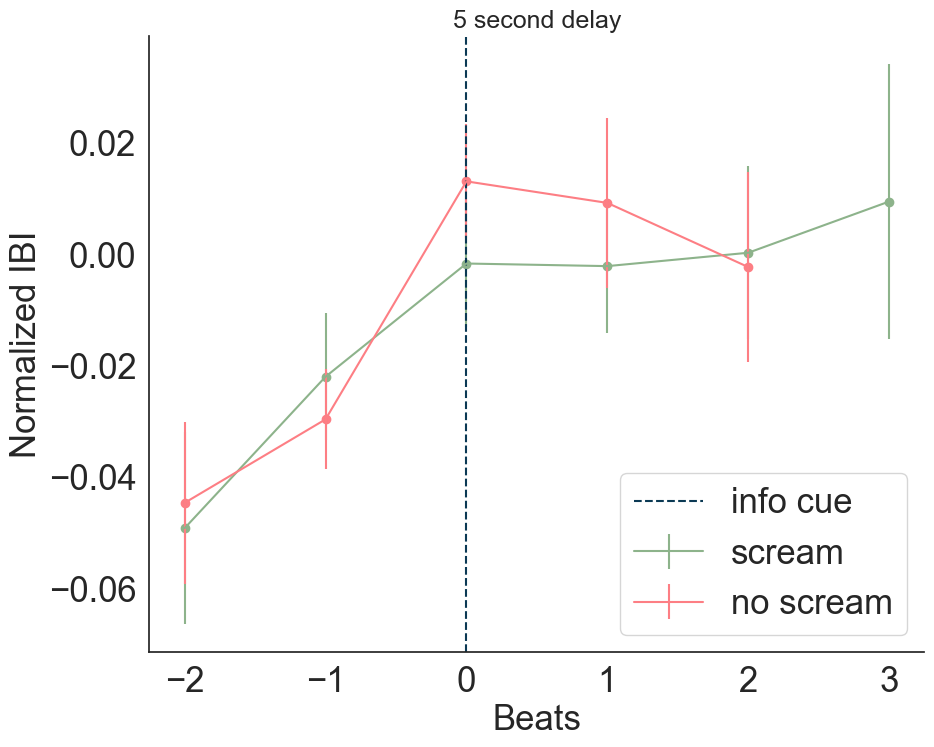

In [553]:
plot_whole_IBI(info_scream_IBI,info_noScream_IBI,5)
plt.savefig('info_scream_IBI_5.png',bbox_inches='tight')

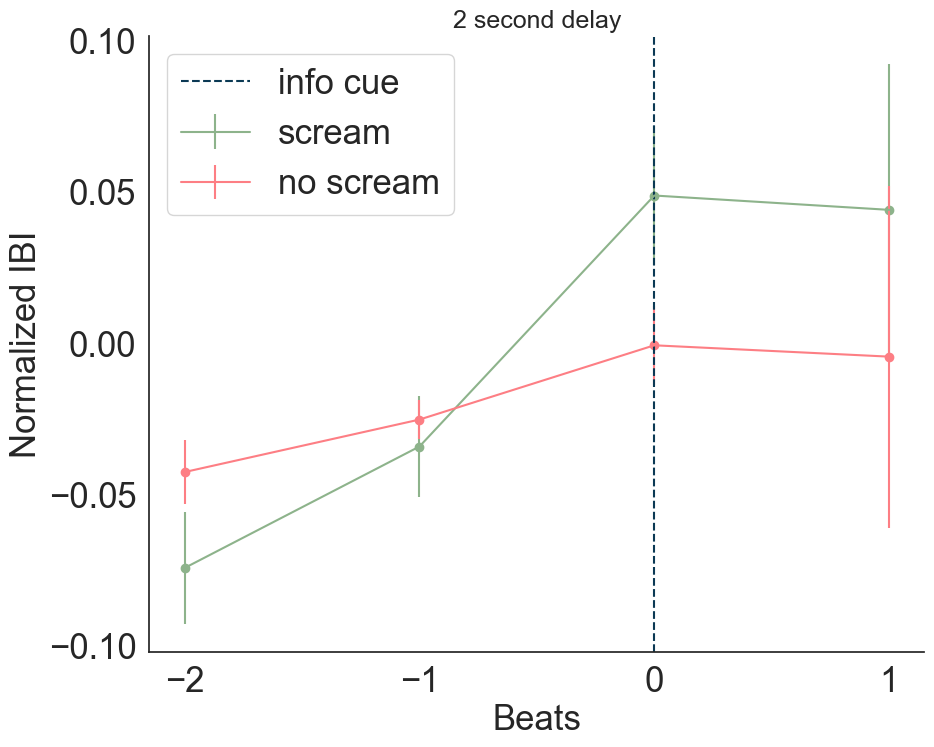

In [554]:
plot_whole_IBI(info_scream_IBI,info_noScream_IBI,2)
plt.savefig('info_scream_IBI_2.png',bbox_inches='tight')

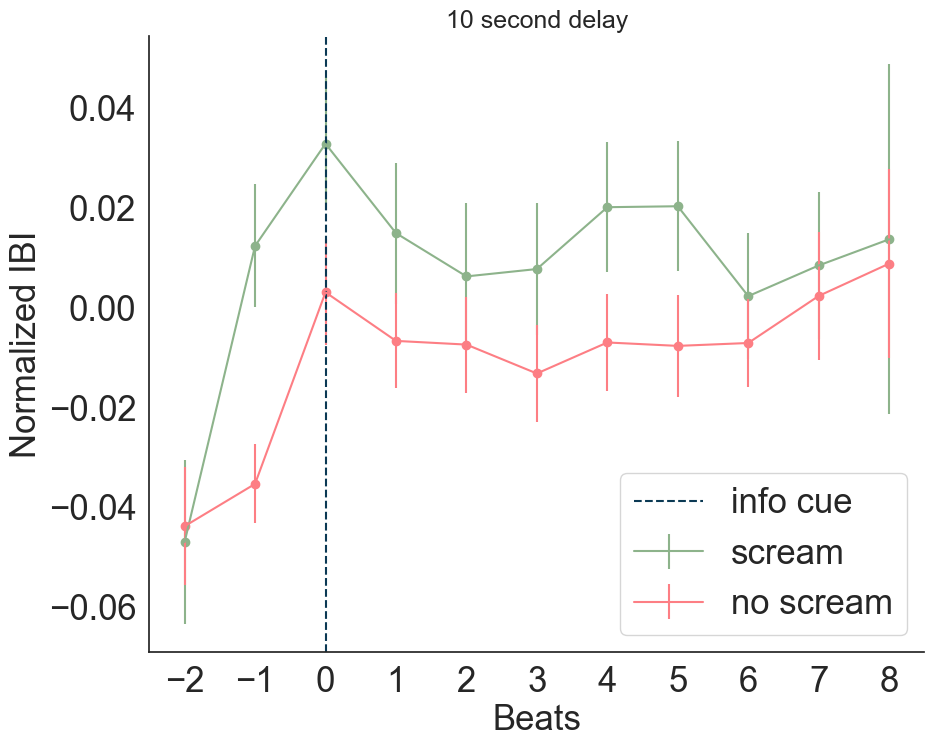

In [555]:
plot_whole_IBI(info_scream_IBI,info_noScream_IBI,10)
plt.savefig('info_scream_IBI_10.png',bbox_inches='tight')

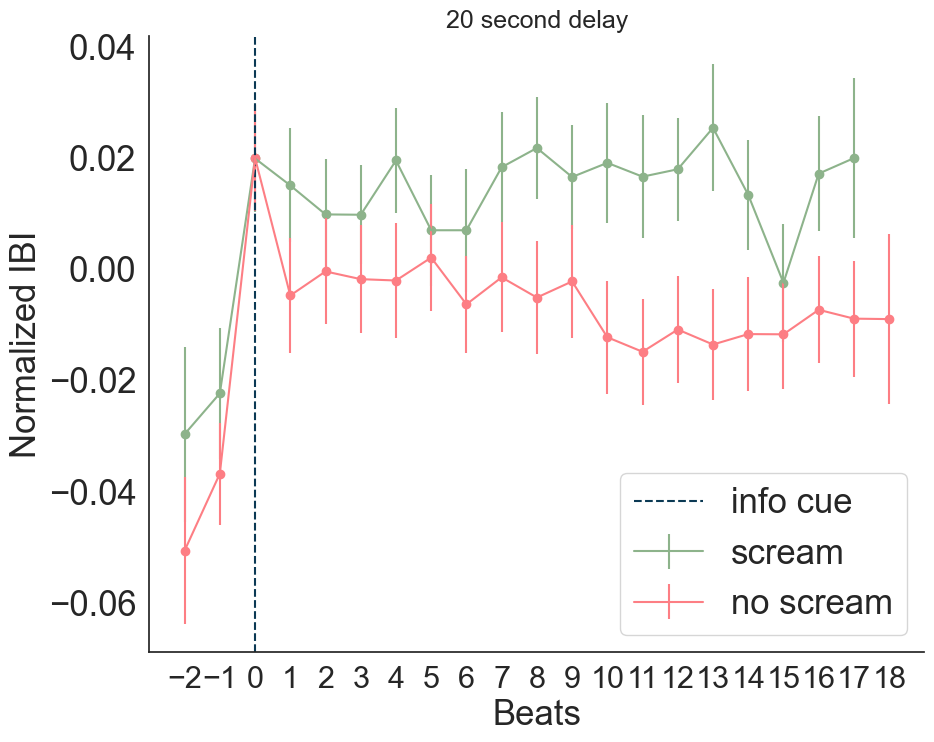

In [560]:
plot_whole_IBI(info_scream_IBI,info_noScream_IBI,20)
plt.xticks(fontsize = 22)
plt.savefig('info_scream_IBI_20.png',bbox_inches='tight')

In [450]:
info_scream = stimInfo_IBI(processed_stimInfo_scream)
info_noScream = stimInfo_IBI(processed_stimInfo_noScream)

/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_1704/3715898691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['peaks'] = [0]*len(data)
/var/folders/vy/xvd6jlhs26z1z9_9p0x131z80000gn/T/ipykernel_1704/3715898691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['peaks'] = [0]*len(data)


In [ ]:
info_scream

### Check IBI after screaming 

In [ ]:
# extract data that includes both infoChoice and stimInfo
processed_stimInfo_post_scream = processed_all[(processed_all['PART_trial'].isin(trialNum_screamInfo)) & ((processed_all['stimInfo'] == 1) | (processed_all['scream'] == 1)|(processed_all['endTrial'] == 1))] 
processed_stimInfo_post_noScream = processed_all[(processed_all['PART_trial'].isin(trialNum_noScreamInfo)) & ((processed_all['stimInfo'] == 1) | (processed_all['noScream'] == 1)|(processed_all['endTrial'] == 1))] 

In [ ]:
### returns all IBI by delay time
def post_stimInfo_IBI(data):
    
    data['peaks'] = [0]*len(data)
    test_IBI_by_delay = {}

    for trials in data['PART_trial'].unique():
        trial_data = data[data['PART_trial']==trials]
        r_peaks = detectors.two_average_detector(trial_data['pEKG'].values)
        trial_data = trial_data.reset_index()
        trial_data.loc[trial_data.index.isin(r_peaks), 'peaks'] = 1

        peaks_data = trial_data[trial_data['peaks']==1]

        # extract time point stimInfo is presented
        infoStimOnset = trial_data.loc[(trial_data['screamOnset'] == 1)|(trial_data['noScreamOnset'] == 1), 'time'].values
        if(len(infoStimOnset)>1):
            infoStimOnset = infoStimOnset[0]

        # Mark test_IBI values before and after infoStimOnset
        before_stim = []
        after_stim = []
        baseline_data = baseline_IBI[baseline_IBI['PART_trial'] == trials]['baseline'].values
        
        for time in peaks_data['time']:
            if time < infoStimOnset:
                before_stim.append(peaks_data.loc[peaks_data['time']==time,'time'])
            else:
                after_stim.append(peaks_data.loc[peaks_data['time']==time,'time'])
        
        before_IBI = np.diff(np.ravel(np.array([entry for entry in before_stim])))
        before_IBI = [val - baseline_data for val in before_IBI]
        
        
        after_IBI = np.diff(np.ravel(np.array([entry for entry in after_stim])))
        after_IBI = [val - baseline_data for val in after_IBI]


        # concatenate before_stim, mark, and after_stim
        mark = ['mark']
        test_IBI = before_IBI + mark + after_IBI

        delay_time = trial_data['delays'].unique()[0]
        if delay_time not in test_IBI_by_delay:
            test_IBI_by_delay[delay_time] = {}

        # If there are no values after infoStimOnset, set flag to False
        flag = bool(after_stim)

        # add infoStimOnset, test_IBI, and the marked values to test_IBI_by_delay
        test_IBI_by_delay[delay_time][trials] = {
            'before_IBI': before_IBI,
            'after_IBI': after_IBI
        }

    return test_IBI_by_delay

In [ ]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

post_info_scream_IBI = stimInfo_avgIBI(post_stimInfo_IBI(processed_stimInfo_post_scream))
post_info_noScream_IBI = stimInfo_avgIBI(post_stimInfo_IBI(processed_stimInfo_post_noScream))

warnings.filterwarnings("default")

In [ ]:
post_info_scream_IBI

In [ ]:
post_info_noScream_IBI

In [ ]:
plot_whole_IBI(post_info_scream_IBI,post_info_noScream_IBI,5)
plot_whole_IBI(post_info_scream_IBI,post_info_noScream_IBI,10)
plot_whole_IBI(post_info_scream_IBI,post_info_noScream_IBI,20)

In [ ]:
processed_all.columns

In [ ]:
def halves_IBI(df):
    IBI_df = pd.DataFrame()

    for delay, values in df.items():
        # Create a temporary data frame for the current delay
        temp_df = pd.DataFrame.from_dict(values, orient='index')
        
        # Merge values of different columns into one column as an array
        #temp_df['IBI'] = temp_df.apply(lambda row: np.array(row.dropna().values), axis=1)

        # Drop NaN values and previous columns, keeping only the merged column
        #temp_df.dropna(subset=['IBI'], inplace=True)
        #temp_df.drop(columns=temp_df.columns[:-1], inplace=True)

        temp_df['part_trial'] = values.keys()
        # Split part_trial column into part and trials columns
        temp_df[['part', 'trials']] = temp_df['part_trial'].str.split('_', 1, expand=True)
        temp_df['delays']= delay

        # Reset the index if needed
        temp_df.reset_index(drop=True, inplace=True)

        IBI_df = pd.concat([IBI_df, temp_df], axis=0)

    # Group the DataFrame by 'part' and 'delays'
    grouped_df = IBI_df.groupby(['part', 'delays'])
    

    # Define a function to split each group into halves
    def split_group(df):
        n = len(df)
        half = n // 2
        first_half = df.iloc[:half]
        second_half = df.iloc[half:]
        return [first_half, second_half]

    # Apply the split_group function to each group and concatenate the results
    split_dfs = grouped_df.apply(split_group).tolist()  # Convert to a list

    # Separate the first and second halves into separate DataFrames
    first_half_df = pd.concat([df[0] for df in split_dfs])  # Extract first half
    second_half_df = pd.concat([df[1] for df in split_dfs])  # Extract second half
    
    first_half_dict = {}
    second_half_dict = {}

    # Iterate over the DataFrame rows
    for index, row in first_half_df.iterrows():
        key1 = row['delays'] 
        key2 = row['part_trial']
        before_IBI = row['before_IBI'] 
        after_IBI = row['after_IBI']
          # Check if the outer key exists in the dictionary
        if key1 in first_half_dict:
            # Add the inner key and value to the existing inner dictionary
            first_half_dict[key1][key2] = {'before_IBI': before_IBI, 'after_IBI': after_IBI}
        else:
            # Create a new inner dictionary with the inner key and value
            first_half_dict[key1] = {key2: {'before_IBI': before_IBI, 'after_IBI': after_IBI}}

     # Iterate over the DataFrame rows
    for index, row in second_half_df.iterrows():
        key1 = row['delays'] 
        key2 = row['part_trial']
        before_IBI = row['before_IBI'] 
        after_IBI = row['after_IBI']
          # Check if the outer key exists in the dictionary
        if key1 in second_half_dict:
            # Add the inner key and value to the existing inner dictionary
            second_half_dict[key1][key2] = {'before_IBI': before_IBI, 'after_IBI': after_IBI}
        else:
            # Create a new inner dictionary with the inner key and value
            second_half_dict[key1] = {key2: {'before_IBI': before_IBI, 'after_IBI': after_IBI}}

    return first_half_dict,second_half_dict

In [ ]:
halves_IBI(info_scream)[0]

In [ ]:
scream_first_half = halves_IBI(info_scream)[0]
scream_second_half = halves_IBI(info_scream)[1]

noScream_first_half = halves_IBI(info_noScream)[0]
noScream_second_half = halves_IBI(info_noScream)[1]

In [ ]:
scream_first_avgIBI = stimInfo_avgIBI(scream_first_half)
scream_second_avgIBI = stimInfo_avgIBI(scream_second_half)

noScream_first_avgIBI = stimInfo_avgIBI(noScream_first_half)
noScream_second_avgIBI = stimInfo_avgIBI(noScream_second_half)

In [ ]:
scream_first_avgIBI

In [ ]:
def plot_splitted_IBI(data_scream,data_noScream,delay):
    scream_before = data_scream.loc[data_scream['Delay Time'] == delay, 'Average Values Before']
    scream_before.index = [0]
    scream_after = data_scream.loc[data_scream['Delay Time'] == delay, 'Average Values After']
    scream_after.index = [0]


    noScream_before = data_noScream.loc[data_noScream['Delay Time'] == delay, 'Average Values Before']
    noScream_before.index = [0]

    noScream_after = data_noScream.loc[data_noScream['Delay Time'] == delay, 'Average Values After']
    noScream_after.index = [0]



    # Concatenate the "before" and "after" values into a single array
    combined_noScream = np.concatenate([np.concatenate(noScream_before), np.concatenate(noScream_after)])
    combined_scream = np.concatenate([np.concatenate(scream_before), np.concatenate(scream_after)])
    
    # Plotting
    fig, ax = plt.subplots()

    # Calculate the index where the "after" values start
    noScream_after_start_index = len(noScream_before[0])
    scream_after_start_index = len(scream_before[0])
    # Add a vertical line at the separation point
    ax.axvline(x=scream_after_start_index, linestyle='--', label = 'infoStimOnset')
    ax.axvline(x=noScream_after_start_index, linestyle='--',label = 'infoStimOnset')
    
    #calcualte and plot error bar
    info_no_scream_standard_error = info_noScream_IBI['Standard Error'][info_noScream_IBI['Delay Time'] == delay].values
    
    info_scream_standard_error = info_scream_IBI['Standard Error'][info_scream_IBI['Delay Time'] == delay].values

    x_scream_values = range(len(combined_scream))
    x_noScream_values = range(len(combined_noScream))

    plt.errorbar(x_scream_values, combined_scream, yerr=info_scream_standard_error,label='info scream')
    plt.errorbar(x_noScream_values, combined_noScream, yerr=info_no_scream_standard_error,label='info no scream')

    # Set labels and title
    ax.set_xlabel('Beats')
    ax.set_ylabel('Normalized IBI')
    ax.set_title("info scream vs. no scream, {}s delay".format(delay))

    # Add a legend
    ax.legend()

    # Show the plot
    plt.show()

    ''''
    info_scream_average_values = np.concatenate(scream_first_avgIBI['Average Values Bfore'][scream_first_avgIBI['Delay Time'] == delay_time].values)
    info_scream_standard_error = scream_first_avgIBI['Standard Error'][scream_first_avgIBI['Delay Time'] == delay_time].values

    info_no_scream_average_values = np.concatenate(noScream_first_avgIBI['Average Values Before'][noScream_first_avgIBI['Delay Time'] == delay_time].values)
    info_no_scream_standard_error = noScream_first_avgIBI['Standard Error'][noScream_first_avgIBI['Delay Time'] == delay_time].values

    x_scream_values = range(len(info_scream_average_values))
    x_noScream_values = range(len(info_no_scream_average_values))

    plt.errorbar(x_scream_values, info_scream_average_values, yerr=info_scream_standard_error)
    plt.errorbar(x_noScream_values, info_no_scream_average_values, yerr=info_no_scream_standard_error)
    
    plt.plot(info_scream_average_values,label = 'info scream')
    plt.plot(info_no_scream_average_values,label = 'info no scream')

    plt.title("info scream vs. no scream, first half, {}s delay".format(delay_time))
    plt.legend()
    plt.show()
'''

In [ ]:
plot_splitted_IBI(scream_first_avgIBI,noScream_first_avgIBI,5)

In [ ]:
plot_splitted_IBI(scream_second_avgIBI,noScream_second_avgIBI,5)

In [ ]:
plot_splitted_IBI(scream_first_avgIBI,noScream_first_avgIBI,10)

In [ ]:
plot_splitted_IBI(scream_second_avgIBI,noScream_second_avgIBI,10)

In [ ]:
plot_splitted_IBI(scream_first_avgIBI,noScream_first_avgIBI,20)

In [ ]:
plot_splitted_IBI(scream_second_avgIBI,noScream_second_avgIBI,20)

In [ ]:
def plot_second_IBI(delay_time):
    info_scream_average_values = np.concatenate(scream_second_avgIBI['Average Values'][scream_second_avgIBI['Delay Time'] == delay_time].values)
    info_scream_standard_error = scream_second_avgIBI['Standard Error'][scream_second_avgIBI['Delay Time'] == delay_time].values

    info_no_scream_average_values = np.concatenate(noScream_second_avgIBI['Average Values'][noScream_second_avgIBI['Delay Time'] == delay_time].values)
    info_no_scream_standard_error = noScream_second_avgIBI['Standard Error'][noScream_second_avgIBI['Delay Time'] == delay_time].values

    x_scream_values = range(len(info_scream_average_values))
    x_noScream_values = range(len(info_no_scream_average_values))

    plt.errorbar(x_scream_values, info_scream_average_values, yerr=info_scream_standard_error)
    plt.errorbar(x_noScream_values, info_no_scream_average_values, yerr=info_no_scream_standard_error)
    
    plt.plot(info_scream_average_values,label = 'info scream')
    plt.plot(info_scream_standard_error,label = 'info no scream')

    plt.title("info scream vs. no scream, first half, {}s delay".format(delay_time))
    plt.legend()
    plt.show()

### Check which participant included training block

In [ ]:
plt.figure(figsize=(50,6))

P003 = dataDF1[dataDF1['PART']=='P003']

plt.plot(P003['time'],P003['startBlock'], label = 'startBlock')
plt.plot(P003['time'],P003['startTrial'], label = 'startTrial')
#plt.plot(P003['time'],P003['infoChoice'], label = 'infoChoice')
#plt.plot(P003['time'],P003['stimInfo'], label = 'stimInfo')
#plt.plot(P003['time'],P003['stimNoInfo'], label = 'stimNoInfo')

#plt.plot(P003['time'],P003['scream'], label = 'scream')
#plt.plot(P003['time'],P003['noScream'], label = 'noScream')
#plt.plot(P003['time'],P003['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
#plt.figure(figsize=(50,6))

P005 = dataDF1[dataDF1['PART']=='P005']

plt.plot(P005['time'],P005['startBlock'], label = 'startBlock',lw=20)
plt.plot(P005['time'],P005['startTrial'], label = 'startTrial')
plt.plot(P005['time'],P005['infoChoice'], label = 'infoChoice')
plt.plot(P005['time'],P005['stimInfo'], label = 'stimInfo')
plt.plot(P005['time'],P005['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P005['time'],P005['scream'], label = 'scream')
plt.plot(P005['time'],P005['noScream'], label = 'noScream')
plt.plot(P005['time'],P005['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P007 = dataDF1[dataDF1['PART']=='P007']

plt.plot(P007['time'],P007['startBlock'], label = 'startBlock')
plt.plot(P007['time'],P007['startTrial'], label = 'startTrial')
plt.plot(P007['time'],P007['infoChoice'], label = 'infoChoice')
plt.plot(P007['time'],P007['stimInfo'], label = 'stimInfo')
plt.plot(P007['time'],P007['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P007['time'],P007['scream'], label = 'scream')
plt.plot(P007['time'],P007['noScream'], label = 'noScream')
plt.plot(P007['time'],P007['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P010 = dataDF1[dataDF1['PART']=='P010']

plt.plot(P010['time'],P010['startBlock'], label = 'startBlock')
plt.plot(P010['time'],P010['startTrial'], label = 'startTrial')
plt.plot(P010['time'],P010['infoChoice'], label = 'infoChoice')
plt.plot(P010['time'],P010['stimInfo'], label = 'stimInfo')
plt.plot(P010['time'],P010['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P010['time'],P010['scream'], label = 'scream')
plt.plot(P010['time'],P010['noScream'], label = 'noScream')
plt.plot(P010['time'],P010['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P013 = dataDF1[dataDF1['PART']=='P013']

plt.plot(P013['time'],P013['startBlock'], label = 'startBlock')
plt.plot(P013['time'],P013['startTrial'], label = 'startTrial')
plt.plot(P013['time'],P013['infoChoice'], label = 'infoChoice')
plt.plot(P013['time'],P013['stimInfo'], label = 'stimInfo')
plt.plot(P013['time'],P013['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P013['time'],P013['scream'], label = 'scream')
plt.plot(P013['time'],P013['noScream'], label = 'noScream')
plt.plot(P013['time'],P013['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P016 = dataDF1[dataDF1['PART']=='P016']

plt.plot(P016['time'],P016['startBlock'], label = 'startBlock')
plt.plot(P016['time'],P016['startTrial'], label = 'startTrial')
plt.plot(P016['time'],P016['infoChoice'], label = 'infoChoice')
plt.plot(P016['time'],P016['stimInfo'], label = 'stimInfo')
plt.plot(P016['time'],P016['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P016['time'],P016['scream'], label = 'scream')
plt.plot(P016['time'],P016['noScream'], label = 'noScream')
plt.plot(P016['time'],P016['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P017 = dataDF1.loc[(dataDF1['PART']=='P017_2') | (dataDF1['PART']=='P017_1')]

plt.plot(P017['time'],P017['startBlock'], label = 'startBlock')
plt.plot(P017['time'],P017['startTrial'], label = 'startTrial')
plt.plot(P017['time'],P017['infoChoice'], label = 'infoChoice')
plt.plot(P017['time'],P017['stimInfo'], label = 'stimInfo')
plt.plot(P017['time'],P017['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P017['time'],P017['scream'], label = 'scream')
plt.plot(P017['time'],P017['noScream'], label = 'noScream')
plt.plot(P017['time'],P017['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P025 = dataDF1[dataDF1['PART']=='P025']

plt.plot(P025['time'],P025['startBlock'], label = 'startBlock',lw=20)
plt.plot(P025['time'],P025['startTrial'], label = 'startTrial')
plt.plot(P025['time'],P025['infoChoice'], label = 'infoChoice')
plt.plot(P025['time'],P025['stimInfo'], label = 'stimInfo')
plt.plot(P025['time'],P025['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P025['time'],P025['scream'], label = 'scream')
plt.plot(P025['time'],P025['noScream'], label = 'noScream')
plt.plot(P025['time'],P025['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P032 = dataDF1[dataDF1['PART']=='P032']

plt.plot(P032['time'],P032['startBlock'], label = 'startBlock')
plt.plot(P032['time'],P032['startTrial'], label = 'startTrial')
plt.plot(P032['time'],P032['infoChoice'], label = 'infoChoice')
plt.plot(P032['time'],P032['stimInfo'], label = 'stimInfo')
plt.plot(P032['time'],P032['stimNoInfo'], label = 'stimNoInfo')

plt.plot(P032['time'],P032['scream'], label = 'scream')
plt.plot(P032['time'],P032['noScream'], label = 'noScream')
plt.plot(P032['time'],P032['endTrial'], label = 'endTrial')

plt.legend()

In [ ]:
P032 = dataDF1[dataDF1['PART']=='P032']

P032[P032['startBlock']==1]
plt.plot(P032['time'],P032['startBlock']==1)

### Import Behavioral Data

In [ ]:
fileNameFrames = list()

for name in glob.glob("/Users/stelladong/Desktop/Barnard/Iigaya_Lab/pilot_data/Behavior/*.csv"):
  fileNameFrames.append(name)

fileNameFrames.sort()

behavFrameRawAll = pd.DataFrame()
time_choice_all = pd.DataFrame(columns = ["participant","session","delay_time","choice.keys","choice.rt","prob"])

for j in range(len(fileNameFrames)):
      behavFrames = pd.read_csv(fileNameFrames[j])
    
      if len(behavFrames) < 3: # skip empty datafranes
         continue
    
    
      single_name = fileNameFrames[j]
      part_name = single_name[84:87] #extract participant names
      behavFrames["part_name"] = part_name
      time_choice = behavFrames[["participant","session","delay_time","choice.keys","choice.rt",'prob']]
      time_choice = time_choice.dropna() #drop NaN values, the empty lines  
      #time_choice = time_choice.sort_values(by=["delay_time","prob"])
      time_choice_all = pd.concat([time_choice_all,time_choice],axis = 0)

In [ ]:
time_choice_all = time_choice_all.replace({"prob": {1: 0.05, 2: 0.25,3: 0.50,4: 0.75,5: 0.95}})

In [ ]:
time_choice_all

### Add probability to biopac data

In [ ]:
df_1 = dataDelay0

In [ ]:
df_1

In [ ]:
#add block number to the data frame

df_2 = pd.DataFrame()

for participant in df_1['PART'].unique():
    part_df = df_1[df_1['PART'] == participant].copy()  # Make a copy to avoid the SettingWithCopyWarning

    # Calculate the session numbers for each participant
    part_df['session'] = (part_df['startBlockOnset'] == True).cumsum() + 1

    df_2 = pd.concat([df_2, part_df], ignore_index=True)



In [ ]:
df_2 #data frame w correct session numbers

In [ ]:
df_1['PART'].unique()

In [ ]:
#check for time difference between blocks for each participants to see if there is practice trials included

for participants in df_1['PART'].unique():
    part_df = df_1[df_1['PART']==participants]
    block_times = np.diff(part_df[part_df['startBlockOnset']==True]['time'])
    print(participants)
    print(block_times)

#discard P006 since there's no behavior data
#P003, P005 last block, P010, P013, P016, P017, P032

In [ ]:
len(df_2[(df_2['PART']=='P003')  & (df_2['session']==1)].trials.unique())

## Process biopac + behav data by individual participants
### BIG NOTE: REMOVE FIRST TRIAL OF EACH BLOCK FOR EACH PARTICIPANT SINCE ITS ACCOUNTING FOR THE BLOCK ONSET INSTEAD OF THE ACTUAL TRIAL
#### For each participant, I remove blocks that are either empty, is a practice trial, or the tiral numbers does not match with behavioral data
#### data left in the merged data frame only contains blocks that has same number of trials as behavioral data (20 trials/block)

##### P003
###### merged_P003 returns final data frame with all info needed

In [ ]:

#biopac
P003 = df_2[df_2['PART']=='P003'].copy()

## Remove the first two blocks since they are not valid and reset block numbers
P003 = P003[P003['session'] > 2]
P003['session'] = P003['session'] - 2  # Subtract 2 to shift block numbers
P003.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P003['session'].unique():
    
    dataDFPart = P003.loc[P003.session == i]
    #trialsNumer = [0] * len(dataDFPart)
    #dataDFPart["startTrialOnset"].values
    #numTrials = list(range(len(dataDFPart[== 1])))
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P003["trials"] = trialsNumer

#remove the first trial for each block
P003 = P003[P003['trials']>1]
P003['trials'] = P003['trials'] - 1


#behavioral
P003_behav = time_choice_all[time_choice_all['participant']=='AV_P003']
#add trial numbers
P003_behav['trials'] = P003_behav.groupby('session').cumcount() + 1


#merge biopac w behavioral
merged_P003 = pd.merge(P003, P003_behav, on=['session', 'trials'], how='outer')
merged_P003['choice.keys'] = merged_P003['choice.keys'].fillna(method='ffill')
merged_P003['choice.rt'] = merged_P003['choice.rt'].fillna(method='ffill')
merged_P003['prob'] = merged_P003['prob'].fillna(method='ffill')
merged_P003.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P003

##### P005
###### merged_P005 returns final data frame with all info needed

In [ ]:

#biopac
P005 = df_2[df_2['PART']=='P005'].copy()

#need to remove block #1,2,5
P005 = P005.loc[(P005['session']== 3) | (P005['session']== 4)]
P005['session'] = P005['session'] - 2  # Subtract 2 to shift block numbers
P005.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P005['session'].unique():
    
    dataDFPart = P005.loc[P005.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P005["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P005 = P005[P005['trials']>1]
P005['trials'] = P005['trials'] - 1



#behavioral
P005_behav = time_choice_all[time_choice_all['participant']=='AV_P005']
#add trial numbers
P005_behav['trials'] = P005_behav.groupby('session').cumcount() + 1
#only preserve session # 1 & 2 to match with biopac data
P005_behav = P005_behav.loc[(P005_behav['session']== 1) | (P005_behav['session']== 2)]
P005_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P005 = pd.merge(P005, P005_behav, on=['session', 'trials'], how='outer')
merged_P005['choice.keys'] = merged_P005['choice.keys'].fillna(method='ffill')
merged_P005['choice.rt'] = merged_P005['choice.rt'].fillna(method='ffill')
merged_P005['prob'] = merged_P005['prob'].fillna(method='ffill')
merged_P005.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P005


##### P007
###### merged_P007 returns final data frame with all info needed

In [ ]:

#biopac
P007 = df_2[df_2['PART']=='P007'].copy()

#only preserve block #3 & 5
P007 = P007.loc[(P007['session'] ==3)|(P007['session'] == 5)]
P007['session'] = P007['session'].replace({3:1,5:2}) # recount block numbers
P007.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P007['session'].unique():
    
    dataDFPart = P007.loc[P007.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P007["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P007 = P007[P007['trials']>1]
P007['trials'] = P007['trials'] - 1


#behavioral
P007_behav = time_choice_all[time_choice_all['participant']=='AV_P007']
#add trial numbers
P007_behav['trials'] = P007_behav.groupby('session').cumcount() + 1
#only preserve block #1 & 4 
P007_behav = P007_behav.loc[(P007_behav['session'] ==1)|(P007_behav['session'] == 4)]
P007_behav['session'] = P007_behav['session'].replace({4:2}) # recount block numbers
P007_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P007 = pd.merge(P007, P007_behav, on=['session', 'trials'], how='outer')
merged_P007['choice.keys'] = merged_P007['choice.keys'].fillna(method='ffill')
merged_P007['choice.rt'] = merged_P007['choice.rt'].fillna(method='ffill')
merged_P007['prob'] = merged_P007['prob'].fillna(method='ffill')
merged_P007.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P007

##### P010
###### merged_P010 returns final data frame with all info needed

In [ ]:
#P010
#merged_P010 returns final data frame with all info needed

#biopac
P010 = df_2[df_2['PART']=='P010'].copy()

#only preserve block #3,4,5,6,7 
P010 = P010.loc[(P010['session'] ==3)|(P010['session'] ==4)|(P010['session'] ==5)|(P010['session'] ==6)|(P010['session'] ==7)]
P010['session'] = P010['session']-2 # recount block numbers
P010.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P010['session'].unique():
    
    dataDFPart = P010.loc[P010.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P010["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P010 = P010[P010['trials']>1]
P010['trials'] = P010['trials'] - 1


#behavioral
P010_behav = time_choice_all[time_choice_all['participant']=='AV_P010']
#add trial numbers
P010_behav['trials'] = P010_behav.groupby('session').cumcount() + 1
#discard block #6
P010_behav = P010_behav[P010_behav['session'] !=6]
P010_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P010 = pd.merge(P010, P010_behav, on=['session', 'trials'], how='outer')
merged_P010['choice.keys'] = merged_P010['choice.keys'].fillna(method='ffill')
merged_P010['choice.rt'] = merged_P010['choice.rt'].fillna(method='ffill')
merged_P010['prob'] = merged_P010['prob'].fillna(method='ffill')
merged_P010.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P010

##### P013
###### merged_P013 returns final data frame with all info needed

In [ ]:

#biopac
P013 = df_2[df_2['PART']=='P013'].copy()

#remove block #1,2,5
P013 = P013.loc[(P013['session'] !=1)&(P013['session'] !=2)&(P013['session'] !=5)]
P013['session'] = P013['session'].replace({3:1,4:2,6:3,7:4,8:5}) #recount block numbers
P013.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P013['session'].unique():
    
    dataDFPart = P013.loc[P013.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P013["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P013 = P013[P013['trials']>1]
P013['trials'] = P013['trials'] - 1



#behavioral
P013_behav = time_choice_all[time_choice_all['participant']=='AV_P013']
#add trial numbers
P013_behav['trials'] = P013_behav.groupby('session').cumcount() + 1
#discard block #3
P013_behav = P013_behav[P013_behav['session'] !=3]
P013_behav['session'] = P013_behav['session'].replace({4:3,5:4,6:5}) #recount block numbers
P013_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P013 = pd.merge(P013, P013_behav, on=['session', 'trials'], how='outer')
merged_P013['choice.keys'] = merged_P013['choice.keys'].fillna(method='ffill')
merged_P013['choice.rt'] = merged_P013['choice.rt'].fillna(method='ffill')
merged_P013['prob'] = merged_P013['prob'].fillna(method='ffill')
merged_P013.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P013

##### P016
###### merged_P016 returns final data frame with all info needed

In [ ]:
#biopac
P016 = df_2[df_2['PART']=='P016'].copy()
#only preserve block #3,4 
P016 = P016.loc[(P016['session'] ==3)|(P016['session'] ==4)]
P016['session'] = P016['session'].replace({3:1,4:2}) #recount block numbers
P016.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P016['session'].unique():
    
    dataDFPart = P016.loc[P016.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P016["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P016 = P016[P016['trials']>1]
P016['trials'] = P016['trials'] - 1



#behavioral
P016_behav = time_choice_all[time_choice_all['participant']=='AV_P016']
#add trial numbers
P016_behav['trials'] = P016_behav.groupby('session').cumcount() + 1
#only preserve block #1 & 2
P016_behav = P016_behav[(P016_behav['session'] ==1)|(P016_behav['session'] == 2)]
P016_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P016 = pd.merge(P016, P016_behav, on=['session', 'trials'], how='outer')
merged_P016['choice.keys'] = merged_P016['choice.keys'].fillna(method='ffill')
merged_P016['choice.rt'] = merged_P016['choice.rt'].fillna(method='ffill')
merged_P016['prob'] = merged_P016['prob'].fillna(method='ffill')
merged_P016.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P016

##### P017
###### merged_P017 returns final data frame with all info needed
###### nothing matches up, discard?

In [ ]:
#biopac
P017 = df_2.loc[(df_2['PART']=='P017_1')|(df_2['PART']=='P017_2')].copy()
'''
#only preserve block #2
P017 = P017.loc[(P017['session'] ==2)]
P017['session'] = P017['session'].replace({2:1}) #recount block numbers
P017.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P017['session'].unique():
    
    dataDFPart = P017.loc[P017.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P017["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P017 = P017[P017['trials']>1]
P017['trials'] = P017['trials'] - 1
'''

#behavioral
P017_behav = time_choice_all[time_choice_all['participant']=='AV_P017']
#add trial numbers
P017_behav['trials'] = P017_behav.groupby('session').cumcount() + 1
#only preserve block #1 & 2

##### P025
###### merged_P025 returns final data frame with all info needed

In [ ]:
#biopac
P025 = df_2[df_2['PART']=='P025'].copy()
#discard block #1 & 5
P025 = P025.loc[(P025['session'] !=1)&(P025['session'] !=5)]
P025['session'] = P025['session']-1 #recount block numbers
P025.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P025['session'].unique():
    
    dataDFPart = P025.loc[P025.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P025["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P025 = P025[P025['trials']>1]
P025['trials'] = P025['trials'] - 1



#behavioral
P025_behav = time_choice_all[time_choice_all['participant']=='AV_P025']
#add trial numbers
P025_behav['trials'] = P025_behav.groupby('session').cumcount() + 1
#discard block #4
P025_behav = P025_behav[P025_behav['session'] !=4]
P025_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P025 = pd.merge(P025, P025_behav, on=['session', 'trials'], how='outer')
merged_P025['choice.keys'] = merged_P025['choice.keys'].fillna(method='ffill')
merged_P025['choice.rt'] = merged_P025['choice.rt'].fillna(method='ffill')
merged_P025['prob'] = merged_P025['prob'].fillna(method='ffill')
merged_P025.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P025

##### P032
###### merged_P032 returns final data frame with all info needed

In [ ]:
#biopac
P032 = df_2[df_2['PART']=='P032'].copy()
#discard block #1,2,8
P032 = P032.loc[(P032['session'] !=1)&(P032['session'] !=2)&(P032['session'] !=8)]
P032['session'] = P032['session']-2 #recount block numbers
P032.reset_index(drop=True, inplace=True)

#reset trial numbers for each block
trialsNumer = []
for i in P032['session'].unique():
    
    dataDFPart = P032.loc[P032.session == i]
    trialsNumer.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

P032["trials"] = trialsNumer

#remove the first trial for each block to match w behavioral data
P032 = P032[P032['trials']>1]
P032['trials'] = P032['trials'] - 1



#behavioral
P032_behav = time_choice_all[time_choice_all['participant']=='AV_P032']
#add trial numbers
P032_behav['trials'] = P032_behav.groupby('session').cumcount() + 1
#discard block #6
P032_behav = P032_behav[P032_behav['session'] !=6]
P032_behav.reset_index(drop=True, inplace=True)


#merge biopac w behavioral
merged_P032 = pd.merge(P032, P032_behav, on=['session', 'trials'], how='outer')
merged_P032['choice.keys'] = merged_P032['choice.keys'].fillna(method='ffill')
merged_P032['choice.rt'] = merged_P032['choice.rt'].fillna(method='ffill')
merged_P032['prob'] = merged_P032['prob'].fillna(method='ffill')
merged_P032.drop(['participant','delay_time'], axis=1, inplace=True) #remove repeating columns

merged_P032

#### IBI plot with only 0.5 prob

In [ ]:
half_info_scream_IBI

In [ ]:
plot_whole_IBI(half_info_scream_IBI,half_info_noScream_IBI,5)

In [ ]:
plot_whole_IBI(half_info_scream_IBI,half_info_noScream_IBI,10)

In [ ]:
plot_whole_IBI(half_info_scream_IBI,half_info_noScream_IBI,20)

In [ ]:
half_processed_stimInfo_noScream

In [ ]:
# extract data that includes both infoChoice and stimInfo
half_processed_stimInfo_scream = processed_half_prob_data[(processed_half_prob_data['PART_trial'].isin(half_trialNum_screamInfo)) & ((processed_half_prob_data['stimInfo'] == 1) | (processed_half_prob_data['infoChoice'] == 1))] 
half_processed_stimInfo_noScream = processed_half_prob_data[(processed_half_prob_data['PART_trial'].isin(half_trialNum_noScreamInfo)) & ((processed_half_prob_data['stimInfo'] == 1) | (processed_half_prob_data['infoChoice'] == 1))] 

In [ ]:
half_processed_stimInfo_scream.PART_trial.unique()

half_processed_stimInfo_noScream.PART_trial.unique()

In [ ]:
stimInfo_IBI(half_processed_stimInfo_scream)

In [ ]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

half_info_scream_IBI = stimInfo_avgIBI(stimInfo_IBI(half_processed_stimInfo_scream))
half_info_noScream_IBI = stimInfo_avgIBI(stimInfo_IBI(half_processed_stimInfo_noScream))

warnings.filterwarnings("default")

In [ ]:
#create big data frame for 50% prob
merged_all = pd.concat([merged_P003, merged_P005, merged_P007, merged_P010, merged_P013, merged_P016, merged_P025, merged_P032])
half_prob_data = merged_all[merged_all['prob'] == 0.5]

#redo the trial number so it works in IBI functions
trialNumbers = []
for i in half_prob_data['PART'].unique():
    
    dataDFPart = half_prob_data.loc[half_prob_data.PART == i]
    trialNumbers.extend(dataDFPart["startTrialOnset"].cumsum().values+1)

half_prob_data["trials"] = trialNumbers


##process data needed for 50% data frame
processed_half_prob_data = preprocess(half_prob_data)

# Create a unique identifier by concatenating 'PART' and 'trials' columns
processed_half_prob_data['PART_trial'] = processed_half_prob_data['PART'].astype(str) + '_' + processed_half_prob_data['trials'].astype(str)

# Filter the trials where 'scream' column is 1
half_trialNum_scream = processed_half_prob_data.loc[processed_half_prob_data['scream'] == 1, 'PART_trial'].unique()
half_trialNum_noScream = processed_half_prob_data.loc[processed_half_prob_data['noScream'] == 1, 'PART_trial'].unique()


# Filter the DataFrame based on each unique trial number and 'stimInfo' column
#this is wrong because it will also include trials where there's no info but during infochoice time
half_processed_stimInfo_scream = processed_half_prob_data[(processed_half_prob_data['PART_trial'].isin(half_trialNum_scream)) & (processed_half_prob_data['stimInfo'] == 1)] 
half_processed_stimInfo_noScream = processed_half_prob_data[(processed_half_prob_data['PART_trial'].isin(half_trialNum_noScream)) & (processed_half_prob_data['stimInfo'] == 1) ]

# Filter the trials in scream and no scream conditions, where 'stimInfo' is 1
half_trialNum_screamInfo = half_processed_stimInfo_scream['PART_trial'].unique()
half_trialNum_noScreamInfo = half_processed_stimInfo_noScream['PART_trial'].unique()



In [ ]:
half_processed_stimInfo_scream

#### ---- end of plot ----

#### IBI plot by info seeking vs. info avoidant group

In [ ]:
#info avoidant: P010, P016, P017, 
#info seeking: P003, P005, P007, P013, P025, P032

processed_stimInfo_scream_avoi = processed_stimInfo_scream.loc[(processed_stimInfo_scream['PART'] == 'P010')|(processed_stimInfo_scream['PART'] == 'P016')|(processed_stimInfo_scream['PART'] == 'P017_1')|(processed_stimInfo_scream['PART'] == 'P017_2')]
processed_stimInfo_scream_seek = processed_stimInfo_scream.loc[(processed_stimInfo_scream['PART'] == 'P0003')|(processed_stimInfo_scream['PART'] == 'P005')|(processed_stimInfo_scream['PART'] == 'P007')|(processed_stimInfo_scream['PART'] == 'P013')|(processed_stimInfo_scream['PART'] == 'P025')|(processed_stimInfo_scream['PART'] == 'P032')]
processed_stimInfo_noScream_avoi = processed_stimInfo_noScream.loc[(processed_stimInfo_noScream['PART'] == 'P010')|(processed_stimInfo_noScream['PART'] == 'P016')|(processed_stimInfo_noScream['PART'] == 'P017_1')|(processed_stimInfo_noScream['PART'] == 'P017_2')]
processed_stimInfo_noScream_seek = processed_stimInfo_noScream.loc[(processed_stimInfo_noScream['PART'] == 'P0003')|(processed_stimInfo_noScream['PART'] == 'P005')|(processed_stimInfo_noScream['PART'] == 'P007')|(processed_stimInfo_noScream['PART'] == 'P013')|(processed_stimInfo_noScream['PART'] == 'P025')|(processed_stimInfo_noScream['PART'] == 'P032')]


In [ ]:
len(processed_stimInfo_scream_avoi['PART_trial'].unique())

In [ ]:
len(processed_stimInfo_scream_seek['PART_trial'].unique())

In [ ]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

info_scream_IBI_avoi = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_scream_avoi))
info_scream_IBI_seek = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_scream_seek))

info_noScream_IBI_avoi = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_noScream_avoi))
info_noScream_IBI_seek = stimInfo_avgIBI(stimInfo_IBI(processed_stimInfo_noScream_seek))

warnings.filterwarnings("default")

In [ ]:
plot_whole_IBI(info_scream_IBI_avoi,info_noScream_IBI_avoi,5) #avoidant
plot_whole_IBI(info_scream_IBI_seek,info_noScream_IBI_seek,5) #seeking

In [ ]:
plot_whole_IBI(info_scream_IBI_avoi,info_noScream_IBI_avoi,10) #avoidant
plot_whole_IBI(info_scream_IBI_seek,info_noScream_IBI_seek,10) #seeking

In [ ]:
plot_whole_IBI(info_scream_IBI_avoi,info_noScream_IBI_avoi,20) #avoidant
plot_whole_IBI(info_scream_IBI_seek,info_noScream_IBI_seek,20) #seeking

In [ ]:
#check if trials are the same length between behav and ekg data

for block in P017_behav['session'].unique():
    trialNum = P017_behav[P017_behav['session']==block]
    print(len(trialNum))

print("-------")

for block in P017['session'].unique():
    trialNum = P017[P017['session']==block]
    print(len(trialNum['trials'].unique()))

In [ ]:
P032.loc[(P032['session']==5)&(P032['trials']==3)]['delays']

In [ ]:
P032_behav[P032_behav['session']==5]

In [ ]:
P003[P003['session']==1].trials

# -- [END] -- 
